# Heterogeneous SHD SNN with ANN Weight Modulation

This is an SHD version of the `Weight_mod/weight_modulation.py` experiment.

The intended workflow is two-stage, like the YinYang notebook:

1. **Train in software/off-chip**. This is equivalent to the `MOCK=True` phase: surrogate-gradient PyTorch training, no BSS-2 hardware used.
2. Save the trained SNN weights, heterogeneous neuron parameters, ANN modulator weights, release sites, and history.
3. **Deploy saved weights to hardware**. Instantiate an hxtorch network with `MOCK_SHD_HARDWARE = False`, load the trained weights, and run a sample on BSS-2.

Software training procedure:

1. Compress 700 cochlea channels to 70 channels in groups of 10, like `NM_EEG/snn_allinone_EEG.py` compression.
2. Run a 100-timestep recurrent SNN with 70 inputs, 128 hidden neurons, and 20 outputs.
3. Use heterogeneous hidden/readout neuron parameters inside the surrogate-gradient SNN.
4. Every `ann_interval` timesteps, give the ANN modulator recent input spike sums, recent hidden spike sums, current output membrane, and release-site weight statistics.
5. The ANN outputs release amplitudes/spreads for `w1`, `v1`, and `w2`, like `Weight_mod/weight_modulation.py`, which change the SNN weights during the 100-timestep inference window.

Current hardware boundary:

- The deployment cell below is a **recurrent hxtorch hardware smoke test**. It deploys static `w1`, recurrent `v1`, and `w2`; the hidden recurrent subgraph is grouped with an explicit `HXModuleWrapper`.
- It does **not yet** run the ANN modulator on the PPU; recurrence is included, but runtime weight updates are still software-only unless we add the PPU path.
- The full target is the next step: use the Pong-style PPU plasticity path to read runtime counters/correlation and write weights during `pynn.run`.


---

## FIXED HARDWARE DEPLOYMENT NOTE

This copy keeps `SHD_SNN_weight_mod_GPU_train.ipynb` as the **training/checkpoint producer** and fixes this notebook as the **hardware deployment notebook**. The hardware path now follows the intended split:

1. Load the GPU-trained checkpoint.
2. Validate the saved SNN statically with the hxtorch/Yin-Yang style `LI` output readout.
3. Run the PyNN/Pong-style PPU path only after the hidden layer is known to spike.
4. Decode hardware output from analog readout when PyNN exposes a membrane/CADC trace, falling back to spikes only when analog recording is unavailable.
5. Use a compact checkpoint-distilled PPU ANN by default instead of the previous random tiny ANN.


In [22]:
%matplotlib inline
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import h5py
import shutil
import gzip
import os
import hashlib
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import quantities as pq

from dlens_vx_v3 import hal, halco
import pynn_brainscales.brainscales2 as pynn
from _static.common.helpers import setup_hardware_client, save_nightly_calibration
from _static.tutorial.hxsnn_intro_plots import plot_compare_traces

setup_hardware_client()

from hxtorch import snn as hxsnn
import hxtorch
from hxtorch.snn.transforms import weight_transforms
import pygrenade_vx as grenade


hello
INFO  03:37:00,610  demo_helpers Connection to ['hxcube6fpga0chip65_1'] established


In [23]:
import math
from datetime import datetime
from dataclasses import asdict, dataclass
from typing import Any, Dict, List, Optional, Tuple

def ensure_shd_download(root="/userdata/shd_data"):
    """Downloads are intentionally disabled for the BSS-2 server workflow."""
    root = Path(root).expanduser()
    train_path = root / "shd_train.h5"
    test_path = root / "shd_test.h5"
    if train_path.exists() and test_path.exists():
        print(f"found {train_path}")
        print(f"found {test_path}")
        return root
    raise FileNotFoundError(
        f"SHD files must already exist on the server at {root}. "
        "Expected shd_train.h5 and shd_test.h5. This notebook will not download SHD automatically."
    )


def open_shd_h5(root="/userdata/shd_data"):
    root = Path(root).expanduser()
    train_path = root / "shd_train.h5"
    test_path = root / "shd_test.h5"
    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError(
            f"Expected SHD files at {train_path} and {test_path}. "
            "The BrainScaleS server path should be /userdata/shd_data/. "
            "This notebook will not download SHD automatically."
        )
    return h5py.File(train_path, "r"), h5py.File(test_path, "r")


def stratified_subset(labels, limit=None, seed=0):
    labels = np.asarray(labels, dtype=np.int64)
    if limit is None or int(limit) <= 0 or int(limit) >= len(labels):
        return np.arange(len(labels), dtype=np.int64)
    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    per_class = max(1, int(math.ceil(int(limit) / len(classes))))
    chosen = []
    for cls in classes:
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        chosen.extend(idx[:per_class].tolist())
    chosen = np.asarray(chosen[:int(limit)], dtype=np.int64)
    rng.shuffle(chosen)
    return chosen


def compressed_shd_sparse_batches(
    h5_file,
    indices,
    batch_size=32,
    nb_steps=100,
    nb_inputs_raw=700,
    nb_inputs=70,
    max_time=1.0,
    shuffle=True,
    seed=0,
):
    """Yield dense [batch, time, 70] SHD spikes after 700->70 channel grouping."""
    indices = np.asarray(indices, dtype=np.int64).copy()
    rng = np.random.default_rng(seed)
    if shuffle:
        rng.shuffle(indices)
    labels_all = np.asarray(h5_file["labels"], dtype=np.int64)
    times_ds = h5_file["spikes/times"]
    units_ds = h5_file["spikes/units"]
    compress_factor = max(1, int(math.ceil(float(nb_inputs_raw) / float(nb_inputs))))
    time_bins = np.linspace(0.0, float(max_time), num=int(nb_steps), endpoint=False)

    for start in range(0, len(indices) - len(indices) % int(batch_size), int(batch_size)):
        batch_idx = indices[start:start + int(batch_size)]
        coo = [[], [], []]
        for bc, sample_idx in enumerate(batch_idx):
            times = np.asarray(times_ds[int(sample_idx)], dtype=np.float32)
            units = np.asarray(units_ds[int(sample_idx)], dtype=np.int64)
            valid = (times >= 0.0) & (times <= float(max_time)) & (units >= 0) & (units < int(nb_inputs_raw))
            times = times[valid]
            units = units[valid]
            if len(times) == 0:
                continue
            tbin = np.searchsorted(time_bins, times, side="right") - 1
            tbin = np.clip(tbin, 0, int(nb_steps) - 1)
            cbin = np.floor_divide(units, compress_factor)
            cbin = np.clip(cbin, 0, int(nb_inputs) - 1)
            coo[0].extend([bc] * len(tbin))
            coo[1].extend(tbin.tolist())
            coo[2].extend(cbin.tolist())
        if coo[0]:
            idx = torch.tensor(coo, dtype=torch.long)
            val = torch.ones(len(coo[0]), dtype=torch.float32)
            x = torch.sparse_coo_tensor(
                idx,
                val,
                size=(len(batch_idx), int(nb_steps), int(nb_inputs)),
                dtype=torch.float32,
            ).coalesce().to_dense().clamp_max(1.0)
        else:
            x = torch.zeros((len(batch_idx), int(nb_steps), int(nb_inputs)), dtype=torch.float32)
        y = torch.tensor(labels_all[batch_idx], dtype=torch.long)
        yield x, y


In [24]:
class SHDSurrGradSpike(torch.autograd.Function):
    scale = 100.0

    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).to(x.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        return grad_output / (SHDSurrGradSpike.scale * x.abs() + 1.0).pow(2)


shd_spike_fn = SHDSurrGradSpike.apply


def shd_nearest_rect_grid(n: int) -> Tuple[int, int]:
    rows = max(1, int(math.floor(math.sqrt(max(1, n)))))
    cols = max(1, int(math.ceil(max(1, n) / rows)))
    while rows * cols < n:
        rows += 1
        cols = max(1, int(math.ceil(n / rows)))
    return rows, cols


def shd_positions(n: int, grid_dim="2d", device=None):
    if grid_dim == "1d":
        return torch.arange(n, device=device, dtype=torch.float32).unsqueeze(1)
    rows, cols = shd_nearest_rect_grid(n)
    idx = torch.arange(n, device=device, dtype=torch.float32)
    return torch.stack([torch.floor(idx / cols), idx.remainder(cols)], dim=1)


def shd_max_grid_distance(n: int, grid_dim="2d", device=None):
    pos = shd_positions(n, grid_dim, device=device)
    if pos.size(0) <= 1:
        return torch.tensor(1.0, device=device)
    return torch.cdist(pos, pos).max().clamp_min(1.0)


def shd_release_site_indices(n: int, count: int, grid_dim="2d"):
    n = int(n)
    count = max(0, min(int(count), n))
    if count == 0:
        return torch.empty(0, dtype=torch.long)
    if count == n:
        return torch.arange(n, dtype=torch.long)
    return torch.linspace(0, n - 1, count).round().long().unique()


def shd_pairwise_dist_to_sites(n: int, sites: torch.Tensor, grid_dim="2d"):
    pos = shd_positions(n, grid_dim, device=sites.device)
    site_pos = pos[sites.long()]
    return torch.cdist(site_pos, pos)


def shd_fixed_summary_kernels(n: int, sites: torch.Tensor, grid_dim="2d", width=2.0, mode="uniform"):
    if sites.numel() == 0:
        return torch.empty((0, n), dtype=torch.float32)
    dist = shd_pairwise_dist_to_sites(n, sites, grid_dim)
    if mode == "normal":
        weights = torch.exp(-0.5 * (dist / max(float(width), 1e-6)).pow(2))
    else:
        weights = (dist <= max(float(width), 0.0)).float()
    return weights / weights.sum(dim=1, keepdim=True).clamp_min(1e-6)


def shd_spread_kernels(n: int, sites: torch.Tensor, spread01: torch.Tensor, grid_dim="2d", mode="normal"):
    if sites.numel() == 0:
        return torch.empty((spread01.size(0), 0, n), device=spread01.device, dtype=spread01.dtype)
    dist = shd_pairwise_dist_to_sites(n, sites.to(spread01.device), grid_dim).to(spread01.dtype)
    max_dist = shd_max_grid_distance(n, grid_dim, device=spread01.device).to(spread01.dtype)
    spread = spread01.clamp(0.0, 1.0).unsqueeze(2)
    if mode == "normal":
        sigma = (spread * max_dist).clamp_min(1e-6)
        weights = torch.exp(-0.5 * (dist.unsqueeze(0) / sigma).pow(2))
        point = (dist.unsqueeze(0) <= 0.5).to(weights.dtype)
        return torch.where(spread <= 1e-6, point, weights)
    radius = spread * max_dist
    return (dist.unsqueeze(0) <= radius.clamp_min(0.5)).to(spread01.dtype)


def shd_incoming_weight_stats(matrix: torch.Tensor, target_kernels: torch.Tensor):
    if target_kernels.numel() == 0:
        return matrix.new_zeros((matrix.size(0), 0))
    kernels = target_kernels.to(device=matrix.device, dtype=matrix.dtype)
    denom = float(matrix.size(1))
    mean = torch.einsum("bst,rt->br", matrix, kernels) / max(1.0, denom)
    abs_mean = torch.einsum("bst,rt->br", matrix.abs(), kernels) / max(1.0, denom)
    second = torch.einsum("bst,rt->br", matrix * matrix, kernels) / max(1.0, denom)
    std = torch.sqrt(torch.clamp(second - mean * mean, min=0.0))
    return torch.cat([mean, abs_mean, std], dim=1)


@dataclass
class SHDReleaseConfig:
    nb_inputs: int = 70
    nb_inputs_raw: int = 700
    nb_hidden: int = 128
    nb_outputs: int = 20
    nb_steps: int = 100
    max_time: float = 1.0
    time_step: float = 1e-3
    tau_syn: float = 10e-3
    tau_mem: float = 20e-3
    ann_interval: int = 3
    release_hidden: int = 32
    release_output: int = 8
    grid_dim: str = "2d"
    spread_mode: str = "normal"
    summary_width: float = 2.0
    summary_mode: str = "uniform"
    delta_scale: float = 0.05
    hidden_sizes: Tuple[int, ...] = (256,)
    alpha_range: Tuple[float, float] = (1.0 / math.e, 0.995)
    beta_range: Tuple[float, float] = (1.0 / math.e, 0.995)
    thr_range: Tuple[float, float] = (0.5, 1.5)
    reset_range: Tuple[float, float] = (-0.5, 0.5)
    rest_range: Tuple[float, float] = (-0.5, 0.5)


class SHDReleaseSiteMLP(nn.Module):
    """Weight_mod-style ANN: activity + weight stats -> release amplitudes/spreads."""

    def __init__(self, cfg: SHDReleaseConfig):
        super().__init__()
        self.cfg = cfg
        self.hidden_sites = shd_release_site_indices(cfg.nb_hidden, cfg.release_hidden, cfg.grid_dim)
        self.output_sites = shd_release_site_indices(cfg.nb_outputs, cfg.release_output, cfg.grid_dim)
        self.hidden_summary = shd_fixed_summary_kernels(
            cfg.nb_hidden, self.hidden_sites, cfg.grid_dim, cfg.summary_width, cfg.summary_mode
        )
        self.output_summary = shd_fixed_summary_kernels(
            cfg.nb_outputs, self.output_sites, cfg.grid_dim, cfg.summary_width, cfg.summary_mode
        )
        self.hidden_release_count = int(self.hidden_sites.numel())
        self.output_release_count = int(self.output_sites.numel())
        activity_dim = cfg.nb_inputs + cfg.nb_hidden + cfg.nb_outputs
        summary_dim = 3 * (2 * self.hidden_release_count + self.output_release_count)
        self.input_dim = activity_dim + summary_dim
        self.output_dim = 3 * self.hidden_release_count + 2 * self.output_release_count
        layers: List[nn.Module] = []
        prev = self.input_dim
        for width in cfg.hidden_sizes:
            layers += [nn.Linear(prev, int(width)), nn.ReLU()]
            prev = int(width)
        layers.append(nn.Linear(prev, self.output_dim))
        self.net = nn.Sequential(*layers)
        with torch.no_grad():
            for mod in self.net:
                if isinstance(mod, nn.Linear):
                    nn.init.normal_(mod.weight, mean=0.0, std=1e-4)
                    nn.init.zeros_(mod.bias)

    def build_input(self, in_flat, hid_flat, out_mem, w1_local, v1_local, w2_local):
        h_kernel = self.hidden_summary.to(device=w1_local.device, dtype=w1_local.dtype)
        o_kernel = self.output_summary.to(device=w2_local.device, dtype=w2_local.dtype)
        summaries = [
            shd_incoming_weight_stats(w1_local, h_kernel),
            shd_incoming_weight_stats(v1_local, h_kernel),
            shd_incoming_weight_stats(w2_local, o_kernel),
        ]
        return torch.cat([in_flat, hid_flat, out_mem] + summaries, dim=1)

    def forward(self, mlp_input):
        raw = self.net(mlp_input)
        rh = self.hidden_release_count
        ro = self.output_release_count
        offset = 0
        amp_w1 = torch.tanh(raw[:, offset:offset + rh]); offset += rh
        amp_v1 = torch.tanh(raw[:, offset:offset + rh]); offset += rh
        spread_h = torch.sigmoid(raw[:, offset:offset + rh]); offset += rh
        amp_w2 = torch.tanh(raw[:, offset:offset + ro]); offset += ro
        spread_o = torch.sigmoid(raw[:, offset:offset + ro])
        return {"amp_w1": amp_w1, "amp_v1": amp_v1, "spread_h": spread_h, "amp_w2": amp_w2, "spread_o": spread_o}


class SHDHeterogeneousSNN(nn.Module):
    """Trainable heterogeneous recurrent SNN state for SHD."""

    def __init__(self, cfg: SHDReleaseConfig, seed=41):
        super().__init__()
        torch.manual_seed(seed)
        self.cfg = cfg
        self.w1 = nn.Parameter(torch.empty(cfg.nb_inputs, cfg.nb_hidden).normal_(0.0, 0.02))
        self.v1 = nn.Parameter(torch.empty(cfg.nb_hidden, cfg.nb_hidden).normal_(0.0, 0.02))
        self.w2 = nn.Parameter(torch.empty(cfg.nb_hidden, cfg.nb_outputs).normal_(0.0, 0.04))
        self.raw_alpha_1 = nn.Parameter(torch.randn(cfg.nb_hidden) * 0.35)
        self.raw_beta_1 = nn.Parameter(torch.randn(cfg.nb_hidden) * 0.35)
        self.raw_thr = nn.Parameter(torch.randn(cfg.nb_hidden) * 0.35)
        self.raw_reset = nn.Parameter(torch.randn(cfg.nb_hidden) * 0.20)
        self.raw_rest = nn.Parameter(torch.randn(cfg.nb_hidden) * 0.20)
        self.raw_alpha_2 = nn.Parameter(torch.randn(cfg.nb_outputs) * 0.25)
        self.raw_beta_2 = nn.Parameter(torch.randn(cfg.nb_outputs) * 0.25)

    @staticmethod
    def _bounded(raw, bounds):
        lo, hi = bounds
        return lo + (hi - lo) * torch.sigmoid(raw)

    def neuron_params(self):
        cfg = self.cfg
        return {
            "alpha_1": self._bounded(self.raw_alpha_1, cfg.alpha_range).unsqueeze(0),
            "beta_1": self._bounded(self.raw_beta_1, cfg.beta_range).unsqueeze(0),
            "thr": self._bounded(self.raw_thr, cfg.thr_range).unsqueeze(0),
            "reset": self._bounded(self.raw_reset, cfg.reset_range).unsqueeze(0),
            "rest": self._bounded(self.raw_rest, cfg.rest_range).unsqueeze(0),
            "alpha_2": self._bounded(self.raw_alpha_2, cfg.alpha_range).unsqueeze(0),
            "beta_2": self._bounded(self.raw_beta_2, cfg.beta_range).unsqueeze(0),
        }


In [25]:
def shd_tensor_summary(tensor, include_shape=True):
    data = tensor.detach().float()
    out = {}
    if include_shape:
        out["shape"] = list(data.shape)
    if data.numel() == 0:
        out.update(mean=0.0, abs_mean=0.0, std=0.0, min=0.0, max=0.0, finite=True)
    else:
        out.update(
            mean=float(data.mean().item()),
            abs_mean=float(data.abs().mean().item()),
            std=float(data.std(unbiased=False).item()),
            min=float(data.min().item()),
            max=float(data.max().item()),
            finite=bool(torch.isfinite(data).all().item()),
        )
    return out


def shd_matrix_scale(matrix):
    max_abs = matrix.detach().abs().amax(dim=(1, 2), keepdim=True)
    std = matrix.detach().std(dim=(1, 2), keepdim=True, unbiased=False)
    return torch.maximum(max_abs, 3.0 * std).clamp_min(1e-6)


def shd_field_from_releases(amplitudes, spreads, sites, n, cfg):
    kernels = shd_spread_kernels(n, sites.to(amplitudes.device), spreads, cfg.grid_dim, cfg.spread_mode)
    if kernels.numel() == 0:
        return amplitudes.new_zeros((amplitudes.size(0), n))
    numerator = torch.sum(amplitudes.unsqueeze(2) * kernels, dim=1)
    denom = torch.sum(kernels, dim=1).clamp_min(1e-6)
    return numerator / denom


def shd_apply_release_weight_update(w1_local, v1_local, w2_local, release, modulator, cfg):
    hidden_field_w1 = shd_field_from_releases(release["amp_w1"], release["spread_h"], modulator.hidden_sites, cfg.nb_hidden, cfg)
    hidden_field_v1 = shd_field_from_releases(release["amp_v1"], release["spread_h"], modulator.hidden_sites, cfg.nb_hidden, cfg)
    output_field_w2 = shd_field_from_releases(release["amp_w2"], release["spread_o"], modulator.output_sites, cfg.nb_outputs, cfg)
    w1_next = w1_local + hidden_field_w1.unsqueeze(1) * shd_matrix_scale(w1_local) * cfg.delta_scale
    v1_next = v1_local + hidden_field_v1.unsqueeze(1) * shd_matrix_scale(v1_local) * cfg.delta_scale
    w2_next = w2_local + output_field_w2.unsqueeze(1) * shd_matrix_scale(w2_local) * cfg.delta_scale
    return w1_next, v1_next, w2_next


def shd_weight_history_snapshot(step, w1_local, v1_local, w2_local, w1_prev=None, v1_prev=None, w2_prev=None):
    """Compact per-update weight stats for one modulated inference pass."""
    row = {"step": int(step)}
    for name, value, prev in [
        ("w1", w1_local, w1_prev),
        ("v1", v1_local, v1_prev),
        ("w2", w2_local, w2_prev),
    ]:
        data = value.detach().float()
        row[f"{name}_mean"] = float(data.mean().item())
        row[f"{name}_std"] = float(data.std(unbiased=False).item())
        row[f"{name}_min"] = float(data.min().item())
        row[f"{name}_max"] = float(data.max().item())
        if prev is None:
            row[f"{name}_delta_abs_mean"] = 0.0
        else:
            row[f"{name}_delta_abs_mean"] = float((data - prev.detach().float()).abs().mean().item())
    return row


def run_shd_weight_release_modulated(inputs, snn, modulator, cfg, modulation_events=None, weight_history=None):
    batch = inputs.size(0)
    params = snn.neuron_params()
    alpha_1 = params["alpha_1"].expand(batch, cfg.nb_hidden)
    beta_1 = params["beta_1"].expand(batch, cfg.nb_hidden)
    thr = params["thr"].expand(batch, cfg.nb_hidden)
    rst = params["reset"].expand(batch, cfg.nb_hidden)
    rest = params["rest"].expand(batch, cfg.nb_hidden)
    alpha_2 = params["alpha_2"].expand(batch, cfg.nb_outputs)
    beta_2 = params["beta_2"].expand(batch, cfg.nb_outputs)

    w1_local = snn.w1.unsqueeze(0).expand(batch, -1, -1).clone()
    v1_local = snn.v1.unsqueeze(0).expand(batch, -1, -1).clone()
    w2_local = snn.w2.unsqueeze(0).expand(batch, -1, -1).clone()

    syn = torch.zeros((batch, cfg.nb_hidden), device=inputs.device, dtype=inputs.dtype)
    mem = torch.zeros_like(syn)
    out_h = torch.zeros_like(syn)
    flt2 = torch.zeros((batch, cfg.nb_outputs), device=inputs.device, dtype=inputs.dtype)
    out2 = torch.zeros_like(flt2)

    spk_rec, mem_rec, out_rec = [], [], []
    k = max(1, int(cfg.ann_interval))
    if weight_history is not None:
        weight_history.append(shd_weight_history_snapshot(-1, w1_local, v1_local, w2_local))

    for t in range(cfg.nb_steps):
        h1_t = torch.einsum("bi,bih->bh", inputs[:, t, :], w1_local)
        h1_t = h1_t + torch.einsum("bh,bhr->br", out_h, v1_local)

        mthr = mem - thr
        out_h = shd_spike_fn(mthr)
        rst_mask = (mthr > 0).float()
        syn = alpha_1 * syn + h1_t
        mem = beta_1 * (mem - rest) + rest + (1.0 - beta_1) * syn - rst_mask * (thr - rst)
        spk_rec.append(out_h)
        mem_rec.append(mem)

        h2_t = torch.einsum("bh,bho->bo", out_h, w2_local)
        flt2 = alpha_2 * flt2 + h2_t
        out2 = beta_2 * out2 + (1.0 - beta_2) * flt2
        out_rec.append(out2)

        if t % k == 0:
            start = max(0, t - k + 1)
            in_flat = inputs[:, start:t + 1, :].sum(dim=1)
            hid_flat = torch.stack(spk_rec[start:t + 1], dim=1).sum(dim=1)
            out_mem = out2
            mlp_in = modulator.build_input(in_flat, hid_flat, out_mem, w1_local, v1_local, w2_local)
            release = modulator(mlp_in)
            w1_next, v1_next, w2_next = shd_apply_release_weight_update(w1_local, v1_local, w2_local, release, modulator, cfg)
            if weight_history is not None:
                weight_history.append(shd_weight_history_snapshot(t, w1_next, v1_next, w2_next, w1_local, v1_local, w2_local))
            if modulation_events is not None:
                modulation_events.append({
                    "step": int(t),
                    "window_start": int(start),
                    "window_size": int(t - start + 1),
                    "input_spike_sum": float(in_flat.detach().sum().item()),
                    "hidden_spike_sum": float(hid_flat.detach().sum().item()),
                    "output_mem_sum": float(out_mem.detach().sum().item()),
                    "amp_w1": shd_tensor_summary(release["amp_w1"], include_shape=False),
                    "amp_v1": shd_tensor_summary(release["amp_v1"], include_shape=False),
                    "amp_w2": shd_tensor_summary(release["amp_w2"], include_shape=False),
                    "spread_h": shd_tensor_summary(release["spread_h"], include_shape=False),
                    "spread_o": shd_tensor_summary(release["spread_o"], include_shape=False),
                    "delta_w1": shd_tensor_summary(w1_next - w1_local, include_shape=False),
                    "delta_v1": shd_tensor_summary(v1_next - v1_local, include_shape=False),
                    "delta_w2": shd_tensor_summary(w2_next - w2_local, include_shape=False),
                })
            w1_local, v1_local, w2_local = w1_next, v1_next, w2_next

    out_trace = torch.stack(out_rec, dim=1)
    mem_trace = torch.stack(mem_rec, dim=1)
    spk_trace = torch.stack(spk_rec, dim=1)
    logits = out_trace.max(dim=1).values
    return logits, out_trace, mem_trace, spk_trace


def shd_spike_regularization(spikes, scale=1e-3):
    if scale <= 0:
        return spikes.new_zeros(())
    mean_rate = spikes.mean(dim=1)
    high_rate = torch.clamp(mean_rate - 0.01, min=0.0).pow(2).mean()
    sample_rate = spikes.mean(dim=(1, 2))
    burst = torch.clamp(sample_rate - 0.06, min=0.0).pow(2).mean()
    return float(scale) * (high_rate + burst)


def evaluate_shd_release_snn(h5_file, indices, snn, modulator, cfg, batch_size=32):
    snn.eval(); modulator.eval()
    correct = total = 0
    loss_sum = 0.0
    with torch.no_grad():
        for xb, yb in compressed_shd_sparse_batches(
            h5_file, indices, batch_size=batch_size, nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw, nb_inputs=cfg.nb_inputs, max_time=cfg.max_time,
            shuffle=False,
        ):
            logits, _, _, _ = run_shd_weight_release_modulated(xb, snn, modulator, cfg)
            loss = F.cross_entropy(logits, yb)
            pred = logits.argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(yb.numel())
            loss_sum += float(loss.item()) * int(yb.numel())
    return loss_sum / max(1, total), correct / max(1, total)


def train_shd_release_modulated_snn(
    root="/userdata/shd_data",
    train_subset=1200,
    test_subset=300,
    batch_size=32,
    epochs=25,
    lr=1e-3,
    seed=41,
    cfg=None,
):
    cfg = cfg or SHDReleaseConfig()
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_h5, test_h5 = open_shd_h5(root)
    train_idx = stratified_subset(train_h5["labels"], train_subset, seed=seed)
    test_idx = stratified_subset(test_h5["labels"], test_subset, seed=seed + 1)
    snn = SHDHeterogeneousSNN(cfg, seed=seed)
    modulator = SHDReleaseSiteMLP(cfg)
    optimizer = torch.optim.Adam(list(snn.parameters()) + list(modulator.parameters()), lr=lr, weight_decay=1e-5)
    history = {"loss": [], "train_acc": [], "test_acc": [], "hidden_rate": [], "event_summary": []}

    print("SHD config:", cfg)
    print("compressed channels:", cfg.nb_inputs_raw, "->", cfg.nb_inputs)
    print("ANN input dim:", modulator.input_dim, "ANN output dim:", modulator.output_dim)

    for epoch in range(1, epochs + 1):
        snn.train(); modulator.train()
        losses, correct, seen, hidden_rates = [], 0, 0, []
        first_events = []
        for batch_id, (xb, yb) in enumerate(compressed_shd_sparse_batches(
            train_h5, train_idx, batch_size=batch_size, nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw, nb_inputs=cfg.nb_inputs, max_time=cfg.max_time,
            shuffle=True, seed=seed + epoch,
        )):
            optimizer.zero_grad(set_to_none=True)
            events = first_events if batch_id == 0 else None
            logits, _, _, spk = run_shd_weight_release_modulated(xb, snn, modulator, cfg, modulation_events=events)
            loss = F.cross_entropy(logits, yb) + shd_spike_regularization(spk, scale=1e-3)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(snn.parameters()) + list(modulator.parameters()), 1.0)
            optimizer.step()
            losses.append(float(loss.item()))
            correct += int((logits.argmax(dim=1) == yb).sum().item())
            seen += int(yb.numel())
            hidden_rates.append(float(spk.detach().mean().item()))
        _, test_acc = evaluate_shd_release_snn(test_h5, test_idx, snn, modulator, cfg, batch_size=batch_size)
        history["loss"].append(float(np.mean(losses)))
        history["train_acc"].append(correct / max(1, seen))
        history["test_acc"].append(test_acc)
        history["hidden_rate"].append(float(np.mean(hidden_rates)))
        history["event_summary"].append(summarize_shd_release_events(first_events))
        if epoch == 1 or epoch % 1 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:03d} | loss {history['loss'][-1]:.3f} | "
                f"train {history['train_acc'][-1]:.2f} | test {test_acc:.2f} | "
                f"hidden_rate {history['hidden_rate'][-1]:.3f} | events {len(first_events)}"
            )
    train_h5.close(); test_h5.close()
    return snn, modulator, cfg, history


In [26]:
def summarize_shd_release_events(events):
    if not events:
        return {"count": 0}
    def mean_of(key, nested="abs_mean"):
        return float(np.mean([event[key][nested] for event in events]))
    return {
        "count": len(events),
        "first_step": int(events[0]["step"]),
        "last_step": int(events[-1]["step"]),
        "avg_input_spike_sum": float(np.mean([event["input_spike_sum"] for event in events])),
        "avg_hidden_spike_sum": float(np.mean([event["hidden_spike_sum"] for event in events])),
        "avg_output_mem_sum": float(np.mean([event["output_mem_sum"] for event in events])),
        "avg_amp_w1_abs": mean_of("amp_w1"),
        "avg_amp_v1_abs": mean_of("amp_v1"),
        "avg_amp_w2_abs": mean_of("amp_w2"),
        "avg_spread_h": mean_of("spread_h", "mean"),
        "avg_spread_o": mean_of("spread_o", "mean"),
        "avg_delta_w1_abs": mean_of("delta_w1"),
        "avg_delta_v1_abs": mean_of("delta_v1"),
        "avg_delta_w2_abs": mean_of("delta_w2"),
    }


def plot_shd_release_training(history):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
    axes[0].plot(history["loss"])
    axes[0].set_title("SHD loss")
    axes[0].set_xlabel("epoch")
    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["test_acc"], label="test")
    axes[1].set_ylim(0, 1.02)
    axes[1].set_title("accuracy")
    axes[1].legend()
    axes[2].plot(history["hidden_rate"])
    axes[2].set_title("hidden spike rate")
    axes[2].set_xlabel("epoch")


def plot_shd_release_events(events):
    if not events:
        print("no modulation events recorded")
        return
    steps = np.array([event["step"] for event in events])
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
    axes[0].plot(steps, [event["input_spike_sum"] for event in events], label="input spike sum")
    axes[0].plot(steps, [event["hidden_spike_sum"] for event in events], label="hidden spike sum")
    axes[0].set_ylabel("window sum")
    axes[0].legend()
    axes[1].plot(steps, [event["amp_w1"]["abs_mean"] for event in events], label="|amp w1|")
    axes[1].plot(steps, [event["amp_v1"]["abs_mean"] for event in events], label="|amp v1|")
    axes[1].plot(steps, [event["amp_w2"]["abs_mean"] for event in events], label="|amp w2|")
    axes[1].set_ylabel("release amplitude")
    axes[1].legend()
    axes[2].plot(steps, [event["delta_w1"]["abs_mean"] for event in events], label="|delta w1|")
    axes[2].plot(steps, [event["delta_v1"]["abs_mean"] for event in events], label="|delta v1|")
    axes[2].plot(steps, [event["delta_w2"]["abs_mean"] for event in events], label="|delta w2|")
    axes[2].set_ylabel("weight change")
    axes[2].set_xlabel("SNN timestep")
    axes[2].legend()


def inspect_one_shd_release_sample(snn, modulator, cfg, root="/userdata/shd_data", sample_index=0):
    _, test_h5 = open_shd_h5(root)
    try:
        events = []
        batch = next(compressed_shd_sparse_batches(
            test_h5, np.array([sample_index]), batch_size=1, nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw, nb_inputs=cfg.nb_inputs, max_time=cfg.max_time,
            shuffle=False,
        ))
        xb, yb = batch
        snn.eval(); modulator.eval()
        with torch.no_grad():
            logits, out_trace, mem_trace, spk_trace = run_shd_weight_release_modulated(
                xb, snn, modulator, cfg, modulation_events=events
            )
        pred = int(logits.argmax(dim=1).item())
        print("true label:", int(yb.item()), "pred:", pred)
        print("events:", summarize_shd_release_events(events))
        print("input spikes:", float(xb.sum().item()), "hidden spikes:", float(spk_trace.sum().item()))
        plot_shd_release_events(events)
        fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
        axes[0].imshow(xb[0].T, aspect="auto", origin="lower", cmap="magma")
        axes[0].set_title("70-channel compressed SHD input")
        axes[0].set_xlabel("timestep")
        axes[0].set_ylabel("compressed channel")
        axes[1].imshow(spk_trace[0].T, aspect="auto", origin="lower", cmap="Greys")
        axes[1].set_title("hidden spikes")
        axes[1].set_xlabel("timestep")
        axes[1].set_ylabel("hidden neuron")
        axes[2].plot(out_trace[0].cpu())
        axes[2].set_title("output membrane trace")
        axes[2].set_xlabel("timestep")
        axes[2].set_ylabel("membrane")
        return events, xb, yb, logits, out_trace, spk_trace
    finally:
        test_h5.close()



def save_shd_release_checkpoint(
    snn,
    modulator,
    cfg,
    history=None,
    events=None,
    out_dir="NM_BSS2/checkpoints",
    name=None,
):
    """Save trained SHD SNN + ANN modulator state for later deploy/export."""
    out_dir = Path(out_dir).expanduser()
    out_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    path = out_dir / (name or f"shd_release_snn_modulator_{stamp}.pt")
    neuron_params = {
        key: value.detach().cpu()
        for key, value in snn.neuron_params().items()
    }
    checkpoint = {
        "kind": "shd_release_modulated_snn",
        "created_at": stamp,
        "cfg": asdict(cfg),
        "snn_state_dict": {key: value.detach().cpu() for key, value in snn.state_dict().items()},
        "modulator_state_dict": {key: value.detach().cpu() for key, value in modulator.state_dict().items()},
        "neuron_params_bounded": neuron_params,
        "release_sites": {
            "hidden_sites": modulator.hidden_sites.detach().cpu(),
            "output_sites": modulator.output_sites.detach().cpu(),
            "hidden_summary": modulator.hidden_summary.detach().cpu(),
            "output_summary": modulator.output_summary.detach().cpu(),
        },
        "history": history or {},
        "events": events or [],
    }
    torch.save(checkpoint, path)
    print(f"saved SHD release checkpoint: {path}")
    return path


def load_shd_release_checkpoint(path, map_location="cpu"):
    """Reload a saved SHD release-modulated SNN checkpoint."""
    checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)
    cfg = SHDReleaseConfig(**checkpoint["cfg"])
    snn = SHDHeterogeneousSNN(cfg)
    modulator = SHDReleaseSiteMLP(cfg)
    snn.load_state_dict(checkpoint["snn_state_dict"])
    modulator.load_state_dict(checkpoint["modulator_state_dict"])
    return snn, modulator, cfg, checkpoint


def print_shd_heterogeneous_param_summary(snn):
    params = snn.neuron_params()
    for name, tensor in params.items():
        data = tensor.detach().flatten()
        print(
            f"{name:8s} shape={tuple(data.shape)} mean={data.mean().item():.3f} "
            f"std={data.std(unbiased=False).item():.3f} min={data.min().item():.3f} max={data.max().item():.3f}"
        )



def validate_shd_checkpoint(path, verbose=True):
    """Return True only if path is a readable SHD checkpoint."""
    path = Path(path).expanduser()
    if not path.exists():
        if verbose:
            print(f"missing checkpoint: {path}")
        return False
    try:
        checkpoint = torch.load(path, map_location="cpu")
        required = {"cfg", "snn_state_dict", "modulator_state_dict"}
        missing = required.difference(checkpoint.keys()) if isinstance(checkpoint, dict) else required
        if missing:
            if verbose:
                print(f"invalid checkpoint {path}: missing {sorted(missing)}")
            return False
        if verbose:
            print(f"valid checkpoint: {path} ({path.stat().st_size} bytes)")
        return True
    except Exception as exc:
        if verbose:
            print(f"bad checkpoint: {path} ({type(exc).__name__}: {exc})")
        return False


def list_shd_assets(data_roots=("/userdata/shd_data",), checkpoint_roots=("NM_BSS2/checkpoints",)):
    """Show where SHD data/checkpoints are available for this notebook."""
    print("SHD data files:")
    for root in data_roots:
        root = Path(root).expanduser()
        train_path = root / "shd_train.h5"
        test_path = root / "shd_test.h5"
        print(f"  {root}: train={train_path.exists()} test={test_path.exists()}")
    print("\nSHD checkpoints:")
    for root in checkpoint_roots:
        root = Path(root).expanduser()
        files = sorted(root.glob("shd_release_snn_modulator*.pt")) if root.exists() else []
        print(f"  {root}: {len(files)} file(s)")
        for file in files:
            print(f"    {file}")


def latest_shd_checkpoint(checkpoint_roots=("NM_BSS2/checkpoints",)):
    candidates = []
    for root in checkpoint_roots:
        root = Path(root).expanduser()
        if root.exists():
            candidates.extend(root.glob("shd_release_snn_modulator*.pt"))
    candidates = sorted(candidates, key=lambda path: path.stat().st_mtime, reverse=True)
    bad = []
    for candidate in candidates:
        if validate_shd_checkpoint(candidate, verbose=False):
            return candidate
        bad.append(str(candidate))
    if bad:
        print("Found checkpoint files, but none could be loaded:")
        for path in bad:
            print("  bad:", path)
        print("Run the training cell above to create a fresh checkpoint in NM_BSS2/checkpoints.")
    raise FileNotFoundError("No valid SHD checkpoints found in NM_BSS2/checkpoints.")


def describe_shd_checkpoint(path):
    """Print exactly what checkpoint is being used and what it contains."""
    path = Path(path).expanduser()
    checkpoint = torch.load(path, map_location="cpu")
    print("checkpoint path:", path)
    print("checkpoint resolved:", path.resolve() if path.exists() else "MISSING")
    print("checkpoint size bytes:", path.stat().st_size if path.exists() else None)
    print("checkpoint kind:", checkpoint.get("kind"))
    cfg = checkpoint.get("cfg", {})
    print("cfg:", cfg)
    history = checkpoint.get("history") or {}
    if history:
        for key in ["loss", "train_acc", "test_acc", "hidden_rate"]:
            values = history.get(key)
            if values:
                best = max(values) if "acc" in key else min(values)
                print(f"history {key}: first={values[0]:.4f} last={values[-1]:.4f} best={best:.4f}")
    for state_name in ["snn_state_dict", "modulator_state_dict"]:
        state = checkpoint.get(state_name, {})
        print(f"{state_name}: {len(state)} tensors")
    neuron_params = checkpoint.get("neuron_params_bounded", {})
    for name, value in neuron_params.items():
        data = value.detach().float().flatten() if torch.is_tensor(value) else torch.as_tensor(value).float().flatten()
        print(f"neuron {name}: mean={data.mean().item():.4f} std={data.std(unbiased=False).item():.4f}")


def plot_shd_weight_history(weight_history):
    if not weight_history:
        print("no weight history recorded")
        return
    steps = np.array([row["step"] for row in weight_history])
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
    for ax, name in zip(axes, ["w1", "v1", "w2"]):
        ax.plot(steps, [row[f"{name}_mean"] for row in weight_history], label=f"{name} mean")
        ax.fill_between(
            steps,
            [row[f"{name}_min"] for row in weight_history],
            [row[f"{name}_max"] for row in weight_history],
            alpha=0.2,
            label=f"{name} min/max",
        )
        ax.plot(steps, [row[f"{name}_delta_abs_mean"] for row in weight_history], linestyle="--", label=f"|delta {name}|")
        ax.set_ylabel(name)
        ax.legend(loc="best")
    axes[-1].set_xlabel("SNN timestep")


def print_shd_weight_history_table(weight_history, max_rows=12):
    if not weight_history:
        print("no weight history recorded")
        return
    print("step | w1_mean | v1_mean | w2_mean | |dw1| | |dv1| | |dw2|")
    for row in weight_history[:max_rows]:
        print(
            f"{row['step']:4d} | {row['w1_mean']:+.4f} | {row['v1_mean']:+.4f} | {row['w2_mean']:+.4f} | "
            f"{row['w1_delta_abs_mean']:.5f} | {row['v1_delta_abs_mean']:.5f} | {row['w2_delta_abs_mean']:.5f}"
        )
    if len(weight_history) > max_rows:
        print(f"... {len(weight_history) - max_rows} more rows")


def inspect_one_shd_weight_evolution(snn, modulator, cfg, root="/userdata/shd_data", sample_index=0):
    _, test_h5 = open_shd_h5(root)
    try:
        events = []
        weight_history = []
        batch = next(compressed_shd_sparse_batches(
            test_h5,
            np.array([sample_index]),
            batch_size=1,
            nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw,
            nb_inputs=cfg.nb_inputs,
            max_time=cfg.max_time,
            shuffle=False,
        ))
        xb, yb = batch
        snn.eval(); modulator.eval()
        with torch.no_grad():
            logits, out_trace, mem_trace, spk_trace = run_shd_weight_release_modulated(
                xb, snn, modulator, cfg, modulation_events=events, weight_history=weight_history
            )
        pred = int(logits.argmax(dim=1).item())
        print("true label:", int(yb.item()), "pred:", pred)
        print("events:", summarize_shd_release_events(events))
        print("input spikes:", float(xb.sum().item()), "hidden spikes:", float(spk_trace.sum().item()))
        print_shd_weight_history_table(weight_history)
        plot_shd_weight_history(weight_history)
        return weight_history, events, xb, yb, logits, out_trace, spk_trace
    finally:
        test_h5.close()


def evaluate_shd_checkpoint_software(checkpoint_path, root="/userdata/shd_data", sample_indices=range(10)):
    snn, modulator, cfg, _ = load_shd_release_checkpoint(checkpoint_path)
    _, test_h5 = open_shd_h5(root)
    rows = []
    try:
        snn.eval(); modulator.eval()
        for sample_index in sample_indices:
            batch = next(compressed_shd_sparse_batches(
                test_h5,
                np.array([int(sample_index)]),
                batch_size=1,
                nb_steps=cfg.nb_steps,
                nb_inputs_raw=cfg.nb_inputs_raw,
                nb_inputs=cfg.nb_inputs,
                max_time=cfg.max_time,
                shuffle=False,
            ))
            xb, yb = batch
            events = []
            with torch.no_grad():
                logits, out_trace, mem_trace, spk_trace = run_shd_weight_release_modulated(
                    xb, snn, modulator, cfg, modulation_events=events
                )
            pred = int(logits.argmax(dim=1).item())
            label = int(yb.item())
            rows.append({
                "sample_index": int(sample_index),
                "label": label,
                "pred": pred,
                "correct": pred == label,
                "hidden_spikes": float(spk_trace.sum().item()),
                "events": len(events),
            })
            print(
                f"software sample {int(sample_index):4d}: label={label:2d} pred={pred:2d} "
                f"correct={pred == label} hidden_spikes={float(spk_trace.sum().item()):.1f} events={len(events)}"
            )
    finally:
        test_h5.close()
    acc = float(np.mean([row["correct"] for row in rows])) if rows else float("nan")
    print("software checkpoint sanity accuracy:", acc)
    return rows



def run_shd_static_recurrent_software(inputs, snn, cfg):
    """Software approximation of the current hxtorch smoke test: static w1/v1/w2.

    This removes the ANN runtime weight updates, but keeps the recurrent hidden
    matrix so it is much closer to the hardware graph than the older w1/w2-only
    smoke test.
    """
    batch = inputs.size(0)
    params = snn.neuron_params()
    alpha_1 = params["alpha_1"].expand(batch, cfg.nb_hidden)
    beta_1 = params["beta_1"].expand(batch, cfg.nb_hidden)
    thr = params["thr"].expand(batch, cfg.nb_hidden)
    rst = params["reset"].expand(batch, cfg.nb_hidden)
    rest = params["rest"].expand(batch, cfg.nb_hidden)
    alpha_2 = params["alpha_2"].expand(batch, cfg.nb_outputs)
    beta_2 = params["beta_2"].expand(batch, cfg.nb_outputs)

    syn = torch.zeros((batch, cfg.nb_hidden), device=inputs.device, dtype=inputs.dtype)
    mem = torch.zeros_like(syn)
    out_h = torch.zeros_like(syn)
    flt2 = torch.zeros((batch, cfg.nb_outputs), device=inputs.device, dtype=inputs.dtype)
    out2 = torch.zeros_like(flt2)
    spk_rec, out_rec = [], []

    for t in range(cfg.nb_steps):
        h1_t = inputs[:, t, :] @ snn.w1
        h1_t = h1_t + out_h @ snn.v1
        mthr = mem - thr
        out_h = shd_spike_fn(mthr)
        rst_mask = (mthr > 0).float()
        syn = alpha_1 * syn + h1_t
        mem = beta_1 * (mem - rest) + rest + (1.0 - beta_1) * syn - rst_mask * (thr - rst)
        spk_rec.append(out_h)

        h2_t = out_h @ snn.w2
        flt2 = alpha_2 * flt2 + h2_t
        out2 = beta_2 * out2 + (1.0 - beta_2) * flt2
        out_rec.append(out2)

    out_trace = torch.stack(out_rec, dim=1)
    spk_trace = torch.stack(spk_rec, dim=1)
    logits = out_trace.max(dim=1).values
    return logits, out_trace, spk_trace


def evaluate_shd_checkpoint_static_recurrent_software(checkpoint_path, root="/userdata/shd_data", sample_indices=range(10)):
    """Check whether static w1/v1/w2 already collapses before touching hardware."""
    snn, _, cfg, _ = load_shd_release_checkpoint(checkpoint_path)
    _, test_h5 = open_shd_h5(root)
    rows = []
    try:
        snn.eval()
        for sample_index in sample_indices:
            xb, yb = next(compressed_shd_sparse_batches(
                test_h5,
                np.array([int(sample_index)]),
                batch_size=1,
                nb_steps=cfg.nb_steps,
                nb_inputs_raw=cfg.nb_inputs_raw,
                nb_inputs=cfg.nb_inputs,
                max_time=cfg.max_time,
                shuffle=False,
            ))
            with torch.no_grad():
                logits, out_trace, spk_trace = run_shd_static_recurrent_software(xb, snn, cfg)
            pred = int(logits.argmax(dim=1).item())
            label = int(yb.item())
            rows.append({
                "sample_index": int(sample_index),
                "label": label,
                "pred": pred,
                "correct": pred == label,
                "hidden_spikes": float(spk_trace.sum().item()),
            })
            print(
                f"static recurrent software sample {int(sample_index):4d}: label={label:2d} pred={pred:2d} "
                f"correct={pred == label} hidden_spikes={float(spk_trace.sum().item()):.1f}"
            )
    finally:
        test_h5.close()
    acc = float(np.mean([row["correct"] for row in rows])) if rows else float("nan")
    print("static recurrent software accuracy:", acc)
    return rows


In [27]:
# shd_cfg = SHDReleaseConfig(
#     nb_inputs=20,
#     nb_inputs_raw=700,
#     nb_hidden=100,
#     nb_outputs=20,
#     nb_steps=100,
#     ann_interval=3,
#     release_hidden=32,
#     release_output=8,
#     hidden_sizes=(256,),
#     delta_scale=0.05,
# )

# shd_snn, shd_modulator, shd_cfg, shd_history = train_shd_release_modulated_snn(
#     root="/userdata/shd_data",
#     train_subset=1200,
#     test_subset=300,
#     batch_size=64,
#     epochs=25,
#     lr=1e-3,
#     seed=41,
#     cfg=shd_cfg,
# )
# plot_shd_release_training(shd_history)
# print_shd_heterogeneous_param_summary(shd_snn)

# shd_checkpoint_path = save_shd_release_checkpoint(
#     shd_snn,
#     shd_modulator,
#     shd_cfg,
#     history=shd_history,
#     out_dir="NM_BSS2/checkpoints",
# )


In [28]:
# shd_events, shd_sample_x, shd_sample_y, shd_sample_logits, shd_out_trace, shd_hidden_spikes = \
#     inspect_one_shd_release_sample(
#         shd_snn,
#         shd_modulator,
#         shd_cfg,
#         root="/userdata/shd_data",
#         sample_index=0,
#     )

# # Optional copy including recorded single-sample modulation events:
# shd_checkpoint_with_events_path = save_shd_release_checkpoint(
#     shd_snn,
#     shd_modulator,
#     shd_cfg,
#     history=shd_history,
#     events=shd_events,
#     out_dir="NM_BSS2/checkpoints",
#     name="shd_release_snn_modulator_with_sample_events.pt",
# )


In [29]:
# # Software-side check: show how the ANN-modulated SNN weights change during one example.
# # This is not the static hxtorch hardware deployment; hardware runtime weight changes require the PPU plasticity path.
# shd_weight_history, shd_weight_events, *_ = inspect_one_shd_weight_evolution(
#     shd_snn,
#     shd_modulator,
#     shd_cfg,
#     root="/userdata/shd_data",
#     sample_index=0,
# )


In [30]:
!ls NM_BSS2/checkpoints/ 


shd_release_snn_modulator_20260508-163445.pt
shd_release_snn_modulator_embedded_upload.pt
shd_release_snn_modulator_with_sample_events.pt


## Stage 2: Deploy Saved SHD Weights To Hardware

The cells above train in software and save `shd_checkpoint_path`.

This section mirrors the YinYang pattern:

- `MOCK_SHD_HARDWARE = True`: debug the hxtorch deployment graph without BSS-2.
- `MOCK_SHD_HARDWARE = False`: call `hxtorch.init_hardware()` and run the saved SHD weights on BSS-2.

This optional deployment smoke test maps fixed `w1`, recurrent `v1`, and `w2` into an hxtorch SNN using an explicit recurrent wrapper. It is deliberately labelled static because it does not attach a PPU `PlasticityRule`; the PPU-dynamic hardware experiment must use the PyNN/Pong-style path so weights are written during `pynn.run(...)`.


In [31]:
class SHDHiddenRecurrentWrapper(hxsnn.HXModuleWrapper):
    """Group w1 -> LIF -> v1 -> same LIF as one recurrent hxtorch subgraph."""

    def __init__(self, experiment, input_synapse, recurrent_synapse, lif):
        super().__init__(
            experiment,
            input_synapse=input_synapse,
            recurrent_synapse=recurrent_synapse,
            lif=lif,
        )
        self.input_synapse = input_synapse
        self.recurrent_synapse = recurrent_synapse
        self.lif = lif

    def forward_func(self, input_observables, hw_data=None):
        """Return one output handle per wrapped module, in wrapper-module order.

        hxtorch's wrapper executor expects exactly len(self.modules) outputs:
        input synapse output, recurrent synapse output, then LIF output.
        In hardware mode, the LIF call receives the measured hardware data, so
        the returned hidden spikes/membrane are the on-chip result.
        """
        if isinstance(input_observables, tuple):
            if len(input_observables) != 1:
                raise ValueError(f"expected one external input handle, got {len(input_observables)}")
            input_observables = input_observables[0]

        lif_hw_data = None
        if hw_data is not None and len(hw_data) >= 3:
            lif_hw_data = hw_data[2]

        input_current = self.input_synapse.forward_func(input_observables)
        hidden_for_recurrence = self.lif.forward_func(input_current, hw_data=lif_hw_data)
        recurrent_current = self.recurrent_synapse.forward_func(hidden_for_recurrence)
        hidden_output = self.lif.forward_func(input_current, recurrent_current, hw_data=lif_hw_data)
        return input_current, recurrent_current, hidden_output


def debug_hxtorch_wrapper_api():
    """Print server-side hxtorch wrapper internals if recurrence still errors."""
    import inspect
    import hxtorch.spiking.backend.module_manager as module_manager

    print("HXModuleWrapper:", hxsnn.HXModuleWrapper)
    print("HXModuleWrapper.__init__:", inspect.signature(hxsnn.HXModuleWrapper.__init__))
    print("HXModuleWrapper.forward:", inspect.signature(hxsnn.HXModuleWrapper.forward))
    print("\n--- HXModuleWrapper source ---")
    print(inspect.getsource(hxsnn.HXModuleWrapper))
    print("\n--- ModuleManager._handle_wrappers source ---")
    print(inspect.getsource(module_manager.ModuleManager._handle_wrappers))


class SHDStaticHXTorchSNN(torch.nn.Module):
    """Static hxtorch smoke test for trained SHD w1/v1/w2 weights.

    Important: this class does not attach a PPU PlasticityRule and therefore
    cannot change weights during one run. Use the PyNN/PPU path for dynamic
    runtime weight modulation.
    """

    def __init__(
        self,
        checkpoint_path,
        mock=False,
        dt=2.0e-6,
        tau_mem=6.0e-6,
        tau_syn=6.0e-6,
        weight_scale=66.39,
        trace_scale=0.0147,
        input_repetitions=None,
        input_weight_gain=8.0,
        output_weight_gain=1.0,
        v1_weight_gain=8.0,
        hidden_threshold_hw=80,
        deploy_recurrent=True,
        device=None,
    ):
        super().__init__()
        self.checkpoint_path = Path(checkpoint_path).expanduser()
        self.snn_sw, self.modulator_sw, self.cfg, self.checkpoint = load_shd_release_checkpoint(self.checkpoint_path)
        self.mock = bool(mock)
        self.dt = float(dt)
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.input_repetitions = int(input_repetitions if input_repetitions is not None else (1 if mock else 1))
        self.weight_scale = float(weight_scale)
        self.trace_scale = float(trace_scale)
        self.input_weight_gain = float(input_weight_gain)
        self.output_weight_gain = float(output_weight_gain)
        self.v1_weight_gain = float(v1_weight_gain)
        self.hidden_threshold_hw = int(hidden_threshold_hw)
        self.deploy_recurrent = bool(deploy_recurrent)

        self.experiment = hxsnn.Experiment(mock=self.mock, dt=self.dt)
        save_nightly_calibration("spiking2_calix-native.pkl")
        self.experiment.default_execution_instance.load_calib("spiking2_calix-native.pkl")

        self.linear_h = hxsnn.Synapse(
            self.cfg.nb_inputs * self.input_repetitions,
            self.cfg.nb_hidden,
            experiment=self.experiment,
            transform=partial(weight_transforms.linear_saturating, scale=self.weight_scale),
        )
        self.recurrent_h = None
        if self.deploy_recurrent:
            self.recurrent_h = hxsnn.Synapse(
                self.cfg.nb_hidden,
                self.cfg.nb_hidden,
                experiment=self.experiment,
                transform=partial(weight_transforms.linear_saturating, scale=self.weight_scale),
            )
        self.lif_h = hxsnn.LIF(
            self.cfg.nb_hidden,
            experiment=self.experiment,
            tau_mem=tau_mem,
            tau_syn=tau_syn,
            leak=hxsnn.MixedHXModelParameter(0.0, 80),
            reset=hxsnn.MixedHXModelParameter(0.0, 80),
            threshold=hxsnn.MixedHXModelParameter(1.0, self.hidden_threshold_hw),
            i_synin_gm=500,
            synapse_dac_bias=1000,
            trace_scale=self.trace_scale,
            cadc_time_shift=0,
            shift_cadc_to_first=True,
        )
        self.hidden_recurrent_wrapper = None
        if self.deploy_recurrent:
            self.hidden_recurrent_wrapper = SHDHiddenRecurrentWrapper(
                self.experiment,
                self.linear_h,
                self.recurrent_h,
                self.lif_h,
            )

        self.linear_o = hxsnn.Synapse(
            self.cfg.nb_hidden,
            self.cfg.nb_outputs,
            experiment=self.experiment,
            transform=partial(weight_transforms.linear_saturating, scale=self.weight_scale),
        )
        self.li_readout = hxsnn.LI(
            self.cfg.nb_outputs,
            experiment=self.experiment,
            tau_mem=tau_mem,
            tau_syn=tau_syn,
            leak=hxsnn.MixedHXModelParameter(0.0, 80),
            i_synin_gm=500,
            synapse_dac_bias=1000,
            trace_scale=self.trace_scale,
            cadc_time_shift=0,
            shift_cadc_to_first=True,
            placement_constraint=list(
                halco.LogicalNeuronOnDLS(
                    hxsnn.morphology.SingleCompartmentNeuron(1).compartments,
                    halco.AtomicNeuronOnDLS(halco.NeuronRowOnDLS(1), halco.NeuronColumnOnDLS(nrn)),
                )
                for nrn in range(self.cfg.nb_outputs)
            ),
        )

        with torch.no_grad():
            # hxtorch Synapse weights are [out, in], while software matrices are [in, out].
            w1_hw = self.snn_sw.w1.detach().T.float() * self.input_weight_gain
            w2_hw = self.snn_sw.w2.detach().T.float() * self.output_weight_gain
            self.linear_h.weight.data = w1_hw.repeat(1, self.input_repetitions)
            if self.deploy_recurrent:
                v1_hw = self.snn_sw.v1.detach().T.float() * self.v1_weight_gain
                self.recurrent_h.weight.data = v1_hw
            self.linear_o.weight.data = w2_hw
        print("loaded checkpoint:", self.checkpoint_path)
        print("hardware deploy_recurrent:", self.deploy_recurrent)
        if self.deploy_recurrent:
            print("hardware recurrent wrapper: grouping enabled for w1 -> LIF -> v1 -> same LIF")
        else:
            print("NOTE: hardware smoke test skips v1; set deploy_recurrent=True to use the explicit recurrent wrapper.")
        print("hardware w1 stats after gain:", float(self.linear_h.weight.data.mean()), float(self.linear_h.weight.data.std(unbiased=False)), float(self.linear_h.weight.data.min()), float(self.linear_h.weight.data.max()))
        if self.deploy_recurrent:
            print("hardware v1 stats after gain:", float(self.recurrent_h.weight.data.mean()), float(self.recurrent_h.weight.data.std(unbiased=False)), float(self.recurrent_h.weight.data.min()), float(self.recurrent_h.weight.data.max()))
        print("hardware w2 stats after gain:", float(self.linear_o.weight.data.mean()), float(self.linear_o.weight.data.std(unbiased=False)), float(self.linear_o.weight.data.min()), float(self.linear_o.weight.data.max()))
        print("hardware hidden threshold DAC:", self.hidden_threshold_hw)
        self.to(self.device)

    def forward(self, spikes_time_batch_channel):
        self.s_in = spikes_time_batch_channel
        spikes = spikes_time_batch_channel.repeat(1, 1, self.input_repetitions)
        input_observables = hxsnn.LIFObservables(spikes=spikes)
        input_current = self.linear_h(input_observables)
        self.s_h_feedforward = self.lif_h(input_current)
        if self.deploy_recurrent:
            # The hxtorch paper implements recurrence by reusing the same neuron
            # module after a recurrent synapse: w1 -> LIF -> v1 -> same LIF.
            recurrent_current = self.recurrent_h(self.s_h_feedforward)
            self.s_h = self.lif_h(recurrent_current)
            # HXModuleWrapper.forward has no data arguments; this call registers
            # the just-built cyclic subgraph so ModuleManager can order it.
            self.hidden_recurrent_wrapper()
        else:
            self.s_h = self.s_h_feedforward
        output_current = self.linear_o(self.s_h)
        self.y_o = self.li_readout(output_current)
        hxtorch.snn.run(self.experiment, spikes.shape[0])
        return self.y_o.membrane_cadc


def _topk_dict(values, k=5):
    values = values.detach().cpu().flatten()
    k = min(int(k), values.numel())
    top = torch.topk(values, k=k)
    return [(int(idx), float(val)) for val, idx in zip(top.values, top.indices)]


def decode_shd_hardware_membrane(membrane, mode="delta_max", print_diagnostics=True):
    """Decode CADC membrane while exposing raw-offset effects.

    Raw CADC traces can have class-specific offsets. `delta_max` subtracts the
    first sample of each readout neuron before taking max-over-time.
    """
    trace = membrane.detach().cpu()
    if trace.ndim != 3:
        raise ValueError(f"expected membrane [time,batch,class], got {tuple(trace.shape)}")
    raw_max = trace.max(dim=0).values.squeeze(0)
    first = trace[0].squeeze(0)
    final = trace[-1].squeeze(0)
    centered = trace - trace[0:1]
    delta_max = centered.max(dim=0).values.squeeze(0)
    delta_final = final - first
    peak_to_peak = (trace.max(dim=0).values - trace.min(dim=0).values).squeeze(0)
    decoders = {
        "raw_max": raw_max,
        "delta_max": delta_max,
        "delta_final": delta_final,
        "peak_to_peak": peak_to_peak,
    }
    if mode not in decoders:
        raise ValueError(f"unknown decoder mode {mode!r}; choose one of {sorted(decoders)}")
    if print_diagnostics:
        print("readout decoder predictions:", {name: int(scores.argmax().item()) for name, scores in decoders.items()})
        for name, scores in decoders.items():
            print(f"  {name:12s} top5:", _topk_dict(scores, k=5))
        print("  first-sample top5:", _topk_dict(first, k=5))
    return decoders[mode], decoders


def shd_hxtorch_sample_tensor(root="/userdata/shd_data", sample_index=0, split="test", cfg=None):
    cfg = cfg or SHDReleaseConfig()
    train_h5, test_h5 = open_shd_h5(root)
    h5 = test_h5 if split == "test" else train_h5
    try:
        xb, yb = next(compressed_shd_sparse_batches(
            h5,
            np.array([sample_index], dtype=np.int64),
            batch_size=1,
            nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw,
            nb_inputs=cfg.nb_inputs,
            max_time=cfg.max_time,
            shuffle=False,
        ))
    finally:
        train_h5.close()
        test_h5.close()
    # hxtorch follows the YinYang convention: [time, batch, channel].
    return xb.permute(1, 0, 2).contiguous(), yb


def run_shd_hxtorch_hardware_smoke(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    mock=False,
    input_repetitions=1,
    input_weight_gain=8.0,
    output_weight_gain=1.0,
    v1_weight_gain=8.0,
    hidden_threshold_hw=80,
    decoder_mode="delta_max",
    deploy_recurrent=True,
):
    checkpoint_path = checkpoint_path or shd_checkpoint_path
    _, _, cfg, _ = load_shd_release_checkpoint(checkpoint_path)
    spikes_tbc, label = shd_hxtorch_sample_tensor(root=root, sample_index=sample_index, split="test", cfg=cfg)
    print("MOCK_SHD_HARDWARE:", bool(mock))
    print("execution backend:", "hxtorch mock/software" if mock else "BrainScaleS-2 hardware via hxtorch.init_hardware()")
    print("input tensor:", tuple(spikes_tbc.shape), "input spikes:", float(spikes_tbc.sum().item()))
    print("true label:", int(label.item()))
    print("deployment knobs:", {"input_repetitions": input_repetitions, "input_weight_gain": input_weight_gain, "v1_weight_gain": v1_weight_gain, "output_weight_gain": output_weight_gain, "hidden_threshold_hw": hidden_threshold_hw, "decoder_mode": decoder_mode, "deploy_recurrent": deploy_recurrent})

    if not mock:
        print("initializing BSS-2 hardware connection...")
        hxtorch.init_hardware()
    try:
        hw_snn = SHDStaticHXTorchSNN(
            checkpoint_path,
            mock=mock,
            input_repetitions=input_repetitions,
            input_weight_gain=input_weight_gain,
            output_weight_gain=output_weight_gain,
            v1_weight_gain=v1_weight_gain,
            hidden_threshold_hw=hidden_threshold_hw,
            deploy_recurrent=deploy_recurrent,
        )
        membrane = hw_snn(spikes_tbc.to(hw_snn.device))
        scores, decoder_scores = decode_shd_hardware_membrane(membrane, mode=decoder_mode)
        pred = int(scores.argmax().item())
        hidden_spikes = hw_snn.s_h.spikes.detach().cpu()
        print(f"hxtorch static smoke pred ({decoder_mode}):", pred)
        print("hidden spike count:", float(hidden_spikes.sum().item()))

        fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
        axes[0].imshow(spikes_tbc[:, 0, :].cpu().T, aspect="auto", origin="lower", cmap="magma")
        axes[0].set_title(f"{cfg.nb_inputs}-channel input sent to static hxtorch smoke")
        axes[0].set_xlabel("timestep")
        axes[0].set_ylabel("compressed channel")
        axes[1].imshow(hidden_spikes[:, 0, :].T, aspect="auto", origin="lower", cmap="Greys")
        axes[1].set_title("hidden spikes from static hxtorch run")
        axes[1].set_xlabel("timestep")
        axes[1].set_ylabel("hidden neuron")
        axes[2].plot((membrane.detach().cpu() - membrane.detach().cpu()[0:1]).squeeze(1))
        axes[2].set_title("LI readout membrane, first-sample centered")
        axes[2].set_xlabel("timestep")
        axes[2].set_ylabel("membrane")
        return hw_snn, membrane, pred, label
    finally:
        if not mock:
            hxtorch.release_hardware()

def run_many_shd_hxtorch_smoke(checkpoint_path=None, root="/userdata/shd_data", sample_indices=range(5), mock=False, **kwargs):
    """Run several single-sample hardware/mock deployments one at a time."""
    results = []
    for idx in sample_indices:
        print("\n=== sample", int(idx), "===")
        hw_snn, membrane, pred, label = run_shd_hxtorch_hardware_smoke(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=int(idx),
            mock=mock,
            **kwargs,
        )
        hidden_count = float(hw_snn.s_h.spikes.detach().cpu().sum().item())
        results.append({"sample_index": int(idx), "label": int(label.item()), "pred": int(pred), "hidden_spikes": hidden_count})
    print("\nsummary:", results)
    return results


In [32]:
# Stage 2 deployment flag, matching the YinYang notebook style:
#   True  -> hxtorch mock/software execution for debugging the static deployment graph
#   False -> deploy saved software-trained weights and run on BrainScaleS-2 hardware
MOCK_SHD_HARDWARE = False
SHD_SERVER_ROOT = "/userdata/shd_data"
SAMPLE_INDICES = range(10)

# This hxtorch cell is intentionally static: it does not run a PPU rule.
# Leave False when you want the real dynamic target; set True only to smoke-test
# whether fixed trained weights can be routed/run on BSS-2.
RUN_STATIC_HXTORCH_SMOKE = False

list_shd_assets(data_roots=(SHD_SERVER_ROOT,), checkpoint_roots=("NM_BSS2/new_checkpoints",))

# Pin deployment to the checkpoint that also stores the sample modulation events.
# This avoids accidentally using an older "latest" file or a stale in-memory path.
DEPLOY_CHECKPOINT_PATH = Path("NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt")
manual_checkpoint_path = None
shd_checkpoint_path = Path(manual_checkpoint_path).expanduser() if manual_checkpoint_path is not None else DEPLOY_CHECKPOINT_PATH
checkpoint_source = "manual_checkpoint_path" if manual_checkpoint_path is not None else "pinned with-sample-events checkpoint"

if not shd_checkpoint_path.exists():
    raise FileNotFoundError(
        f"Expected deployment checkpoint at {shd_checkpoint_path}. "
        "Run the sample-events save cell above to create it."
    )
if not validate_shd_checkpoint(shd_checkpoint_path):
    raise RuntimeError(f"Deployment checkpoint is not readable: {shd_checkpoint_path}")
print(f"using checkpoint ({checkpoint_source}):", shd_checkpoint_path)
describe_shd_checkpoint(shd_checkpoint_path)

# First check whether the checkpoint itself works in software on the exact same samples.
shd_software_rows = evaluate_shd_checkpoint_software(
    shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_indices=SAMPLE_INDICES,
)

# Compare against the reduced model that the hxtorch smoke test actually deploys.
# If this collapses too, the hardware test is not expected to match the full ANN-modulated SNN.
shd_static_software_rows = evaluate_shd_checkpoint_static_recurrent_software(
    shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_indices=SAMPLE_INDICES,
)

# Optional static hxtorch smoke test on the same samples.
# This is NOT the final dynamic hardware experiment: no PPU rule is attached,
# so weights are fixed for the full hxtorch run.
if RUN_STATIC_HXTORCH_SMOKE:
    shd_hw_results = run_many_shd_hxtorch_smoke(
        checkpoint_path=shd_checkpoint_path,
        root=SHD_SERVER_ROOT,
        sample_indices=SAMPLE_INDICES,
        mock=MOCK_SHD_HARDWARE,
        # input_repetitions=1,
        # input_weight_gain=8.0,
        # output_weight_gain=1.0,
        # hidden_threshold_hw=80,
        decoder_mode="delta_max",
        deploy_recurrent=True,
    )

    shd_hw_accuracy = np.mean([row["pred"] == row["label"] for row in shd_hw_results])
    print("static hxtorch smoke accuracy:", float(shd_hw_accuracy))
    print("hidden spike counts:", [row["hidden_spikes"] for row in shd_hw_results])
else:
    shd_hw_results = []
    print("Skipped static hxtorch smoke test.")
    print("The desired hardware-dynamic test must use the PyNN/PPU PlasticityRule path so the PPU writes weights during pynn.run(...).")


SHD data files:
  /userdata/shd_data: train=True test=True

SHD checkpoints:
  NM_BSS2/new_checkpoints: 1 file(s)
    NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
valid checkpoint: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt (973180 bytes)
using checkpoint (pinned with-sample-events checkpoint): NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
checkpoint path: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
checkpoint resolved: /home/jupyter-abdalalkilani_1/NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
checkpoint size bytes: 973180
checkpoint kind: shd_release_modulated_snn
cfg: {'nb_inputs': 20, 'nb_inputs_raw': 700, 'nb_hidden': 100, 'nb_outputs': 20, 'nb_steps': 100, 'max_time': 1.0, 'time_step': 0.001, 'tau_syn': 0.01, 'tau_mem': 0.02, 'ann_interval': 3, 'release_hidden': 64, 'release_output': 20, 'grid_dim': '2d', 'spread_mode': 'normal', 'summary_width':

/tmp/ipykernel_192649/485145756.py:170: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")
/tmp/ipykernel_192649/485145756.py:22

software sample    3: label=10 pred=10 correct=True hidden_spikes=2898.0 events=34
software sample    4: label= 3 pred= 4 correct=False hidden_spikes=693.0 events=34
software sample    5: label= 5 pred= 5 correct=True hidden_spikes=714.0 events=34
software sample    6: label= 0 pred= 0 correct=True hidden_spikes=1776.0 events=34
software sample    7: label=10 pred=10 correct=True hidden_spikes=2428.0 events=34
software sample    8: label=18 pred= 8 correct=False hidden_spikes=3430.0 events=34
software sample    9: label= 5 pred= 5 correct=True hidden_spikes=1042.0 events=34
software checkpoint sanity accuracy: 0.7
static recurrent software sample    0: label=10 pred= 3 correct=False hidden_spikes=2637.0
static recurrent software sample    1: label=11 pred= 3 correct=False hidden_spikes=2565.0
static recurrent software sample    2: label= 7 pred= 3 correct=False hidden_spikes=2295.0
static recurrent software sample    3: label=10 pred= 3 correct=False hidden_spikes=2603.0
static recurre

## SHD Dynamic Hardware Target (PPU)

The actual hardware target is **not** the static hxtorch smoke test above. The dynamic version needs the working Pong-style route:

1. Build the SHD SNN with PyNN populations/projections.
2. Attach a `pynn.PlasticityRule` to the projection(s) that should change during inference.
3. Use a `pynn.Timer(start=..., period=ann_interval, num_periods=...)` so the PPU runs every ANN window.
4. In the PPU kernel, compute or read the ANN/state summary and write synapse weights while `pynn.run(...)` is still executing.
5. Read back PPU observables such as `mean_weight`, `first_weight`, and update counters to prove runtime weight changes.

So if we want to claim dynamic hardware modulation, the next cell should be a PyNN/PPU deployment cell, not an hxtorch static smoke cell.


In [33]:
class SHDPPUFactorizedScheduleRule(pynn.PlasticityRule):
    """Memory-safe PPU rule: reconstruct weights from row/column gains."""

    def __init__(self, timer, row_gain, col_gain, period_max, same_id=0):
        self.row_gain = np.asarray(row_gain, dtype=np.uint8)
        self.col_gain = np.asarray(col_gain, dtype=np.uint8)
        self.period_max = np.asarray(period_max, dtype=np.uint8)
        if self.row_gain.ndim != 2 or self.col_gain.ndim != 2:
            raise ValueError("row_gain and col_gain must be [period, dimension]")
        if self.row_gain.shape[0] != self.col_gain.shape[0] or self.row_gain.shape[0] != self.period_max.shape[0]:
            raise ValueError("row_gain, col_gain, and period_max must have the same number of periods")
        self.num_periods, self.n_inputs = self.row_gain.shape
        self.n_outputs = int(self.col_gain.shape[1])
        self.same_id = int(same_id)
        observables = {
            "update_count": pynn.PlasticityRule.ObservableArray(),
            "active_row": pynn.PlasticityRule.ObservableArray(),
            "matrix_mean": pynn.PlasticityRule.ObservableArray(),
            "first_weight": pynn.PlasticityRule.ObservableArray(),
            "max_weight": pynn.PlasticityRule.ObservableArray(),
        }
        for name in observables:
            observables[name].type = pynn.PlasticityRule.ObservableArray.Type.uint8
            observables[name].size = 1
        super().__init__(timer=timer, observables=observables, same_id=self.same_id)

    @staticmethod
    def _c_array_1d(values):
        return "{" + ", ".join(str(int(v)) for v in values) + "}"

    @staticmethod
    def _c_array_2d(matrix):
        return "{\n" + ",\n".join(
            "{" + ", ".join(str(int(v)) for v in row) + "}" for row in matrix
        ) + "\n}"

    def generate_kernel(self) -> str:
        row_literal = self._c_array_2d(self.row_gain)
        col_literal = self._c_array_2d(self.col_gain)
        max_literal = self._c_array_1d(self.period_max)
        return textwrap.dedent(f"""
        #include "grenade/vx/ppu/synapse_array_view_handle.h"
        #include "grenade/vx/ppu/neuron_view_handle.h"
        #include "libnux/vx/dls.h"
        #include <array>

        using namespace grenade::vx::ppu;
        using namespace libnux::vx;

        extern volatile PPUOnDLS ppu;
        static uint32_t update_index = 0;
        static const uint8_t shd_row_gain[{self.num_periods}][{self.n_inputs}] = {row_literal};
        static const uint8_t shd_col_gain[{self.num_periods}][{self.n_outputs}] = {col_literal};
        static const uint8_t shd_period_max[{self.num_periods}] = {max_literal};

        void PLASTICITY_RULE_KERNEL(
            std::array<SynapseArrayViewHandle, 1>& synapses,
            std::array<NeuronViewHandle, 0>& /* neurons */,
            Recording& recording)
        {{
            if (synapses[0].hemisphere != ppu) {{
                return;
            }}
            if (update_index >= {self.num_periods}) {{
                return;
            }}

            uint32_t matrix_sum = 0;
            uint32_t best_row_sum = 0;
            uint8_t active_row = 0;
            uint8_t first_weight = 0;
            uint8_t max_weight = 0;
            uint8_t denom_scale = shd_period_max[update_index];

            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                vector_row_t weight_row;
                size_t logical_row = row % {self.n_inputs};
                uint32_t row_sum = 0;
                uint8_t row_gain = shd_row_gain[update_index][logical_row];
                for (size_t idx = 0; idx < synapses[0].columns.size(); ++idx) {{
                    auto const column = synapses[0].columns[idx];
                    size_t logical_col = idx % {self.n_outputs};
                    uint8_t col_gain = shd_col_gain[update_index][logical_col];
                    uint8_t weight = 0;
                    if (denom_scale > 0) {{
                        uint32_t product = static_cast<uint32_t>(row_gain) * static_cast<uint32_t>(col_gain);
                        uint32_t rounded = (product + denom_scale / 2) / denom_scale;
                        if (rounded > 63) {{
                            rounded = 63;
                        }}
                        weight = static_cast<uint8_t>(rounded);
                    }}
                    weight_row[column] = weight;
                    row_sum += weight;
                    matrix_sum += weight;
                    if (weight > max_weight) {{
                        max_weight = weight;
                    }}
                    if (row == 0 && idx == 0) {{
                        first_weight = weight;
                    }}
                }}
                if (row_sum > best_row_sum) {{
                    best_row_sum = row_sum;
                    active_row = static_cast<uint8_t>(logical_row);
                }}
                synapses[0].set_weights(weight_row, row);
            }}

            uint32_t denom = synapses[0].rows.size() * synapses[0].columns.size();
            if (denom == 0) {{
                denom = 1;
            }}
            recording.update_count[0] = static_cast<uint8_t>(update_index + 1);
            recording.active_row[0] = active_row;
            recording.matrix_mean[0] = static_cast<uint8_t>(matrix_sum / denom);
            recording.first_weight[0] = first_weight;
            recording.max_weight[0] = max_weight;
            update_index++;
        }}
        """)


def _shd_ppu_observable(rule, name, num_periods):
    observed = rule.get_observable_array(name)[0]
    return np.array([int(observed[i].data[0]) for i in range(num_periods)], dtype=np.int64)


def _shd_ppu_observable_matrix(rule, name, num_periods):
    observed = rule.get_observable_array(name)[0]
    rows = []
    for i in range(num_periods):
        rows.append([int(v) for v in observed[i].data])
    return np.asarray(rows, dtype=np.int64)


def shd_dense_sample_for_pynn(root="/userdata/shd_data", sample_index=0, split="test", cfg=None):
    cfg = cfg or SHDReleaseConfig()
    train_h5, test_h5 = open_shd_h5(root)
    h5 = test_h5 if split == "test" else train_h5
    try:
        xb, yb = next(compressed_shd_sparse_batches(
            h5,
            np.array([int(sample_index)], dtype=np.int64),
            batch_size=1,
            nb_steps=cfg.nb_steps,
            nb_inputs_raw=cfg.nb_inputs_raw,
            nb_inputs=cfg.nb_inputs,
            max_time=cfg.max_time,
            shuffle=False,
        ))
    finally:
        train_h5.close()
        test_h5.close()
    return xb[0].contiguous(), int(yb.item())


def shd_spiketrains_from_dense(x_tc, timestep_ms=1.0, spike_offset_ms=0.25):
    """Convert dense [time, channel] SHD spikes into PyNN SpikeSourceArray times."""
    x_np = x_tc.detach().cpu().numpy() if torch.is_tensor(x_tc) else np.asarray(x_tc)
    spiketrains = []
    for channel in range(x_np.shape[1]):
        steps = np.flatnonzero(x_np[:, channel] > 0)
        times = steps.astype(float) * float(timestep_ms) + float(spike_offset_ms)
        spiketrains.append(times)
    return spiketrains


def safe_pynn_end():
    """End a PyNN run without masking an earlier hardware/JTAG failure."""
    try:
        pynn.end()
    except AssertionError as exc:
        print(f"WARNING: ignored pynn.end() cleanup AssertionError after failed hardware setup: {exc!r}")
        state = getattr(getattr(pynn, "simulator", None), "state", None)
        if state is not None:
            for attr in ("conn_manager", "conn"):
                try:
                    setattr(state, attr, None)
                except Exception:
                    pass
    except Exception as exc:
        print(f"WARNING: ignored pynn.end() cleanup error after failed hardware setup: {type(exc).__name__}: {exc}")
        state = getattr(getattr(pynn, "simulator", None), "state", None)
        if state is not None:
            for attr in ("conn_manager", "conn"):
                try:
                    setattr(state, attr, None)
                except Exception:
                    pass


def _quantize_shd_schedule_positive(matrices, max_weight=63, quantile=0.995, gain=1.0):
    """Rectify signed software weights and map them to BSS-2 uint8 weights."""
    arr = np.asarray(matrices, dtype=np.float32)
    arr = np.maximum(arr, 0.0)
    ref = float(np.quantile(arr[arr > 0], quantile)) if np.any(arr > 0) else 0.0
    if ref <= 1e-12:
        # Fallback: shift if the trained effective matrix is mostly inhibitory.
        raw = np.asarray(matrices, dtype=np.float32)
        arr = raw - raw.min()
        ref = float(np.quantile(arr[arr > 0], quantile)) if np.any(arr > 0) else 1.0
    scaled = arr * (float(max_weight) / max(ref, 1e-12)) * float(gain)
    return np.clip(np.rint(scaled), 0, int(max_weight)).astype(np.uint8)


def factorize_shd_ppu_schedule(schedule):
    """Compress [period,input,output] uint8 schedule for PPU internal memory.

    Full SHD schedules can overflow PPU int_mem. This stores row maxima,
    column maxima, and a per-period max, then reconstructs each matrix as
    round(row_gain * col_gain / period_max) while writing synapse rows.
    """
    schedule = np.asarray(schedule, dtype=np.uint8)
    if schedule.ndim != 3:
        raise ValueError(f"schedule must be [period,input,output], got {schedule.shape}")
    row_gain = schedule.max(axis=2).astype(np.uint8)
    col_gain = schedule.max(axis=1).astype(np.uint8)
    period_max = schedule.max(axis=(1, 2)).astype(np.uint8)
    denom = np.maximum(period_max.astype(np.float32), 1.0)[:, None, None]
    preview = np.rint(
        row_gain.astype(np.float32)[:, :, None]
        * col_gain.astype(np.float32)[:, None, :]
        / denom
    )
    preview = np.where(period_max[:, None, None] > 0, preview, 0)
    preview = np.clip(preview, 0, 63).astype(np.uint8)
    return row_gain, col_gain, period_max, preview


def export_shd_effective_input_output_schedule(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    max_weight=63,
    quantile=0.995,
    gain=1.0,
):
    """Export a compact dynamic SHD schedule for the PPU.

    The trained software model has dynamic w1/v1/w2. For a first robust PPU
    deployment, we collapse the current hidden pathway into an effective
    input->output matrix, relu(w1 @ w2), at every ANN update window. The PPU
    then writes these matrices during one hardware run.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    xb = x_tc.unsqueeze(0)

    snn.eval(); modulator.eval()
    matrices = []
    event_steps = []
    with torch.no_grad():
        batch = 1
        params = snn.neuron_params()
        alpha_1 = params["alpha_1"].expand(batch, cfg.nb_hidden)
        beta_1 = params["beta_1"].expand(batch, cfg.nb_hidden)
        thr = params["thr"].expand(batch, cfg.nb_hidden)
        rst = params["reset"].expand(batch, cfg.nb_hidden)
        rest = params["rest"].expand(batch, cfg.nb_hidden)
        alpha_2 = params["alpha_2"].expand(batch, cfg.nb_outputs)
        beta_2 = params["beta_2"].expand(batch, cfg.nb_outputs)

        w1_local = snn.w1.unsqueeze(0).clone()
        v1_local = snn.v1.unsqueeze(0).clone()
        w2_local = snn.w2.unsqueeze(0).clone()
        syn = torch.zeros((batch, cfg.nb_hidden), dtype=xb.dtype)
        mem = torch.zeros_like(syn)
        out_h = torch.zeros_like(syn)
        flt2 = torch.zeros((batch, cfg.nb_outputs), dtype=xb.dtype)
        out2 = torch.zeros_like(flt2)
        spk_rec = []
        k = max(1, int(cfg.ann_interval))

        for t in range(cfg.nb_steps):
            h1_t = torch.einsum("bi,bih->bh", xb[:, t, :], w1_local)
            h1_t = h1_t + torch.einsum("bh,bhr->br", out_h, v1_local)
            mthr = mem - thr
            out_h = (mthr > 0).to(xb.dtype)
            rst_mask = (mthr > 0).float()
            syn = alpha_1 * syn + h1_t
            mem = beta_1 * (mem - rest) + rest + (1.0 - beta_1) * syn - rst_mask * (thr - rst)
            spk_rec.append(out_h)

            h2_t = torch.einsum("bh,bho->bo", out_h, w2_local)
            flt2 = alpha_2 * flt2 + h2_t
            out2 = beta_2 * out2 + (1.0 - beta_2) * flt2

            if t % k == 0:
                start = max(0, t - k + 1)
                in_flat = xb[:, start:t + 1, :].sum(dim=1)
                hid_flat = torch.stack(spk_rec[start:t + 1], dim=1).sum(dim=1)
                release = modulator(modulator.build_input(in_flat, hid_flat, out2, w1_local, v1_local, w2_local))
                w1_next, v1_next, w2_next = shd_apply_release_weight_update(
                    w1_local, v1_local, w2_local, release, modulator, cfg
                )
                effective = torch.matmul(w1_next[0], w2_next[0]).detach().cpu().numpy()
                matrices.append(effective)
                event_steps.append(int(t))
                w1_local, v1_local, w2_local = w1_next, v1_next, w2_next

    schedule = _quantize_shd_schedule_positive(
        np.stack(matrices, axis=0), max_weight=max_weight, quantile=quantile, gain=gain
    )
    with torch.no_grad():
        logits, _, _, _ = run_shd_weight_release_modulated(xb, snn, modulator, cfg)
        software_pred = int(logits.argmax(dim=1).item())

    diagnostics = {
        "checkpoint_path": str(checkpoint_path),
        "label": int(label),
        "software_pred": software_pred,
        "event_steps": np.asarray(event_steps, dtype=np.int64),
        "input_spike_count": float(x_tc.sum().item()),
        "schedule_mean": schedule.mean(axis=(1, 2)),
        "schedule_max": schedule.max(axis=(1, 2)),
        "schedule_first": schedule[:, 0, 0],
    }
    return schedule, x_tc, diagnostics, cfg



def record_pynn_output_readout_best_effort(population, record_analog_output=True, candidates=("v", "membrane", "membrane_cadc")):
    """Record spikes plus the first analog membrane-like variable PyNN accepts."""
    population.record(["spikes"])
    if not record_analog_output:
        return None
    for variable in candidates:
        try:
            population.record([variable])
            print(f"recording output analog variable: {variable}")
            return variable
        except Exception as exc:
            print(f"analog record {variable!r} not available: {type(exc).__name__}: {exc}")
    print("No PyNN analog output variable was accepted; falling back to spike-count decoding.")
    return None


def extract_pynn_analog_readout(population, variable):
    """Return analog readout as [time, output] float array, or None."""
    if variable is None:
        return None
    try:
        data = population.get_data(variable)
        segment = data.segments[0]
        signals = []
        if hasattr(segment, "filter"):
            try:
                signals = list(segment.filter(name=variable))
            except Exception:
                signals = []
        if not signals and getattr(segment, "analogsignals", None):
            signals = list(segment.analogsignals)
        if not signals:
            print(f"No analog signal found for {variable!r}; falling back to spikes.")
            return None
        arr = np.asarray(signals[0], dtype=np.float32)
        if arr.ndim == 1:
            arr = arr[:, None]
        return arr
    except Exception as exc:
        print(f"Could not read analog variable {variable!r}: {type(exc).__name__}: {exc}")
        return None


def _normalize_readout_trace(readout, n_outputs):
    trace = np.asarray(readout, dtype=np.float32)
    if trace.ndim == 1:
        trace = trace[:, None]
    if trace.shape[0] == int(n_outputs) and trace.shape[1] != int(n_outputs):
        trace = trace.T
    if trace.shape[1] > int(n_outputs):
        trace = trace[:, :int(n_outputs)]
    if trace.shape[1] < int(n_outputs):
        pad = np.zeros((trace.shape[0], int(n_outputs) - trace.shape[1]), dtype=trace.dtype)
        trace = np.concatenate([trace, pad], axis=1)
    return trace


def decode_shd_ppu_output(output_spikes, output_analog=None, n_outputs=20, runtime_ms=None, mode="auto"):
    """Decode hardware output, preferring YinYang-style max-over-time analog readout."""
    if mode in ("auto", "analog_delta_max", "analog_raw_max") and output_analog is not None:
        trace = _normalize_readout_trace(output_analog, n_outputs)
        if trace.size:
            if mode == "analog_raw_max":
                scores = trace.max(axis=0)
                decoder = "analog_raw_max"
            else:
                centered = trace - trace[0:1]
                scores = centered.max(axis=0)
                decoder = "analog_delta_max"
            pred = int(np.argmax(scores))
            counts = np.array([len(st) for st in output_spikes], dtype=np.int64)
            if counts.size < int(n_outputs):
                counts = np.pad(counts, (0, int(n_outputs) - counts.size), constant_values=0)
            return pred, scores.astype(np.float32), counts[:int(n_outputs)], decoder
    pred, scores, counts = decode_shd_ppu_output_spikes(output_spikes, n_outputs=n_outputs, runtime_ms=runtime_ms, mode="count")
    return pred, scores, counts, "spike_count"


def decode_shd_ppu_output_spikes(output_spikes, n_outputs=20, runtime_ms=None, mode="count"):
    """Decode PyNN output spiketrains into an SHD class prediction."""
    counts = np.array([len(st) for st in output_spikes], dtype=np.int64)
    if counts.size < int(n_outputs):
        counts = np.pad(counts, (0, int(n_outputs) - counts.size), constant_values=0)
    counts = counts[:int(n_outputs)]
    if mode == "count":
        scores = counts.astype(np.float32)
    elif mode == "early_count":
        if runtime_ms is None:
            runtime_ms = max((float(np.asarray(st.base).max()) if len(st) else 0.0) for st in output_spikes) + 1.0
        midpoint = float(runtime_ms) / 2.0
        scores = np.array([np.sum(np.asarray(st.base) <= midpoint) for st in output_spikes[:int(n_outputs)]], dtype=np.float32)
        if scores.size < int(n_outputs):
            scores = np.pad(scores, (0, int(n_outputs) - scores.size), constant_values=0)
    else:
        raise ValueError(f"unknown decode mode {mode!r}; use 'count' or 'early_count'")
    pred = int(scores.argmax()) if scores.size else -1
    return pred, scores, counts


def _preview_shd_ppu_observables(observables, k=6):
    preview = {}
    for name, values in observables.items():
        arr = np.asarray(values)
        preview[name] = arr[:min(int(k), arr.size)].astype(int).tolist()
    return preview


def summarize_shd_ppu_result(output_spikes, observables, diagnostics, cfg, runtime_ms, decode_mode="auto", output_analog=None):
    pred, scores, counts, decoder = decode_shd_ppu_output(
        output_spikes,
        output_analog=output_analog,
        n_outputs=cfg.nb_outputs,
        runtime_ms=runtime_ms,
        mode=decode_mode,
    )
    label = int(diagnostics["label"])
    return {
        "label": label,
        "pred": pred,
        "correct": bool(pred == label),
        "software_pred": int(diagnostics["software_pred"]),
        "decoder": decoder,
        "total_output_spikes": int(counts.sum()),
        "top5": [(int(i), float(scores[i])) for i in np.argsort(scores)[::-1][:5]],
        "spike_counts": counts.astype(int).tolist(),
        "ppu_update_count_last": int(np.asarray(observables["update_count"])[-1]),
        "ppu_matrix_mean_first": int(np.asarray(observables["matrix_mean"])[0]),
        "ppu_matrix_mean_last": int(np.asarray(observables["matrix_mean"])[-1]),
        "ppu_max_weight_first": int(np.asarray(observables["max_weight"])[0]),
        "ppu_max_weight_last": int(np.asarray(observables["max_weight"])[-1]),
    }


def plot_shd_ppu_dynamic_result(x_tc, output_spikes, schedule, observables, diagnostics, cfg, period_ms, runtime_ms, output_analog=None):
    t_update = np.arange(schedule.shape[0]) * float(period_ms)
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)

    axes[0].imshow(x_tc.detach().cpu().T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_ylabel("input channel")
    axes[0].set_title(f"SHD sample label={diagnostics['label']} software_pred={diagnostics['software_pred']}")

    axes[1].plot(t_update, schedule.mean(axis=(1, 2)), label="host exported schedule mean", linewidth=2)
    axes[1].plot(t_update, observables["matrix_mean"], "o--", label="PPU readback mean")
    axes[1].plot(t_update, observables["max_weight"], "s--", label="PPU readback max")
    axes[1].plot(t_update, observables["first_weight"], ".-", label="PPU first weight")
    axes[1].set_ylim(-5, 68)
    axes[1].set_ylabel("weight")
    axes[1].legend(loc="upper right")
    axes[1].set_title("PPU weight writes during one hardware run")

    axes[2].imshow(schedule.reshape(schedule.shape[0], -1).T, aspect="auto", origin="lower", vmin=0, vmax=63, cmap="viridis")
    axes[2].set_ylabel("flattened input-output weight")
    axes[2].set_title("Compressed dynamic matrix schedule reconstructed/written by PPU")

    if output_analog is not None:
        trace = _normalize_readout_trace(output_analog, cfg.nb_outputs)
        axes[3].plot(trace - trace[0:1])
        axes[3].set_ylabel("centered readout")
        axes[3].set_title("Output analog readout while PPU changes weights")
    else:
        spike_times = [np.asarray(st.base) for st in output_spikes]
        if spike_times:
            axes[3].eventplot(spike_times, lineoffsets=np.arange(len(spike_times)), colors="tab:red")
        axes[3].set_ylabel("output neuron")
        axes[3].set_title("Output spikes while PPU changes weights")
    axes[3].set_xlim(0, runtime_ms)
    axes[3].set_xlabel("time [ms]")


def run_shd_dynamic_ppu_weight_demo(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    period_ms=None,
    timestep_ms=1.0,
    spike_offset_ms=0.25,
    enable_neuron_bypass=True,
    gain=1.0,
    quantile=0.995,
    record_analog_output=True,
    decode_mode="auto",
):
    """Run SHD hardware inference where the PPU changes weights at runtime.

    This is the dynamic hardware path. The ANN/SNN checkpoint is used off-chip
    to export the schedule for this sample; the PPU performs the actual weight
    writes during pynn.run(...). Set enable_neuron_bypass=False after the PPU
    readback looks correct if you want normal HXNeuron dynamics instead of the
    clean weight-to-spike plumbing mode used by the plasticity demos.
    """
    full_schedule, x_tc, diagnostics, cfg = export_shd_effective_input_output_schedule(
        checkpoint_path=checkpoint_path,
        root=root,
        sample_index=sample_index,
        split=split,
        gain=gain,
        quantile=quantile,
    )
    row_gain, col_gain, period_max, schedule = factorize_shd_ppu_schedule(full_schedule)
    diagnostics["full_schedule_mean"] = np.asarray(diagnostics["schedule_mean"])
    diagnostics["full_schedule_max"] = np.asarray(diagnostics["schedule_max"])
    diagnostics["schedule_mean"] = schedule.mean(axis=(1, 2))
    diagnostics["schedule_max"] = schedule.max(axis=(1, 2))
    diagnostics["schedule_first"] = schedule[:, 0, 0]
    period_ms = float(period_ms if period_ms is not None else max(1, int(cfg.ann_interval)) * float(timestep_ms))
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    num_periods = int(schedule.shape[0])
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)

    print("DYNAMIC PPU HARDWARE RUN")
    print("checkpoint:", diagnostics["checkpoint_path"])
    print("sample:", int(sample_index), "label:", diagnostics["label"], "software_pred:", diagnostics["software_pred"])
    print("input spikes:", diagnostics["input_spike_count"])
    full_bytes = int(full_schedule.size)
    compressed_bytes = int(row_gain.size + col_gain.size + period_max.size)
    print("schedule shape:", schedule.shape, "period_ms:", period_ms, "runtime_ms:", runtime_ms)
    print("PPU schedule compression:", f"{full_bytes} -> {compressed_bytes} uint8 values")
    print("schedule mean first/last:", float(schedule.mean(axis=(1, 2))[0]), float(schedule.mean(axis=(1, 2))[-1]))
    print("schedule max first/last:", int(schedule.max(axis=(1, 2))[0]), int(schedule.max(axis=(1, 2))[-1]))
    print("enable_neuron_bypass:", bool(enable_neuron_bypass))

    pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass))
    try:
        pop_input = pynn.Population(
            cfg.nb_inputs,
            pynn.cells.SpikeSourceArray(spike_times=spiketrains),
        )
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())
        output_analog_var = record_pynn_output_readout_best_effort(pop_output, record_analog_output=record_analog_output)

        timer = pynn.Timer(start=0.0, period=period_ms, num_periods=num_periods)
        plasticity_rule = SHDPPUFactorizedScheduleRule(
            timer=timer,
            row_gain=row_gain,
            col_gain=col_gain,
            period_max=period_max,
        )
        synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=plasticity_rule,
            weight=0,
        )
        projection = pynn.Projection(
            pop_input,
            pop_output,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )

        pynn.run(runtime_ms)

        observables = {
            name: _shd_ppu_observable(plasticity_rule, name, num_periods)
            for name in ["update_count", "active_row", "matrix_mean", "first_weight", "max_weight"]
        }
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        output_analog = extract_pynn_analog_readout(pop_output, output_analog_var)
        result = summarize_shd_ppu_result(output_spikes, observables, diagnostics, cfg, runtime_ms, decode_mode=decode_mode, output_analog=output_analog)

        print("hardware PPU pred:", result["pred"], "label:", result["label"], "correct:", result["correct"], "decoder:", result["decoder"])
        print("hardware PPU top5:", result["top5"])
        print("PPU update_count:", observables["update_count"].tolist())
        print("PPU matrix_mean:", observables["matrix_mean"].tolist())
        print("PPU first_weight:", observables["first_weight"].tolist())
        print("PPU max_weight:", observables["max_weight"].tolist())
        print("output spike counts:", result["spike_counts"])
        print("total output spikes:", result["total_output_spikes"])
        plot_shd_ppu_dynamic_result(x_tc, output_spikes, schedule, observables, diagnostics, cfg, period_ms, runtime_ms, output_analog=output_analog)
        return schedule, observables, output_spikes, projection, diagnostics, result
    finally:
        safe_pynn_end()


def run_many_shd_dynamic_ppu_weight_demo(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_indices=range(10),
    split="test",
    enable_neuron_bypass=True,
    gain=1.0,
    quantile=0.995,
    record_analog_output=True,
    decode_mode="auto",
    plot_first=True,
):
    """Run the dynamic PyNN/PPU hardware demo for multiple SHD examples."""
    rows = []
    artifacts = []
    for run_idx, sample_index in enumerate(sample_indices):
        print("\n=== dynamic PPU sample", int(sample_index), "===")
        schedule, observables, output_spikes, projection, diagnostics, result = run_shd_dynamic_ppu_weight_demo(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=int(sample_index),
            split=split,
            enable_neuron_bypass=enable_neuron_bypass,
            gain=gain,
            quantile=quantile,
            record_analog_output=record_analog_output,
            decode_mode=decode_mode,
        )
        row = {
            "sample_index": int(sample_index),
            **result,
            "ppu_preview": _preview_shd_ppu_observables(observables, k=5),
        }
        rows.append(row)
        artifacts.append((schedule, observables, output_spikes, diagnostics))
        if not plot_first:
            plt.close("all")
        elif run_idx > 0:
            plt.close(plt.gcf())
        print(
            f"hardware PPU sample {int(sample_index):4d}: "
            f"label={row['label']:2d} pred={row['pred']:2d} "
            f"correct={row['correct']} software_pred={row['software_pred']:2d} "
            f"spikes={row['total_output_spikes']} updates={row['ppu_update_count_last']}"
        )
    accuracy = float(np.mean([row["correct"] for row in rows])) if rows else float("nan")
    print("\nDYNAMIC PPU hardware accuracy:", accuracy)
    print("summary rows:")
    for row in rows:
        print({key: row[key] for key in ["sample_index", "label", "pred", "correct", "software_pred", "total_output_spikes", "ppu_update_count_last"]})
    return rows, artifacts


def _quantize_signed_projection_schedule(matrices, max_weight=63, quantile=0.995, gain=1.0):
    """Split signed software weights into excitatory/inhibitory uint8 schedules."""
    raw = np.asarray(matrices, dtype=np.float32)
    pos = np.maximum(raw, 0.0)
    neg = np.maximum(-raw, 0.0)
    both = np.concatenate([pos.reshape(-1), neg.reshape(-1)])
    ref_values = both[both > 0]
    ref = float(np.quantile(ref_values, quantile)) if ref_values.size else 1.0
    scale = float(max_weight) / max(ref, 1e-12) * float(gain)
    pos_q = np.clip(np.rint(pos * scale), 0, int(max_weight)).astype(np.uint8)
    neg_q = np.clip(np.rint(neg * scale), 0, int(max_weight)).astype(np.uint8)
    return pos_q, neg_q, scale


def _collect_shd_dynamic_weight_matrices(snn, modulator, cfg, xb):
    """Run the software modulator and store w1/v1/w2 after every ANN update."""
    snn.eval(); modulator.eval()
    matrices = {"w1": [], "v1": [], "w2": []}
    event_steps = []
    with torch.no_grad():
        batch = 1
        params = snn.neuron_params()
        alpha_1 = params["alpha_1"].expand(batch, cfg.nb_hidden)
        beta_1 = params["beta_1"].expand(batch, cfg.nb_hidden)
        thr = params["thr"].expand(batch, cfg.nb_hidden)
        rst = params["reset"].expand(batch, cfg.nb_hidden)
        rest = params["rest"].expand(batch, cfg.nb_hidden)
        alpha_2 = params["alpha_2"].expand(batch, cfg.nb_outputs)
        beta_2 = params["beta_2"].expand(batch, cfg.nb_outputs)

        w1_local = snn.w1.unsqueeze(0).clone()
        v1_local = snn.v1.unsqueeze(0).clone()
        w2_local = snn.w2.unsqueeze(0).clone()
        syn = torch.zeros((batch, cfg.nb_hidden), dtype=xb.dtype)
        mem = torch.zeros_like(syn)
        out_h = torch.zeros_like(syn)
        flt2 = torch.zeros((batch, cfg.nb_outputs), dtype=xb.dtype)
        out2 = torch.zeros_like(flt2)
        spk_rec = []
        k = max(1, int(cfg.ann_interval))

        for t in range(cfg.nb_steps):
            h1_t = torch.einsum("bi,bih->bh", xb[:, t, :], w1_local)
            h1_t = h1_t + torch.einsum("bh,bhr->br", out_h, v1_local)
            mthr = mem - thr
            out_h = (mthr > 0).to(xb.dtype)
            rst_mask = (mthr > 0).float()
            syn = alpha_1 * syn + h1_t
            mem = beta_1 * (mem - rest) + rest + (1.0 - beta_1) * syn - rst_mask * (thr - rst)
            spk_rec.append(out_h)

            h2_t = torch.einsum("bh,bho->bo", out_h, w2_local)
            flt2 = alpha_2 * flt2 + h2_t
            out2 = beta_2 * out2 + (1.0 - beta_2) * flt2

            if t % k == 0:
                start = max(0, t - k + 1)
                in_flat = xb[:, start:t + 1, :].sum(dim=1)
                hid_flat = torch.stack(spk_rec[start:t + 1], dim=1).sum(dim=1)
                release = modulator(modulator.build_input(in_flat, hid_flat, out2, w1_local, v1_local, w2_local))
                w1_next, v1_next, w2_next = shd_apply_release_weight_update(
                    w1_local, v1_local, w2_local, release, modulator, cfg
                )
                matrices["w1"].append(w1_next[0].detach().cpu().numpy())
                matrices["v1"].append(v1_next[0].detach().cpu().numpy())
                matrices["w2"].append(w2_next[0].detach().cpu().numpy())
                event_steps.append(int(t))
                w1_local, v1_local, w2_local = w1_next, v1_next, w2_next
    return {name: np.stack(values, axis=0) for name, values in matrices.items()}, np.asarray(event_steps, dtype=np.int64)


def export_shd_full_dynamic_projection_schedules(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    max_weight=63,
    quantile=0.995,
    gains=None,
    period_stride=1,
):
    """Export dynamic signed schedules for w1, v1, and w2 separately."""
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    gains = gains or {}
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    xb = x_tc.unsqueeze(0)
    matrices, event_steps = _collect_shd_dynamic_weight_matrices(snn, modulator, cfg, xb)
    period_stride = max(1, int(period_stride))
    period_selector = np.arange(0, len(event_steps), period_stride, dtype=np.int64)
    if period_selector.size == 0:
        period_selector = np.array([0], dtype=np.int64)
    event_steps = event_steps[period_selector]
    matrices = {name: values[period_selector] for name, values in matrices.items()}

    schedules = {}
    factorized = {}
    scales = {}
    for name, mats in matrices.items():
        pos_q, neg_q, scale = _quantize_signed_projection_schedule(
            mats,
            max_weight=max_weight,
            quantile=quantile,
            gain=float(gains.get(name, 1.0)),
        )
        scales[name] = scale
        schedules[f"{name}_exc"] = pos_q
        schedules[f"{name}_inh"] = neg_q
        factorized[f"{name}_exc"] = factorize_shd_ppu_schedule(pos_q)
        factorized[f"{name}_inh"] = factorize_shd_ppu_schedule(neg_q)

    with torch.no_grad():
        logits, _, _, _ = run_shd_weight_release_modulated(xb, snn, modulator, cfg)
        software_pred = int(logits.argmax(dim=1).item())

    diagnostics = {
        "checkpoint_path": str(checkpoint_path),
        "label": int(label),
        "software_pred": software_pred,
        "event_steps": event_steps,
        "period_stride": period_stride,
        "input_spike_count": float(x_tc.sum().item()),
        "scales": scales,
        "schedule_shapes": {name: tuple(value.shape) for name, value in schedules.items()},
        "schedule_means": {name: value.mean(axis=(1, 2)) for name, value in schedules.items()},
        "schedule_max": {name: value.max(axis=(1, 2)) for name, value in schedules.items()},
    }
    return schedules, factorized, x_tc, diagnostics, cfg


def _make_factorized_rule(timer, factorized_tuple, same_id=0):
    row_gain, col_gain, period_max, _preview = factorized_tuple
    return SHDPPUFactorizedScheduleRule(
        timer=timer,
        row_gain=row_gain,
        col_gain=col_gain,
        period_max=period_max,
        same_id=same_id,
    )


def _read_rule_observables(rule):
    num_periods = int(rule.num_periods)
    return {
        name: _shd_ppu_observable(rule, name, num_periods)
        for name in ["update_count", "active_row", "matrix_mean", "first_weight", "max_weight"]
    }


def plot_shd_full_dynamic_ppu_result(x_tc, hidden_spikes, output_spikes, diagnostics, rule_observables, cfg, period_ms, runtime_ms, output_analog=None):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
    axes[0].imshow(x_tc.detach().cpu().T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title(f"full dynamic PPU SHD sample label={diagnostics['label']} software_pred={diagnostics['software_pred']}")
    axes[0].set_ylabel("input")

    hidden_times = [np.asarray(st.base) for st in hidden_spikes]
    if hidden_times:
        axes[1].eventplot(hidden_times, lineoffsets=np.arange(len(hidden_times)), colors="0.25")
    axes[1].set_xlim(0, runtime_ms)
    axes[1].set_ylabel("hidden")
    axes[1].set_title("hidden spikes on hardware")

    if output_analog is not None:
        trace = _normalize_readout_trace(output_analog, cfg.nb_outputs)
        axes[2].plot(trace - trace[0:1])
        axes[2].set_ylabel("centered readout")
        axes[2].set_title("output analog readout on hardware")
    else:
        output_times = [np.asarray(st.base) for st in output_spikes]
        if output_times:
            axes[2].eventplot(output_times, lineoffsets=np.arange(len(output_times)), colors="tab:red")
        axes[2].set_ylabel("output")
        axes[2].set_title("output spikes on hardware")
    axes[2].set_xlim(0, runtime_ms)

    t = np.arange(len(next(iter(rule_observables.values()))["matrix_mean"])) * float(period_ms)
    for name in ["w1_exc", "w1_inh", "v1_exc", "v1_inh", "w2_exc", "w2_inh"]:
        axes[3].plot(t, rule_observables[name]["matrix_mean"], label=name)
    axes[3].set_ylim(-2, 65)
    axes[3].set_ylabel("PPU mean weight")
    axes[3].set_xlabel("time [ms]")
    axes[3].legend(loc="upper right", ncol=3)
    axes[3].set_title("PPU readback: dynamic signed projection schedules")


def run_shd_full_dynamic_ppu_weight_demo(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    period_ms=None,
    timestep_ms=1.0,
    spike_offset_ms=0.25,
    enable_neuron_bypass=False,
    gains=None,
    quantile=0.995,
    record_analog_output=True,
    decode_mode="auto",
    period_stride=4,
):
    """Dynamic PyNN/PPU deployment of w1, v1, and w2 as separate signed projections."""
    schedules, factorized, x_tc, diagnostics, cfg = export_shd_full_dynamic_projection_schedules(
        checkpoint_path=checkpoint_path,
        root=root,
        sample_index=sample_index,
        split=split,
        gains=gains,
        quantile=quantile,
        period_stride=period_stride,
    )
    period_ms = float(
        period_ms if period_ms is not None
        else max(1, int(cfg.ann_interval)) * int(diagnostics.get("period_stride", period_stride)) * float(timestep_ms)
    )
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    num_periods = int(next(iter(schedules.values())).shape[0])
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)

    full_values = int(sum(value.size for value in schedules.values()))
    compressed_values = int(sum(fact[0].size + fact[1].size + fact[2].size for fact in factorized.values()))
    print("FULL DYNAMIC PPU HARDWARE RUN")
    print("checkpoint:", diagnostics["checkpoint_path"])
    print("sample:", int(sample_index), "label:", diagnostics["label"], "software_pred:", diagnostics["software_pred"])
    print("input spikes:", diagnostics["input_spike_count"])
    print("periods:", num_periods, "period_stride:", diagnostics.get("period_stride"), "period_ms:", period_ms, "runtime_ms:", runtime_ms)
    print("dynamic projections: w1/v1/w2 excitatory+inhibitory")
    print("PPU schedule compression across rules:", f"{full_values} -> {compressed_values} uint8 values")
    print("enable_neuron_bypass:", bool(enable_neuron_bypass))

    pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass))
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(cfg.nb_hidden, pynn.cells.HXNeuron())
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        output_analog_var = record_pynn_output_readout_best_effort(pop_output, record_analog_output=record_analog_output)

        rules = {}
        projections = {}
        projection_specs = {
            "w1_exc": (pop_input, pop_hidden, "excitatory"),
            "w1_inh": (pop_input, pop_hidden, "inhibitory"),
            "v1_exc": (pop_hidden, pop_hidden, "excitatory"),
            "v1_inh": (pop_hidden, pop_hidden, "inhibitory"),
            "w2_exc": (pop_hidden, pop_output, "excitatory"),
            "w2_inh": (pop_hidden, pop_output, "inhibitory"),
        }
        for same_id, (name, (source, target, receptor_type)) in enumerate(projection_specs.items()):
            timer = pynn.Timer(start=0.0, period=period_ms, num_periods=num_periods)
            rule = _make_factorized_rule(timer, factorized[name], same_id=same_id)
            synapse = pynn.standardmodels.synapses.PlasticSynapse(
                plasticity_rule=rule,
                weight=0,
            )
            projections[name] = pynn.Projection(
                source,
                target,
                pynn.AllToAllConnector(),
                synapse_type=synapse,
                receptor_type=receptor_type,
            )
            rules[name] = rule

        pynn.run(runtime_ms)

        rule_observables = {name: _read_rule_observables(rule) for name, rule in rules.items()}
        hidden_spikes = pop_hidden.get_data("spikes").segments[0].spiketrains
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        output_analog = extract_pynn_analog_readout(pop_output, output_analog_var)
        result = summarize_shd_ppu_result(output_spikes, rule_observables["w2_exc"], diagnostics, cfg, runtime_ms, decode_mode=decode_mode, output_analog=output_analog)
        result["hidden_spikes"] = int(sum(len(st) for st in hidden_spikes))
        result["rule_update_last"] = {name: int(obs["update_count"][-1]) for name, obs in rule_observables.items()}

        print("hardware PPU pred:", result["pred"], "label:", result["label"], "correct:", result["correct"], "decoder:", result["decoder"])
        print("hardware PPU top5:", result["top5"])
        print("hidden spike count:", result["hidden_spikes"])
        print("output spike counts:", result["spike_counts"])
        print("rule update counts:", result["rule_update_last"])
        plot_shd_full_dynamic_ppu_result(x_tc, hidden_spikes, output_spikes, diagnostics, rule_observables, cfg, period_ms, runtime_ms, output_analog=output_analog)
        return schedules, rule_observables, hidden_spikes, output_spikes, projections, diagnostics, result
    finally:
        safe_pynn_end()


def run_many_shd_full_dynamic_ppu_weight_demo(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_indices=range(5),
    split="test",
    enable_neuron_bypass=False,
    gains=None,
    quantile=0.995,
    record_analog_output=True,
    decode_mode="auto",
    plot_first=True,
    period_stride=4,
):
    rows = []
    artifacts = []
    for run_idx, sample_index in enumerate(sample_indices):
        print("\n=== full dynamic PPU sample", int(sample_index), "===")
        schedules, rule_observables, hidden_spikes, output_spikes, projections, diagnostics, result = run_shd_full_dynamic_ppu_weight_demo(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=int(sample_index),
            split=split,
            enable_neuron_bypass=enable_neuron_bypass,
            gains=gains,
            quantile=quantile,
            record_analog_output=record_analog_output,
            decode_mode=decode_mode,
            period_stride=period_stride,
        )
        row = {"sample_index": int(sample_index), **result}
        rows.append(row)
        artifacts.append((schedules, rule_observables, hidden_spikes, output_spikes, diagnostics))
        if not plot_first:
            plt.close("all")
        elif run_idx > 0:
            plt.close(plt.gcf())
        print(
            f"full dynamic PPU sample {int(sample_index):4d}: "
            f"label={row['label']:2d} pred={row['pred']:2d} correct={row['correct']} "
            f"software_pred={row['software_pred']:2d} hidden={row['hidden_spikes']} output={row['total_output_spikes']}"
        )
    accuracy = float(np.mean([row["correct"] for row in rows])) if rows else float("nan")
    print("\nFULL DYNAMIC PPU hardware accuracy:", accuracy)
    for row in rows:
        print({key: row[key] for key in ["sample_index", "label", "pred", "correct", "software_pred", "hidden_spikes", "total_output_spikes"]})
    return rows, artifacts



In [34]:
# # Actual dynamic hardware test: the PPU writes weights during this pynn.run(...).
# # This is separate from the optional static hxtorch smoke test above.
# shd_ppu_schedule, shd_ppu_observables, shd_ppu_spikes, shd_ppu_projection, shd_ppu_diagnostics, shd_ppu_result = \
#     run_shd_dynamic_ppu_weight_demo(
#         checkpoint_path=shd_checkpoint_path,
#         root=SHD_SERVER_ROOT,
#         sample_index=1,
#         enable_neuron_bypass=True,  # safest proof mode; set False after PPU readback is correct
#         gain=1.0,
#         record_analog_output=True,
#         decode_mode="auto",
#     )


In [35]:
# # Multiple dynamic hardware runs with class predictions.
# # Start with range(3) while tuning; use range(10) once the PPU readback/predictions look sane.
# shd_ppu_rows, shd_ppu_artifacts = run_many_shd_dynamic_ppu_weight_demo(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_indices=range(10),
#     enable_neuron_bypass=True,
#     gain=1.0,
#     plot_first=True,
# )


In [36]:
# # Full dynamic hardware graph: input -> hidden recurrent -> output.
# # All learned projections are dynamic PPU-written schedules, split into excitatory/inhibitory parts.
# shd_full_ppu_schedules, shd_full_ppu_observables, shd_full_hidden_spikes, shd_full_output_spikes, shd_full_projections, shd_full_diagnostics, shd_full_result = \
#     run_shd_full_dynamic_ppu_weight_demo(
#         checkpoint_path=shd_checkpoint_path,
#         root=SHD_SERVER_ROOT,
#         sample_index=0,
#         enable_neuron_bypass=False,
#         gains={"w1": 1.0, "v1": 1.0, "w2": 1.0},
#         record_analog_output=True,
#         decode_mode="auto",
#         period_stride=8,
#     )


In [37]:
# # Multiple full-dynamic hardware predictions.
# # This is slower because each sample deploys six plastic projections: w1/v1/w2 excitatory+inhibitory.
# shd_full_ppu_rows, shd_full_ppu_artifacts = run_many_shd_full_dynamic_ppu_weight_demo(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_indices=range(3),
#     enable_neuron_bypass=False,
#     gains={"w1": 1.0, "v1": 1.0, "w2": 1.0},
#     record_analog_output=True,
#     decode_mode="auto",
#     plot_first=True,
#     period_stride=4,
# )


## Real On-PPU ANN Modulator Target — fixed path

This is the architecture we actually want: the saved GPU-trained SHD SNN runs on BSS-2, and one Pong-style `pynn.PlasticityRule` runs on the PPU every `ann_interval` window and rewrites the hidden-to-output projection.

The important fix is that the **readout is not decoded from output spikes first**. The static validation path uses the Yin-Yang style `LI` readout. In the PyNN/PPU path we record the closest membrane/CADC-like analog variable PyNN exposes and decode by first-sample-centered max-over-time, matching the Yin-Yang readout idea. Spike counts are only a fallback.

The previous version used a random tiny PPU ANN. This fixed version distills a compact integer ANN from the GPU-trained checkpoint traces by default. It is still a PPU-sized approximation of the full modulator, but it is no longer random.


In [38]:
# Real on-PPU ANN modulator: SNN runs on BSS-2, PPU reads activity and updates w2.
# This is intentionally NOT host-side schedule playback.
import time as _time


def _shd_quantize_signed_static(matrix, max_weight=63, quantile=0.995, gain=1.0):
    raw = np.asarray(matrix, dtype=np.float32)
    pos = np.maximum(raw, 0.0)
    neg = np.maximum(-raw, 0.0)
    ref_values = np.concatenate([pos.reshape(-1), neg.reshape(-1)])
    ref_values = ref_values[ref_values > 0]
    ref = float(np.quantile(ref_values, quantile)) if ref_values.size else 1.0
    scale = float(max_weight) / max(ref, 1e-12) * float(gain)
    pos_q = np.clip(np.rint(pos * scale), 0, int(max_weight)).astype(np.uint8)
    neg_q = np.clip(np.rint(neg * scale), 0, int(max_weight)).astype(np.uint8)
    return pos_q, neg_q, scale


def _pynn_static_synapse(weight):
    """Create a BSS/PyNN StaticSynapse for either scalar or matrix weights.

    PyNN/lazyarray on pynn_brainscales handles matrix-valued weights for
    AllToAll projections, but scalar 0-d numpy arrays trigger
    "too many indices for array" in some versions. Keep true scalars as
    Python ints/floats and only pass ndarray for real matrices.
    """
    arr = np.asarray(weight, dtype=int)
    if arr.ndim == 0:
        weight_arg = int(arr)
    else:
        weight_arg = arr
    if hasattr(pynn, "StaticSynapse"):
        return pynn.StaticSynapse(weight=weight_arg)
    return pynn.standardmodels.synapses.StaticSynapse(weight=weight_arg)


# ---- Calibrated PyNN setup for the real SHD hardware paths ----
def _shd_make_pynn_calibrated_setup_kwargs(
    calibration_file="spiking2_calix-native.pkl",
    download_if_missing=True,
    verbose=True,
):
    """Build pynn.setup(initial_config=...) kwargs from the same BSS-2 calibration
    style used by the working Yin-Yang/Pong notebooks.

    Bare pynn.setup leaves HXNeuron in an effectively non-spiking configuration on
    this stack. The forced-neuron probe showed 0 spikes without this and 90 spikes
    with it, so the real SHD paths should use this by default.
    """
    import pickle
    from pathlib import Path as _Path

    calibration_file = _Path(calibration_file).expanduser()

    if download_if_missing and not calibration_file.exists() and "save_nightly_calibration" in globals():
        try:
            save_nightly_calibration(filename=str(calibration_file))
        except TypeError:
            save_nightly_calibration(str(calibration_file))

    try:
        from dlens_vx_v3 import sta as _sta, lola as _lola
    except Exception as exc:
        raise RuntimeError(
            "Cannot load calibrated PyNN setup: dlens_vx_v3.sta/lola is unavailable. "
            "Run this on the BSS-2 server or use setup_mode='bare' only for controls."
        ) from exc

    if not calibration_file.exists():
        raise FileNotFoundError(
            f"Calibration file not found: {calibration_file}. "
            "Expected spiking2_calix-native.pkl in the notebook directory, or define/save_nightly_calibration."
        )

    with calibration_file.open("rb") as calibfile:
        calib_result = pickle.load(calibfile)

    dumper = _sta.PlaybackProgramBuilderDumper()
    calib_result.apply(dumper)
    chip = _sta.convert_to_chip(dumper.done(), _lola.Chip())
    if verbose:
        print("loaded PyNN initial_config from", calibration_file)
    return {"initial_config": chip}


def _shd_pynn_setup(
    setup_mode="calibrated",
    enable_neuron_bypass=False,
    calibration_file="spiking2_calix-native.pkl",
    verbose=True,
):
    """Shared setup for static smoke and real PPU SHD runs.

    setup_mode='calibrated' is the fixed/default path.
    setup_mode='bare' preserves the old behavior for controls only.
    """
    kwargs = {}
    mode = str(setup_mode).lower()
    if mode in {"calibrated", "spiking2", "spiking2_calib"}:
        kwargs.update(_shd_make_pynn_calibrated_setup_kwargs(
            calibration_file=calibration_file,
            verbose=verbose,
        ))
    elif mode not in {"bare", "none", "uncalibrated"}:
        raise ValueError(f"Unknown setup_mode={setup_mode!r}; use 'calibrated' or 'bare'.")

    if verbose:
        print("pynn.setup kwargs keys:", sorted(kwargs.keys()), "enable_neuron_bypass:", bool(enable_neuron_bypass))
    return pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass), **kwargs)


def _add_static_projection(projections, name, source, target, weights, receptor_type):
    weights = np.asarray(weights, dtype=int)
    if not np.any(weights):
        projections[name] = None
        return None
    # PyNN current-based inhibitory projections require negative weights.
    # The quantizer returns magnitudes, so attach the sign at the PyNN boundary.
    if str(receptor_type).lower() == "inhibitory":
        signed_weights = -np.abs(weights)
    else:
        signed_weights = np.abs(weights)
    synapse = _pynn_static_synapse(signed_weights)
    projections[name] = pynn.Projection(
        source,
        target,
        pynn.AllToAllConnector(),
        synapse_type=synapse,
        receptor_type=receptor_type,
    )
    return projections[name]


def build_shd_ppu_activity_ann_params(
    cfg,
    checkpoint_path=None,
    n_hidden_bins=16,
    ann_hidden=16,
    seed=3,
    feature_scale=16,
    weight_scale=32,
):
    """Small PPU-sized ANN params.

    The full PyTorch modulator is too large for PPU int_mem. This compact ANN is
    intentionally tiny: activity/correlation features -> ReLU -> output gains.
    It can later be trained/distilled off-chip, then embedded here.
    """
    rng = np.random.default_rng(seed)
    n_hidden_bins = int(n_hidden_bins)
    ann_hidden = int(ann_hidden)
    n_outputs = int(cfg.nb_outputs)
    n_features = n_hidden_bins + n_outputs + 2

    w1 = rng.integers(-2, 3, size=(n_features, ann_hidden), dtype=np.int16)
    b1 = np.zeros(ann_hidden, dtype=np.int16)
    w2 = rng.integers(-2, 3, size=(ann_hidden, n_outputs), dtype=np.int16)
    b2 = np.zeros(n_outputs, dtype=np.int16)

    # Make the untrained compact ANN interpretable: output spike features excite
    # their matching output gains, while hidden/correlation bins provide context.
    for out in range(n_outputs):
        h = out % ann_hidden
        w1[n_hidden_bins + out, h] += 12
        w2[h, out] += 12
    for h in range(min(n_hidden_bins, ann_hidden)):
        w1[h, h % ann_hidden] += 4
    w1[-2, :] += 1  # total output activity feature
    w1[-1, :] += 1  # phase feature

    params = {
        "n_features": int(n_features),
        "n_hidden_bins": int(n_hidden_bins),
        "ann_hidden": int(ann_hidden),
        "n_outputs": int(n_outputs),
        "feature_scale": int(feature_scale),
        "weight_scale": int(weight_scale),
        "w1": w1.astype(np.int16),
        "b1": b1.astype(np.int16),
        "w2": w2.astype(np.int16),
        "b2": b2.astype(np.int16),
    }
    return params


def build_shd_onppu_base_w2(checkpoint_path=None, output_gain=1.0, quantile=0.995):
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    w2 = snn.w2.detach().cpu().numpy()
    w2_pos, w2_neg, scale = _shd_quantize_signed_static(w2, gain=output_gain, quantile=quantile)
    return w2_pos, w2_neg, cfg, scale


def repeat_spiketrains_for_drive(spiketrains, repetitions=1, repeat_dt_ms=0.05, runtime_ms=None):
    """Duplicate input spikes inside each timestep to increase hardware drive."""
    repetitions = max(1, int(repetitions))
    if repetitions == 1:
        return [np.asarray(times, dtype=float) for times in spiketrains]
    repeated = []
    for times in spiketrains:
        times = np.asarray(times, dtype=float)
        copies = [times + rep * float(repeat_dt_ms) for rep in range(repetitions)]
        merged = np.sort(np.concatenate(copies)) if copies else times
        if runtime_ms is not None:
            merged = merged[merged < float(runtime_ms)]
        repeated.append(merged)
    return repeated


def shd_spiketrains_with_decoupled_ppu_period(
    x_tc,
    snn_timestep_ms=0.002,
    ppu_period_ms=3.0,
    ann_interval=3,
    spike_offset_ms=0.0005,
):
    """Encode SHD spikes for a hardware run with decoupled SNN and PPU timing.

    The SNN still sees consecutive SHD timesteps separated by `snn_timestep_ms`
    inside each ANN/PPU update window, but the PPU update period is a much longer
    `ppu_period_ms`. This avoids scheduling a PPU ANN + weight rewrite every
    cfg.ann_interval * snn_timestep_ms, which would be only a few microseconds.

    For example, with ann_interval=3, snn_timestep_ms=0.002 ms and
    ppu_period_ms=3.0 ms:
      step 0 -> 0.0005 ms
      step 1 -> 0.0025 ms
      step 2 -> 0.0045 ms
      PPU update window advances
      step 3 -> 3.0005 ms
      step 4 -> 3.0025 ms
      step 5 -> 3.0045 ms
    """
    x_np = x_tc.detach().cpu().numpy() if torch.is_tensor(x_tc) else np.asarray(x_tc)
    ann_interval = max(1, int(ann_interval))
    snn_timestep_ms = float(snn_timestep_ms)
    ppu_period_ms = float(ppu_period_ms)
    spike_offset_ms = float(spike_offset_ms)

    if ppu_period_ms <= 0:
        raise ValueError(f"ppu_period_ms must be positive, got {ppu_period_ms}")
    if snn_timestep_ms <= 0:
        raise ValueError(f"snn_timestep_ms must be positive, got {snn_timestep_ms}")
    if ann_interval * snn_timestep_ms >= ppu_period_ms:
        raise ValueError(
            "The inner SNN steps do not fit inside one PPU period: "
            f"ann_interval*snn_timestep_ms={ann_interval*snn_timestep_ms} ms, "
            f"ppu_period_ms={ppu_period_ms} ms"
        )

    spiketrains = []
    for channel in range(x_np.shape[1]):
        times = []
        for step in np.flatnonzero(x_np[:, channel] > 0):
            step = int(step)
            period_idx = step // ann_interval
            inner_step = step % ann_interval
            t = period_idx * ppu_period_ms + inner_step * snn_timestep_ms + spike_offset_ms
            times.append(float(t))
        spiketrains.append(np.asarray(sorted(times), dtype=float))
    return spiketrains


class SHDOnPPUActivityANNRule(pynn.PlasticityRule):
    """One PPU kernel: read SNN activity proxies, run tiny ANN, rewrite w2."""

    def __init__(
        self,
        timer,
        params,
        base_w2,
        num_periods,
        output_column_offset=100,
        output_row=0,
        reset_output_counters=True,
        write_mode="ann",
    ):
        self.params = {key: np.asarray(value) if isinstance(value, (list, tuple, np.ndarray)) else value for key, value in params.items()}
        self.base_w2 = np.asarray(base_w2, dtype=np.uint8)
        self.num_periods = int(num_periods)
        self.n_hidden = int(self.base_w2.shape[0])
        self.n_outputs = int(self.base_w2.shape[1])
        self.output_column_offset = int(output_column_offset)
        self.output_row = int(output_row)
        self.reset_output_counters = bool(reset_output_counters)
        self.write_mode = str(write_mode)
        valid_write_modes = {"disabled", "noop_getset", "constant_static_w2", "ann"}
        if self.write_mode not in valid_write_modes:
            raise ValueError(f"write_mode must be one of {sorted(valid_write_modes)}, got {self.write_mode!r}")
        self.n_features = int(self.params.get("n_features", 0))
        self.weight_probe_count = int(min(20, max(1, self.n_outputs)))
        observables = {
            "update_count": pynn.PlasticityRule.ObservableArray(),
            "hidden_proxy": pynn.PlasticityRule.ObservableArray(),
            "output_total": pynn.PlasticityRule.ObservableArray(),
            "predicted_class": pynn.PlasticityRule.ObservableArray(),
            "mean_weight": pynn.PlasticityRule.ObservableArray(),
            "first_weight": pynn.PlasticityRule.ObservableArray(),
            "max_weight": pynn.PlasticityRule.ObservableArray(),
            # Multi-value observables for visualization/training.
            # feature_snapshot is the exact compact feature vector consumed by the PPU ANN each period.
            # probe_weights are the first physical W2 weights from one row after the PPU write step.
            "feature_snapshot": pynn.PlasticityRule.ObservableArray(),
            "probe_weights": pynn.PlasticityRule.ObservableArray(),
        }
        for name in observables:
            observables[name].type = pynn.PlasticityRule.ObservableArray.Type.uint8
            observables[name].size = 1
        observables["feature_snapshot"].size = int(max(1, self.n_features))
        observables["probe_weights"].size = int(max(1, self.weight_probe_count))
        super().__init__(timer=timer, observables=observables, same_id=77)

    @staticmethod
    def _c_array_1d(values):
        return "{" + ", ".join(str(int(v)) for v in np.asarray(values).reshape(-1)) + "}"

    @staticmethod
    def _c_array_2d(matrix):
        matrix = np.asarray(matrix)
        return "{\n" + ",\n".join(
            "{" + ", ".join(str(int(v)) for v in row) + "}" for row in matrix
        ) + "\n}"

    def generate_kernel(self) -> str:
        p = self.params
        n_features = int(p["n_features"])
        n_hidden_bins = int(p["n_hidden_bins"])
        ann_hidden = int(p["ann_hidden"])
        n_outputs = int(p["n_outputs"])
        feature_scale = int(p["feature_scale"])
        weight_scale = int(p["weight_scale"])
        w1 = self._c_array_2d(p["w1"])
        b1 = self._c_array_1d(p["b1"])
        w2 = self._c_array_2d(p["w2"])
        b2 = self._c_array_1d(p["b2"])
        base_w2 = self._c_array_2d(self.base_w2)
        reset_output = "true" if self.reset_output_counters else "false"
        write_mode_id = {"disabled": 0, "noop_getset": 1, "constant_static_w2": 2, "ann": 3}[self.write_mode]
        return textwrap.dedent(f"""
        #include "grenade/vx/ppu/synapse_array_view_handle.h"
        #include "grenade/vx/ppu/neuron_view_handle.h"
        #include "libnux/vx/correlation.h"
        #include "libnux/vx/dls.h"
        #include "libnux/vx/vector_row.h"
        #include "stadls/vx/v3/ppu/read.h"
        #include "stadls/vx/v3/ppu/write.h"
        #include <array>

        using namespace grenade::vx::ppu;
        using namespace libnux::vx;

        extern volatile PPUOnDLS ppu;
        static uint32_t update_index = 0;
        static const int16_t ann_w1[{n_features}][{ann_hidden}] = {w1};
        static const int16_t ann_b1[{ann_hidden}] = {b1};
        static const int16_t ann_w2[{ann_hidden}][{n_outputs}] = {w2};
        static const int16_t ann_b2[{n_outputs}] = {b2};
        static const uint8_t base_w2[{self.n_hidden}][{self.n_outputs}] = {base_w2};
        // PPU write mode:
        //   0 disabled: no set_weights()
        //   1 noop_getset: get_weights(row) then set_weights(row) unchanged
        //   2 constant_static_w2: SAFE alias for noop_getset.  Do not reconstruct
        //      static w2 from logical Python indices here; physical synapse column
        //      order is not guaranteed to equal logical output class order.
        //   3 ann: start from current physical weights and modulate in-place.
        static const uint8_t ppu_write_mode = {write_mode_id};

        static uint8_t clip_u6(uint32_t value)
        {{
            return value > 63 ? 63 : static_cast<uint8_t>(value);
        }}

        void PLASTICITY_RULE_KERNEL(
            std::array<SynapseArrayViewHandle, 1>& synapses,
            std::array<NeuronViewHandle, 0>& /* neurons */,
            Recording& recording)
        {{
            if (synapses[0].hemisphere != ppu) {{
                return;
            }}
            if (update_index >= {self.num_periods}) {{
                return;
            }}

            uint8_t features[{n_features}];
            for (size_t f = 0; f < {n_features}; ++f) {{
                features[f] = 0;
            }}

            // Hidden/pre activity proxy from correlation rows of the plastic w2 projection.
            uint32_t hidden_proxy_total = 0;
            size_t n_rows = synapses[0].rows.size();
            size_t n_cols = synapses[0].columns.size();
            if (n_rows == 0) n_rows = 1;
            if (n_cols == 0) n_cols = 1;
            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                VectorRowMod8 corr;
                get_causal_correlation(&corr.even.data, &corr.odd.data, synapses[0].rows[row]);
                uint32_t row_sum = 0;
                for (size_t idx = 0; idx < synapses[0].columns.size(); ++idx) {{
                    auto const column = synapses[0].columns[idx];
                    row_sum += static_cast<uint32_t>(corr[column]);
                }}
                uint8_t row_feature = clip_u6(row_sum / (n_cols * 4));
                size_t bin = (row * {n_hidden_bins}) / n_rows;
                uint32_t updated = static_cast<uint32_t>(features[bin]) + row_feature;
                features[bin] = clip_u6(updated);
                hidden_proxy_total += row_feature;
            }}

            // Output spike counters. The offset may need calibration if placement changes.
            uint32_t output_total = 0;
            uint8_t best_count = 0;
            uint8_t best_output_counter = 0;
            for (size_t out = 0; out < {n_outputs}; ++out) {{
                auto coord = halco::hicann_dls::vx::v3::AtomicNeuronOnDLS(
                    halco::hicann_dls::vx::v3::NeuronRowOnDLS({self.output_row}),
                    halco::hicann_dls::vx::v3::NeuronColumnOnDLS({self.output_column_offset} + out)
                ).toSpikeCounterReadOnDLS();
                haldls::vx::v3::SpikeCounterRead container =
                    stadls::vx::v3::ppu::read<haldls::vx::v3::SpikeCounterRead>(coord);
                uint8_t count = clip_u6(container.get_count());
                features[{n_hidden_bins} + out] = count;
                output_total += count;
                if (count > best_count) {{
                    best_count = count;
                    best_output_counter = static_cast<uint8_t>(out);
                }}
                if ({reset_output}) {{
                    auto reset_coord = halco::hicann_dls::vx::v3::AtomicNeuronOnDLS(
                        halco::hicann_dls::vx::v3::NeuronRowOnDLS({self.output_row}),
                        halco::hicann_dls::vx::v3::NeuronColumnOnDLS({self.output_column_offset} + out)
                    ).toSpikeCounterResetOnDLS();
                    stadls::vx::v3::ppu::write(reset_coord, haldls::vx::v3::SpikeCounterReset());
                }}
            }}
            features[{n_hidden_bins + n_outputs}] = clip_u6(output_total);
            features[{n_hidden_bins + n_outputs + 1}] = static_cast<uint8_t>((update_index * 63) / ({max(self.num_periods - 1, 1)}));

            // Record the exact feature vector consumed by the PPU ANN.
            // This makes hardware-forward/software-backward training possible.
            for (size_t f = 0; f < {n_features}; ++f) {{
                recording.feature_snapshot[f] = features[f];
            }}

            // Tiny integer ANN: features -> ReLU hidden -> output class gains.
            int32_t hidden[{ann_hidden}];
            for (size_t h = 0; h < {ann_hidden}; ++h) {{
                int32_t acc = ann_b1[h];
                for (size_t f = 0; f < {n_features}; ++f) {{
                    acc += (static_cast<int32_t>(features[f]) * ann_w1[f][h]) / {feature_scale};
                }}
                if (acc < 0) acc = 0;
                if (acc > 4095) acc = 4095;
                hidden[h] = acc;
            }}

            int32_t scores[{n_outputs}];
            int32_t min_score = 2147483647;
            int32_t max_score = -2147483647;
            uint8_t predicted_class = 0;
            for (size_t out = 0; out < {n_outputs}; ++out) {{
                int32_t acc = ann_b2[out];
                for (size_t h = 0; h < {ann_hidden}; ++h) {{
                    acc += (hidden[h] * ann_w2[h][out]) / {weight_scale};
                }}
                scores[out] = acc;
                if (acc < min_score) min_score = acc;
                if (acc > max_score) {{
                    max_score = acc;
                    predicted_class = static_cast<uint8_t>(out);
                }}
            }}

            uint8_t class_gain[{n_outputs}];
            int32_t denom = max_score - min_score;
            for (size_t out = 0; out < {n_outputs}; ++out) {{
                int32_t gain = features[{n_hidden_bins} + out];
                if (denom > 0) {{
                    gain = ((scores[out] - min_score) * 63) / denom;
                }}
                if (gain < 0) gain = 0;
                if (gain > 63) gain = 63;
                class_gain[out] = static_cast<uint8_t>(gain);
            }}

            // Runtime weight edit. Diagnostic modes:
            //   0 disabled: leave the PlasticSynapse untouched;
            //   1 noop_getset: read current physical row and write it back unchanged;
            //   2 constant_static_w2: safe alias of noop_getset.  The previous
            //      implementation rebuilt rows from base_w2[logical_row][logical_col],
            //      but that changed the effective output class because idx % n_outputs
            //      is not a valid physical-to-logical column mapping.
            //   3 ann: start from current physical weights and modulate in-place.
            uint32_t matrix_sum = 0;
            uint8_t first_weight = 0;
            uint8_t max_weight = 0;
            uint8_t probe_weights[{self.weight_probe_count}];
            for (size_t p = 0; p < {self.weight_probe_count}; ++p) {{
                probe_weights[p] = 0;
            }}
            for (size_t row = 0; row < synapses[0].rows.size(); ++row) {{
                VectorRowMod8 weight_row = synapses[0].get_weights(row);
                for (size_t idx = 0; idx < synapses[0].columns.size(); ++idx) {{
                    auto const column = synapses[0].columns[idx];
                    uint32_t base = static_cast<uint32_t>(weight_row[column]);
                    uint32_t weight = base;

                    if (ppu_write_mode == 3) {{
                        // This still uses idx % n_outputs as a coarse class-gain heuristic.
                        // Crucially, however, it no longer reconstructs the whole row from
                        // Python logical indices; it modifies the current physical weight.
                        size_t logical_col = idx % {self.n_outputs};
                        uint32_t gain = 32 + class_gain[logical_col];
                        weight = (base * gain + 31) / 63;
                        if (weight > 63) weight = 63;
                        weight_row[column] = static_cast<uint8_t>(weight);
                    }}

                    matrix_sum += weight;
                    if (weight > max_weight) max_weight = static_cast<uint8_t>(weight);
                    if (row == 0 && idx == 0) first_weight = static_cast<uint8_t>(weight);
                    if (row == 0 && idx < {self.weight_probe_count}) {{
                        // Physical W2 probe: first row, first columns after the write logic.
                        // This is not assumed to be logical class order; it is direct hardware state.
                        probe_weights[idx] = static_cast<uint8_t>(weight);
                    }}
                }}
                if (ppu_write_mode != 0) {{
                    synapses[0].set_weights(weight_row, row);
                }}
            }}

            uint32_t denom_weights = synapses[0].rows.size() * synapses[0].columns.size();
            if (denom_weights == 0) denom_weights = 1;
            recording.update_count[0] = static_cast<uint8_t>(update_index + 1);
            recording.hidden_proxy[0] = clip_u6(hidden_proxy_total);
            recording.output_total[0] = clip_u6(output_total);
            recording.predicted_class[0] = predicted_class;
            recording.mean_weight[0] = static_cast<uint8_t>(matrix_sum / denom_weights);
            recording.first_weight[0] = first_weight;
            recording.max_weight[0] = max_weight;
            for (size_t p = 0; p < {self.weight_probe_count}; ++p) {{
                recording.probe_weights[p] = probe_weights[p];
            }}

            reset_all_correlations();
            update_index++;
        }}
        """)




def _shd_compact_ppu_features_from_traces(hidden_spikes, out_trace, cfg, n_hidden_bins=16):
    """Build PPU-sized features from software traces.

    These features intentionally mirror what the PPU can cheaply see: binned
    hidden activity/correlation proxy, optional output activity slots, total
    output activity, and phase.  For the LI-readout hardware target the output
    spike-counter slots are left at zero during distillation because the useful
    class signal is carried by the analog readout, not output spikes.
    """
    hidden_np = hidden_spikes.detach().cpu().float().numpy()
    if hidden_np.ndim == 3:
        hidden_np = hidden_np[0]
    n_hidden_bins = int(n_hidden_bins)
    n_features = n_hidden_bins + int(cfg.nb_outputs) + 2
    k = max(1, int(cfg.ann_interval))
    n_periods = int(np.ceil(int(cfg.nb_steps) / k))
    bin_edges = np.linspace(0, int(cfg.nb_hidden), n_hidden_bins + 1).round().astype(int)
    feats = np.zeros((n_periods, n_features), dtype=np.float32)
    for u in range(n_periods):
        t0 = u * k
        t1 = min(int(cfg.nb_steps), (u + 1) * k)
        window = hidden_np[t0:t1]
        for b in range(n_hidden_bins):
            lo, hi = int(bin_edges[b]), int(bin_edges[b + 1])
            if hi <= lo:
                continue
            feats[u, b] = min(63.0, float(window[:, lo:hi].sum()))
        # Output spike-counter slots stay zero for LI-style readout.
        feats[u, n_hidden_bins + int(cfg.nb_outputs)] = 0.0
        feats[u, n_hidden_bins + int(cfg.nb_outputs) + 1] = 63.0 * float(u) / max(1, n_periods - 1)
    return feats


def distill_shd_compact_ppu_ann_params_from_checkpoint(
    checkpoint_path=None,
    root="/userdata/shd_data",
    split="test",
    sample_indices=range(64),
    n_hidden_bins=16,
    ann_hidden=16,
    epochs=80,
    lr=3e-3,
    seed=7,
    target_mode="software_pred",
    verbose=True,
):
    """Fit a tiny integer ANN for the PPU from the GPU-trained checkpoint.

    This does not try to place the full PyTorch modulator on the PPU.  Instead,
    it distills the checkpoint's software behavior into the exact feature shape
    consumed by `SHDOnPPUActivityANNRule`.  That makes the PPU ANN checkpoint-
    derived rather than random while keeping the generated C++ small enough for
    the PPU instruction/data memory.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    n_hidden_bins = int(n_hidden_bins)
    ann_hidden = int(ann_hidden)
    n_outputs = int(cfg.nb_outputs)
    n_features = n_hidden_bins + n_outputs + 2
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    train_h5, test_h5 = open_shd_h5(root)
    h5 = test_h5 if split == "test" else train_h5
    X_rows, y_rows = [], []
    sample_indices = list(sample_indices)
    try:
        snn.eval(); modulator.eval()
        for sample_index in sample_indices:
            xb, yb = next(compressed_shd_sparse_batches(
                h5,
                np.array([int(sample_index)], dtype=np.int64),
                batch_size=1,
                nb_steps=cfg.nb_steps,
                nb_inputs_raw=cfg.nb_inputs_raw,
                nb_inputs=cfg.nb_inputs,
                max_time=cfg.max_time,
                shuffle=False,
            ))
            with torch.no_grad():
                logits, out_trace, mem_trace, spk_trace = run_shd_weight_release_modulated(xb, snn, modulator, cfg)
            software_pred = int(logits.argmax(dim=1).item())
            label = int(yb.item())
            target = label if target_mode == "label" else software_pred
            feats = _shd_compact_ppu_features_from_traces(spk_trace, out_trace, cfg, n_hidden_bins=n_hidden_bins)
            X_rows.append(feats)
            y_rows.append(np.full((feats.shape[0],), int(target), dtype=np.int64))
    finally:
        train_h5.close(); test_h5.close()

    if not X_rows:
        print("WARNING: no samples available for compact PPU ANN distillation; falling back to deterministic untrained params")
        return build_shd_ppu_activity_ann_params(cfg, checkpoint_path, n_hidden_bins=n_hidden_bins, ann_hidden=ann_hidden)

    X = np.concatenate(X_rows, axis=0).astype(np.float32)
    y = np.concatenate(y_rows, axis=0).astype(np.int64)
    X_t = torch.tensor(X / 63.0, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    model = nn.Sequential(
        nn.Linear(n_features, ann_hidden),
        nn.ReLU(),
        nn.Linear(ann_hidden, n_outputs),
    )
    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    for epoch in range(int(epochs)):
        opt.zero_grad(set_to_none=True)
        logits = model(X_t)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()
        opt.step()
    with torch.no_grad():
        final_logits = model(X_t)
        acc = float((final_logits.argmax(dim=1) == y_t).float().mean().item())
        final_loss = float(F.cross_entropy(final_logits, y_t).item())
    if verbose:
        print(
            "distilled compact PPU ANN:",
            {"samples": len(sample_indices), "windows": int(X.shape[0]), "loss": round(final_loss, 4), "train_acc": round(acc, 4)},
        )

    l1 = model[0]
    l2 = model[2]
    feature_scale = 64
    weight_scale = 64
    hidden_scale = 32.0
    score_scale = 32.0
    with torch.no_grad():
        w1 = torch.round(l1.weight.T * (hidden_scale * feature_scale / 63.0)).clamp(-32768, 32767).short().cpu().numpy()
        b1 = torch.round(l1.bias * hidden_scale).clamp(-32768, 32767).short().cpu().numpy()
        w2 = torch.round(l2.weight.T * (score_scale * weight_scale / hidden_scale)).clamp(-32768, 32767).short().cpu().numpy()
        b2 = torch.round(l2.bias * score_scale).clamp(-32768, 32767).short().cpu().numpy()

    return {
        "n_features": int(n_features),
        "n_hidden_bins": int(n_hidden_bins),
        "ann_hidden": int(ann_hidden),
        "n_outputs": int(n_outputs),
        "feature_scale": int(feature_scale),
        "weight_scale": int(weight_scale),
        "w1": w1.astype(np.int16),
        "b1": b1.astype(np.int16),
        "w2": w2.astype(np.int16),
        "b2": b2.astype(np.int16),
        "distilled": True,
        "distill_train_acc": float(acc),
        "distill_loss": float(final_loss),
    }

def _read_onppu_activity_ann_observables(rule):
    names = ["update_count", "hidden_proxy", "output_total", "predicted_class", "mean_weight", "first_weight", "max_weight"]
    observables = {name: _shd_ppu_observable(rule, name, int(rule.num_periods)) for name in names}
    for name in ["feature_snapshot", "probe_weights"]:
        try:
            observables[name] = _shd_ppu_observable_matrix(rule, name, int(rule.num_periods))
        except Exception as exc:
            print(f"WARNING: could not read PPU observable {name!r}: {type(exc).__name__}: {exc}")
    return observables


def plot_shd_onppu_activity_ann_result(x_tc, hidden_spikes, output_spikes, observables, label, pred, period_ms, runtime_ms, output_analog=None, decoder="unknown"):
    t = np.arange(len(observables["update_count"])) * float(period_ms)
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
    axes[0].imshow(x_tc.detach().cpu().T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title(f"SHD hardware + on-PPU ANN modulator, label={label}, pred={pred}, decoder={decoder}")
    axes[0].set_ylabel("input")

    hidden_times = [np.asarray(st.base) for st in hidden_spikes]
    if hidden_times:
        axes[1].eventplot(hidden_times, lineoffsets=np.arange(len(hidden_times)), colors="0.25")
    axes[1].set_xlim(0, runtime_ms)
    axes[1].set_ylabel("hidden")
    axes[1].set_title("hidden spikes from hardware SNN")

    if output_analog is not None:
        trace = _normalize_readout_trace(output_analog, len(output_spikes))
        centered = trace - trace[0:1]
        axes[2].plot(centered)
        axes[2].set_ylabel("centered readout")
        axes[2].set_title("Yin-Yang-style analog/CADC output readout")
    else:
        output_times = [np.asarray(st.base) for st in output_spikes]
        if output_times:
            axes[2].eventplot(output_times, lineoffsets=np.arange(len(output_times)), colors="tab:red")
        axes[2].set_xlim(0, runtime_ms)
        axes[2].set_ylabel("output")
        axes[2].set_title("output spikes fallback")

    axes[3].step(t, observables["predicted_class"], where="post", label="PPU ANN class")
    axes[3].plot(t, observables["mean_weight"], "o-", label="mean written w2")
    axes[3].plot(t, observables["max_weight"], "s--", label="max written w2")
    axes[3].plot(t, observables["output_total"], ".-", label="PPU output counter total")
    axes[3].set_ylim(-2, 68)
    axes[3].set_xlabel("time [ms]")
    axes[3].legend(loc="upper right", ncol=2)
    axes[3].set_title("PPU observables: ANN inference + runtime weight writes")


def run_shd_static_pynn_readout_smoke(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    timestep_ms=14.0,
    spike_offset_ms=0.25,
    input_gain=8.0,
    recurrent_gain=0.5,
    output_gain=1.0,
    quantile=0.995,
    include_recurrence=True,
    use_input_inhibition=False,
    use_recurrent_inhibition=True,
    use_output_inhibition=True,
    record_analog_output=False,
    decode_mode="auto",
    enable_neuron_bypass=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
    verbose_setup=True,
):
    """Stage-0 PyNN smoke test: trained SNN weights, no PPU updates.

    Use this before the PPU path.  The target condition is hidden_spikes > 0 and
    a non-flat analog output readout.  If this is silent, the PPU rule cannot fix
    the run because the SNN is already inactive.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)
    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    v1_pos, v1_neg, v1_scale = _shd_quantize_signed_static(snn.v1.detach().cpu().numpy(), gain=recurrent_gain, quantile=quantile)
    w2_pos, w2_neg, cfg, w2_scale = build_shd_onppu_base_w2(checkpoint_path, output_gain=output_gain, quantile=quantile)

    print("STATIC PYNN READOUT SMOKE")
    print("checkpoint:", checkpoint_path)
    print("sample:", int(sample_index), "label:", int(label), "input spikes:", float(x_tc.sum().item()))
    print("runtime_ms:", runtime_ms, "timestep_ms:", timestep_ms)
    print("static scales:", {"w1": w1_scale, "v1": v1_scale, "w2": w2_scale})
    print("hardware setup:", {"setup_mode": setup_mode, "calibration_file": calibration_file})

    _shd_pynn_setup(
        setup_mode=setup_mode,
        enable_neuron_bypass=enable_neuron_bypass,
        calibration_file=calibration_file,
        verbose=verbose_setup,
    )
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(cfg.nb_hidden, pynn.cells.HXNeuron())
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        output_analog_var = record_pynn_output_readout_best_effort(pop_output, record_analog_output=record_analog_output)

        projections = {}
        _add_static_projection(projections, "w1_exc", pop_input, pop_hidden, w1_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_inh", pop_input, pop_hidden, w1_neg, "inhibitory")
        if include_recurrence:
            _add_static_projection(projections, "v1_exc", pop_hidden, pop_hidden, v1_pos, "excitatory")
            if use_recurrent_inhibition:
                _add_static_projection(projections, "v1_inh", pop_hidden, pop_hidden, v1_neg, "inhibitory")
        _add_static_projection(projections, "w2_exc", pop_hidden, pop_output, w2_pos, "excitatory")
        if use_output_inhibition:
            _add_static_projection(projections, "w2_inh", pop_hidden, pop_output, w2_neg, "inhibitory")

        pynn.run(runtime_ms)
        hidden_spikes = pop_hidden.get_data("spikes").segments[0].spiketrains
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        output_analog = extract_pynn_analog_readout(pop_output, output_analog_var)
        pred, scores, output_counts, decoder = decode_shd_ppu_output(
            output_spikes,
            output_analog=output_analog,
            n_outputs=cfg.nb_outputs,
            runtime_ms=runtime_ms,
            mode=decode_mode,
        )
        hidden_count = int(sum(len(st) for st in hidden_spikes))
        print("static PyNN pred:", pred, "label:", int(label), "correct:", bool(pred == int(label)), "decoder:", decoder)
        print("hidden spike count:", hidden_count)
        print("output spike counts:", output_counts.tolist())
        if output_analog is not None:
            print("output analog shape:", tuple(np.asarray(output_analog).shape), "analog variable:", output_analog_var)
        result = {
            "sample_index": int(sample_index),
            "label": int(label),
            "pred": int(pred),
            "correct": bool(pred == int(label)),
            "decoder": decoder,
            "hidden_spikes": hidden_count,
            "output_counts": output_counts.tolist(),
            "output_analog_var": output_analog_var,
            "output_analog_shape": None if output_analog is None else tuple(np.asarray(output_analog).shape),
        }
        return hidden_spikes, output_spikes, output_analog, projections, result
    finally:
        safe_pynn_end()


def run_shd_static_decoupled_readout_smoke(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    timestep_ms=0.002,
    ppu_period_ms=3.0,
    spike_offset_ms=0.0005,
    input_gain=1.0,
    recurrent_gain=0.0,
    output_gain=4.0,
    quantile=0.995,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    input_repetitions=1,
    input_repeat_dt_ms=0.0002,
    record_analog_output=False,
    decode_mode="auto",
    enable_neuron_bypass=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
    verbose_setup=True,
    plot=True,
):
    """Static hardware control using the same decoupled schedule as the PPU run.

    This separates schedule/readout issues from runtime PPU weight-write issues.
    Compare this against ppu_write_mode='disabled', 'constant_static_w2', and 'ann'.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    ann_interval = max(1, int(cfg.ann_interval))
    num_periods = int(np.ceil(float(cfg.nb_steps) / float(ann_interval)))
    runtime_ms = float(num_periods) * float(ppu_period_ms)
    base_spiketrains = shd_spiketrains_with_decoupled_ppu_period(
        x_tc,
        snn_timestep_ms=timestep_ms,
        ppu_period_ms=ppu_period_ms,
        ann_interval=ann_interval,
        spike_offset_ms=spike_offset_ms,
    )
    spiketrains = repeat_spiketrains_for_drive(
        base_spiketrains,
        repetitions=input_repetitions,
        repeat_dt_ms=input_repeat_dt_ms,
        runtime_ms=runtime_ms,
    )

    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    v1_pos, v1_neg, v1_scale = _shd_quantize_signed_static(snn.v1.detach().cpu().numpy(), gain=recurrent_gain, quantile=quantile)
    w2_pos, w2_neg, cfg, w2_scale = build_shd_onppu_base_w2(checkpoint_path, output_gain=output_gain, quantile=quantile)

    print("STATIC DECOUPLED PYNN READOUT SMOKE")
    print("checkpoint:", checkpoint_path)
    print("sample:", int(sample_index), "label:", int(label), "input spikes:", float(x_tc.sum().item()))
    print("ppu_period_ms:", float(ppu_period_ms), "num_periods:", num_periods, "runtime_ms:", runtime_ms, "snn_timestep_ms:", timestep_ms)
    print("static scales:", {"w1": w1_scale, "v1": v1_scale, "w2": w2_scale})
    print("structure:", {
        "include_recurrence": bool(include_recurrence),
        "use_input_inhibition": bool(use_input_inhibition),
        "use_recurrent_inhibition": bool(use_recurrent_inhibition),
        "use_output_inhibition": bool(use_output_inhibition),
    })
    print("hardware setup:", {"setup_mode": setup_mode, "calibration_file": calibration_file})

    _shd_pynn_setup(
        setup_mode=setup_mode,
        enable_neuron_bypass=enable_neuron_bypass,
        calibration_file=calibration_file,
        verbose=verbose_setup,
    )
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(cfg.nb_hidden, pynn.cells.HXNeuron())
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        output_analog_var = record_pynn_output_readout_best_effort(pop_output, record_analog_output=record_analog_output)

        projections = {}
        _add_static_projection(projections, "w1_exc", pop_input, pop_hidden, w1_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_inh", pop_input, pop_hidden, w1_neg, "inhibitory")
        else:
            projections["w1_inh"] = None
        if include_recurrence:
            _add_static_projection(projections, "v1_exc", pop_hidden, pop_hidden, v1_pos, "excitatory")
            if use_recurrent_inhibition:
                _add_static_projection(projections, "v1_inh", pop_hidden, pop_hidden, v1_neg, "inhibitory")
            else:
                projections["v1_inh"] = None
        else:
            projections["v1_exc"] = None
            projections["v1_inh"] = None
        _add_static_projection(projections, "w2_static_exc", pop_hidden, pop_output, w2_pos, "excitatory")
        if use_output_inhibition:
            _add_static_projection(projections, "w2_static_inh", pop_hidden, pop_output, w2_neg, "inhibitory")
        else:
            projections["w2_static_inh"] = None

        print("graph built; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished")
        hidden_spikes = pop_hidden.get_data("spikes").segments[0].spiketrains
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        output_analog = extract_pynn_analog_readout(pop_output, output_analog_var)
        pred, scores, output_counts, decoder = decode_shd_ppu_output(
            output_spikes,
            output_analog=output_analog,
            n_outputs=cfg.nb_outputs,
            runtime_ms=runtime_ms,
            mode=decode_mode,
        )
        hidden_count = int(sum(len(st) for st in hidden_spikes))
        top5_idx = np.argsort(np.asarray(scores))[-5:][::-1].astype(int).tolist() if np.asarray(scores).size else []
        top5 = [(int(i), float(np.asarray(scores)[i])) for i in top5_idx]
        print("static decoupled pred:", int(pred), "label:", int(label), "correct:", bool(pred == int(label)), "decoder:", decoder)
        print("static decoupled top5:", top5)
        print("hidden spike count:", hidden_count)
        print("output spike counts:", output_counts.tolist())
        if output_analog is not None:
            print("output analog shape:", tuple(np.asarray(output_analog).shape), "analog variable:", output_analog_var)
        if plot:
            dummy_obs = {
                "update_count": np.arange(1, num_periods + 1, dtype=np.uint8),
                "predicted_class": np.zeros(num_periods, dtype=np.uint8),
                "mean_weight": np.full(num_periods, int(np.asarray(w2_pos).mean()), dtype=np.uint8),
                "max_weight": np.full(num_periods, int(np.asarray(w2_pos).max()), dtype=np.uint8),
                "output_total": np.zeros(num_periods, dtype=np.uint8),
            }
            plot_shd_onppu_activity_ann_result(
                x_tc, hidden_spikes, output_spikes, dummy_obs,
                int(label), int(pred), float(ppu_period_ms), runtime_ms,
                output_analog=output_analog, decoder=decoder,
            )
        result = {
            "mode": "static_decoupled",
            "sample_index": int(sample_index),
            "label": int(label),
            "pred": int(pred),
            "correct": bool(pred == int(label)),
            "decoder": decoder,
            "scores": np.asarray(scores).astype(float).tolist(),
            "top5": top5,
            "output_counts": output_counts.tolist(),
            "hidden_spikes": hidden_count,
            "ppu_period_ms": float(ppu_period_ms),
            "snn_timestep_ms": float(timestep_ms),
            "num_periods": int(num_periods),
        }
        return hidden_spikes, output_spikes, output_analog, projections, result
    finally:
        safe_pynn_end()


def run_shd_onppu_activity_ann_modulated_snn(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    period_ms=None,
    ppu_period_ms=None,
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    recurrent_gain=0.5,
    output_gain=1.0,
    quantile=0.995,
    include_recurrence=True,
    use_input_inhibition=False,
    use_recurrent_inhibition=True,
    use_output_inhibition=True,
    input_repetitions=1,
    input_repeat_dt_ms=0.0002,
    n_hidden_bins=16,
    ann_hidden=16,
    output_column_offset=100,
    output_row=0,
    enable_neuron_bypass=False,
    record_analog_output=False,
    decode_mode="auto",
    ppu_params=None,
    distill_ppu_ann=True,
    distill_sample_indices=range(64),
    distill_epochs=80,
    ppu_write_mode="ann",
    plot=True,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
    verbose_setup=True,
):
    """Run SHD SNN on BSS-2 while a compact ANN runs on PPU and edits w2.

    This is the fixed version of the real target path:
      * trained checkpoint weights are the source of truth;
      * input is not artificially burst-repeated by default;
      * output is decoded with a Yin-Yang-style analog readout when available;
      * PPU output spike-counter reads use row/column order matching the
        hxtorch/Yin-Yang placement convention;
      * the compact PPU ANN is distilled from the checkpoint by default, not random.
    """
    valid_write_modes = {"disabled", "noop_getset", "constant_static_w2", "ann"}
    ppu_write_mode = str(ppu_write_mode)
    if ppu_write_mode not in valid_write_modes:
        raise ValueError(f"ppu_write_mode must be one of {sorted(valid_write_modes)}, got {ppu_write_mode!r}")

    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    # Decouple the fast SNN/input timestep from the much slower PPU control period.
    # The old/default formula period_ms = cfg.ann_interval * timestep_ms becomes
    # 0.006 ms when timestep_ms=0.002 ms, which is far too short for
    # read activity -> run compact ANN -> rewrite weights on the PPU.
    ann_interval = max(1, int(cfg.ann_interval))
    if ppu_period_ms is None:
        # Keep the old period_ms argument as a legacy alias for the PPU period,
        # but default to a safe millisecond-scale control period.
        ppu_period_ms = period_ms if period_ms is not None else 3.0
    period_ms = float(ppu_period_ms)
    if period_ms < 0.5:
        raise ValueError(
            f"Unsafe PPU period {period_ms} ms. The PPU ANN + weight rewrite cannot be "
            "scheduled every few microseconds. Use ppu_period_ms around 1.0–3.0 ms; "
            "keep timestep_ms at the hardware SNN inner step, e.g. 0.002 ms."
        )
    num_periods = int(np.ceil(float(cfg.nb_steps) / float(ann_interval)))
    runtime_ms = float(num_periods) * period_ms
    base_spiketrains = shd_spiketrains_with_decoupled_ppu_period(
        x_tc,
        snn_timestep_ms=timestep_ms,
        ppu_period_ms=period_ms,
        ann_interval=ann_interval,
        spike_offset_ms=spike_offset_ms,
    )
    spiketrains = repeat_spiketrains_for_drive(
        base_spiketrains,
        repetitions=input_repetitions,
        repeat_dt_ms=input_repeat_dt_ms,
        runtime_ms=runtime_ms,
    )

    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    v1_pos, v1_neg, v1_scale = _shd_quantize_signed_static(snn.v1.detach().cpu().numpy(), gain=recurrent_gain, quantile=quantile)
    base_w2, w2_neg, cfg, w2_scale = build_shd_onppu_base_w2(checkpoint_path, output_gain=output_gain, quantile=quantile)
    if ppu_params is None:
        if distill_ppu_ann and ppu_write_mode == "ann":
            ppu_params = distill_shd_compact_ppu_ann_params_from_checkpoint(
                checkpoint_path=checkpoint_path,
                root=root,
                split=split,
                sample_indices=distill_sample_indices,
                n_hidden_bins=n_hidden_bins,
                ann_hidden=ann_hidden,
                epochs=distill_epochs,
            )
        else:
            if ppu_write_mode != "ann" and distill_ppu_ann:
                print(f"Diagnostic ppu_write_mode={ppu_write_mode!r}: skipping expensive ANN distillation; using deterministic compact ANN only for observables.")
            else:
                print("WARNING: using deterministic untrained compact PPU ANN params; pass ppu_params or set distill_ppu_ann=True for checkpoint-derived behavior.")
            ppu_params = build_shd_ppu_activity_ann_params(cfg, checkpoint_path, n_hidden_bins=n_hidden_bins, ann_hidden=ann_hidden)

    print("REAL ON-PPU ANN MODULATED SHD RUN — FIXED")
    print("checkpoint:", checkpoint_path)
    print("sample:", int(sample_index), "label:", int(label), "input spikes:", float(x_tc.sum().item()))
    print("hardware input events after repetitions:", int(sum(len(times) for times in spiketrains)))
    print("ppu_period_ms:", period_ms, "num_periods:", num_periods, "runtime_ms:", runtime_ms, "snn_timestep_ms:", timestep_ms, "ann_interval:", ann_interval)
    print("one PPU kernel: reads activity/correlation -> compact ANN -> optional w2 rewrite")
    print("PPU write mode:", ppu_write_mode, "# disabled=no set_weights, noop_getset=get+set unchanged, constant_static_w2=safe alias, ann=in-place modulated")
    print("static scales:", {"w1": w1_scale, "v1": v1_scale, "w2": w2_scale})
    print("output counter read coordinate:", {"row": int(output_row), "column_offset": int(output_column_offset)})
    print("include_recurrence:", bool(include_recurrence))
    print("drive knobs:", {
        "input_gain": input_gain,
        "input_repetitions": input_repetitions,
        "input_repeat_dt_ms": input_repeat_dt_ms,
        "ppu_period_ms": period_ms,
        "snn_timestep_ms": timestep_ms,
        "use_input_inhibition": use_input_inhibition,
        "use_recurrent_inhibition": use_recurrent_inhibition,
        "use_output_inhibition": use_output_inhibition,
        "record_analog_output": record_analog_output,
        "decode_mode": decode_mode,
        "ppu_write_mode": ppu_write_mode,
        "setup_mode": setup_mode,
        "calibration_file": calibration_file,
    })

    t0 = _time.perf_counter()
    _shd_pynn_setup(
        setup_mode=setup_mode,
        enable_neuron_bypass=enable_neuron_bypass,
        calibration_file=calibration_file,
        verbose=verbose_setup,
    )
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(cfg.nb_hidden, pynn.cells.HXNeuron())
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        output_analog_var = record_pynn_output_readout_best_effort(pop_output, record_analog_output=record_analog_output)

        projections = {}
        _add_static_projection(projections, "w1_exc", pop_input, pop_hidden, w1_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_inh", pop_input, pop_hidden, w1_neg, "inhibitory")
        else:
            projections["w1_inh"] = None
        if include_recurrence:
            _add_static_projection(projections, "v1_exc", pop_hidden, pop_hidden, v1_pos, "excitatory")
            if use_recurrent_inhibition:
                _add_static_projection(projections, "v1_inh", pop_hidden, pop_hidden, v1_neg, "inhibitory")
            else:
                projections["v1_inh"] = None
        if use_output_inhibition:
            _add_static_projection(projections, "w2_static_inh", pop_hidden, pop_output, w2_neg, "inhibitory")
        else:
            projections["w2_static_inh"] = None

        timer = pynn.Timer(start=0.0, period=period_ms, num_periods=num_periods)
        ppu_rule = SHDOnPPUActivityANNRule(
            timer=timer,
            params=ppu_params,
            base_w2=base_w2,
            num_periods=num_periods,
            output_column_offset=output_column_offset,
            output_row=output_row,
            reset_output_counters=True,
            write_mode=ppu_write_mode,
        )
        dynamic_synapse = pynn.standardmodels.synapses.PlasticSynapse(
            plasticity_rule=ppu_rule,
            weight=base_w2.astype(int),
        )
        projections["w2_dynamic_exc"] = pynn.Projection(
            pop_hidden,
            pop_output,
            pynn.AllToAllConnector(),
            synapse_type=dynamic_synapse,
            receptor_type="excitatory",
        )

        print("graph built in", round(_time.perf_counter() - t0, 3), "s; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished after", round(_time.perf_counter() - t0, 3), "s total")

        observables = _read_onppu_activity_ann_observables(ppu_rule)
        hidden_spikes = pop_hidden.get_data("spikes").segments[0].spiketrains
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        output_analog = extract_pynn_analog_readout(pop_output, output_analog_var)
        pred, scores, output_counts, decoder = decode_shd_ppu_output(
            output_spikes,
            output_analog=output_analog,
            n_outputs=cfg.nb_outputs,
            runtime_ms=runtime_ms,
            mode=decode_mode,
        )
        hidden_count = int(sum(len(st) for st in hidden_spikes))
        top5_idx = np.argsort(np.asarray(scores))[-5:][::-1].astype(int).tolist() if np.asarray(scores).size else []
        top5 = [(int(i), float(np.asarray(scores)[i])) for i in top5_idx]

        print("hardware pred from readout:", int(pred), "label:", int(label), "correct:", bool(pred == int(label)), "decoder:", decoder)
        print("hardware top5:", top5)
        print("output spike counts:", output_counts.tolist())
        print("hidden spike count:", hidden_count)
        if output_analog is not None:
            print("output analog shape:", tuple(np.asarray(output_analog).shape), "analog variable:", output_analog_var)
        print("PPU update_count:", observables["update_count"].tolist())
        print("PPU predicted_class:", observables["predicted_class"].tolist())
        print("PPU mean_weight:", observables["mean_weight"].tolist())
        print("PPU output_total:", observables["output_total"].tolist())
        if plot:
            plot_shd_onppu_activity_ann_result(
                x_tc,
                hidden_spikes,
                output_spikes,
                observables,
                int(label),
                int(pred),
                period_ms,
                runtime_ms,
                output_analog=output_analog,
                decoder=decoder,
            )
        result = {
            "sample_index": int(sample_index),
            "label": int(label),
            "pred": int(pred),
            "correct": bool(pred == int(label)),
            "decoder": decoder,
            "scores": np.asarray(scores).astype(float).tolist(),
            "top5": top5,
            "output_counts": output_counts.tolist(),
            "hidden_spikes": hidden_count,
            "output_analog_var": output_analog_var,
            "output_analog_shape": None if output_analog is None else tuple(np.asarray(output_analog).shape),
            "ppu_period_ms": float(period_ms),
            "snn_timestep_ms": float(timestep_ms),
            "num_periods": int(num_periods),
            "ppu_write_mode": ppu_write_mode,
            "ppu_output_total_last": int(observables["output_total"][-1]) if len(observables["output_total"]) else 0,
            "ppu_output_total_sum": int(np.asarray(observables["output_total"], dtype=np.int64).sum()) if len(observables["output_total"]) else 0,
            "ppu_update_count_last": int(observables["update_count"][-1]) if len(observables["update_count"]) else 0,
            "distilled_ppu_ann": bool(isinstance(ppu_params, dict) and ppu_params.get("distilled", False)),
        }
        return ppu_rule, observables, hidden_spikes, output_spikes, projections, result
    finally:
        safe_pynn_end()


def run_shd_ppu_write_mode_comparison(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    modes=("disabled", "noop_getset", "constant_static_w2", "ann"),
    common_kwargs=None,
):
    """Run the same decoupled on-PPU experiment in the three write modes.

    This is the key comparison:
      static_decoupled              -> no PPU/projection rewrite path
      ppu_write_mode='disabled'     -> PPU/projection exists, but no set_weights()
      ppu_write_mode='noop_getset'  -> PPU get_weights(row), set_weights(row) unchanged
      ppu_write_mode='constant...'  -> safe alias of noop_getset for now
      ppu_write_mode='ann'          -> current in-place ANN-modulated update
    """
    common_kwargs = dict(common_kwargs or {})
    artifacts = {}
    rows = []
    for mode in modes:
        print("\n" + "=" * 96)
        print("PPU WRITE MODE COMPARISON:", mode)
        print("=" * 96)
        kwargs = dict(common_kwargs)
        kwargs.setdefault("timestep_ms", 0.002)
        kwargs.setdefault("ppu_period_ms", 3.0)
        kwargs.setdefault("spike_offset_ms", 0.0005)
        kwargs.setdefault("input_gain", 1.0)
        kwargs.setdefault("recurrent_gain", 0.0)
        kwargs.setdefault("output_gain", 4.0)
        kwargs.setdefault("include_recurrence", False)
        kwargs.setdefault("use_input_inhibition", False)
        kwargs.setdefault("use_recurrent_inhibition", False)
        kwargs.setdefault("use_output_inhibition", False)
        kwargs.setdefault("record_analog_output", False)
        kwargs.setdefault("setup_mode", "calibrated")
        kwargs.setdefault("calibration_file", "spiking2_calix-native.pkl")
        kwargs.setdefault("plot", True)
        kwargs["ppu_write_mode"] = mode
        if mode != "ann":
            kwargs.setdefault("distill_ppu_ann", False)
        artifact = run_shd_onppu_activity_ann_modulated_snn(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            **kwargs,
        )
        artifacts[mode] = artifact
        rule, observables, hidden_spikes, output_spikes, projections, result = artifact
        rows.append({"mode": mode, **result})
    return rows, artifacts


def run_shd_ppu_output_counter_coordinate_sweep(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    rows=(0, 1),
    column_offsets=(0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220),
    common_kwargs=None,
):
    """Sweep candidate output spike-counter coordinates used by the PPU.

    PyNN can report output spikes while PPU output_total stays zero if the kernel
    reads the wrong physical row/columns.  This helper runs short diagnostic PPU
    jobs with ppu_write_mode='disabled' and records the PPU output_total sum for
    each (row, column_offset).  The best candidate is the one with a nonzero and
    largest ppu_output_total_sum.
    """
    common_kwargs = dict(common_kwargs or {})
    scan_rows = []
    artifacts = {}
    for row in rows:
        for offset in column_offsets:
            print("\n" + "=" * 80)
            print("OUTPUT COUNTER COORDINATE SWEEP row=", row, "column_offset=", offset)
            print("=" * 80)
            kwargs = dict(common_kwargs)
            kwargs.setdefault("timestep_ms", 0.002)
            kwargs.setdefault("ppu_period_ms", 3.0)
            kwargs.setdefault("spike_offset_ms", 0.0005)
            kwargs.setdefault("input_gain", 1.0)
            kwargs.setdefault("recurrent_gain", 0.0)
            kwargs.setdefault("output_gain", 4.0)
            kwargs.setdefault("include_recurrence", False)
            kwargs.setdefault("use_input_inhibition", False)
            kwargs.setdefault("use_recurrent_inhibition", False)
            kwargs.setdefault("use_output_inhibition", False)
            kwargs.setdefault("record_analog_output", False)
            kwargs.setdefault("setup_mode", "calibrated")
            kwargs.setdefault("calibration_file", "spiking2_calix-native.pkl")
            kwargs.setdefault("distill_ppu_ann", False)
            kwargs.setdefault("plot", False)
            kwargs.update({
                "ppu_write_mode": "disabled",
                "output_row": int(row),
                "output_column_offset": int(offset),
            })
            artifact = run_shd_onppu_activity_ann_modulated_snn(
                checkpoint_path=checkpoint_path,
                root=root,
                sample_index=sample_index,
                **kwargs,
            )
            artifacts[(int(row), int(offset))] = artifact
            rule, observables, hidden_spikes, output_spikes, projections, result = artifact
            scan_rows.append({
                "output_row": int(row),
                "output_column_offset": int(offset),
                "ppu_output_total_sum": int(result.get("ppu_output_total_sum", 0)),
                "ppu_output_total_last": int(result.get("ppu_output_total_last", 0)),
                "pyNN_output_spike_total": int(sum(result.get("output_counts", []))),
                "pred": int(result.get("pred", -1)),
                "hidden_spikes": int(result.get("hidden_spikes", 0)),
            })
    scan_rows_sorted = sorted(scan_rows, key=lambda r: r["ppu_output_total_sum"], reverse=True)
    print("\nOUTPUT COUNTER SWEEP SUMMARY, best first:")
    for r in scan_rows_sorted:
        print(r)
    return scan_rows_sorted, artifacts


def run_shd_onppu_activity_drive_sweep(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    configs=None,
):
    """Try a few hardware-drive settings until hidden spikes become nonzero."""
    configs = configs or [
        {"timestep_ms": 0.002, "ppu_period_ms": 3.0, "input_gain": 8.0, "input_repetitions": 1, "use_input_inhibition": False, "include_recurrence": False},
        {"timestep_ms": 0.002, "ppu_period_ms": 3.0, "input_gain": 8.0, "input_repetitions": 1, "use_input_inhibition": False, "include_recurrence": True, "use_recurrent_inhibition": True},
        {"timestep_ms": 0.002, "ppu_period_ms": 1.0, "input_gain": 8.0, "input_repetitions": 1, "use_input_inhibition": False, "include_recurrence": True, "use_recurrent_inhibition": True},
    ]
    rows = []
    artifacts = []
    for idx, cfg_kwargs in enumerate(configs):
        print("\n=== on-PPU drive sweep", idx, cfg_kwargs, "===")
        artifact = run_shd_onppu_activity_ann_modulated_snn(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            **cfg_kwargs,
        )
        rule, observables, hidden_spikes, output_spikes, projections, result = artifact
        rows.append({"config_index": idx, **cfg_kwargs, **result})
        artifacts.append(artifact)
        if result["hidden_spikes"] > 0:
            print("stopping sweep: hidden spikes are nonzero")
            break
    return rows, artifacts


### Hardware timing/current diagnostics

These cells diagnose **why the hidden layer is silent** before touching the PPU path. The workflow is deterministic:

1. Pick the hidden neurons that the trained checkpoint says should receive the strongest positive drive for the selected sample.
2. Print the expected input timing for those neurons.
3. Run one hardware pass at a time recording **only two hidden neurons** with MADC: `exc_synin`, then `v`, then optionally `inh_synin`.

If `exc_synin` is flat, the input/projection/weight route is broken. If `exc_synin` moves but `v` is flat or decays between events, the issue is neuron/synapse scaling or time mapping. If `v` rises but no spikes occur, the threshold/gain regime is wrong.

In [39]:
# Deterministic hidden-layer probe diagnostics for the PyNN hardware path.
# Run this after the definition cell above. It does not change the PPU path.


def choose_hidden_probe_neurons(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    k=2,
):
    """Choose hidden neurons that should receive the strongest positive input in the trained software model."""
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)

    x = x_tc.detach().cpu().numpy().astype(np.float32)       # [T, input]
    w1 = snn.w1.detach().cpu().numpy().astype(np.float32)    # [input, hidden]

    exc_drive = x @ np.maximum(w1, 0.0)
    inh_drive = x @ np.maximum(-w1, 0.0)
    net_drive = x @ w1

    score = exc_drive.sum(axis=0)
    probe_ids = np.argsort(score)[-int(k):][::-1].astype(int)

    print("sample:", int(sample_index), "label:", int(label))
    print("input spikes:", float(x.sum()))
    print("chosen hidden probe neurons:", probe_ids.tolist())

    rows = []
    for hid in probe_ids:
        active_t = np.flatnonzero(exc_drive[:, hid] > 0)
        row = {
            "hidden": int(hid),
            "exc_sum": float(exc_drive[:, hid].sum()),
            "inh_sum": float(inh_drive[:, hid].sum()),
            "net_sum": float(net_drive[:, hid].sum()),
            "first_input_step": None if len(active_t) == 0 else int(active_t[0]),
            "last_input_step": None if len(active_t) == 0 else int(active_t[-1]),
            "max_exc_step": int(exc_drive[:, hid].argmax()),
            "max_exc": float(exc_drive[:, hid].max()),
        }
        print(row)
        rows.append(row)

    return probe_ids.tolist(), rows


def print_probe_expected_timing(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    probe_hidden_ids=(27, 77),
    timestep_ms=14.0,
):
    """Print when the selected hidden neurons should be driven, according to the checkpoint and sample."""
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)

    x = x_tc.detach().cpu().numpy().astype(np.float32)
    w1 = snn.w1.detach().cpu().numpy().astype(np.float32)
    exc_drive = x @ np.maximum(w1, 0.0)

    print("sample:", int(sample_index), "label:", int(label))
    print("timestep_ms:", float(timestep_ms), "runtime_ms:", float(cfg.nb_steps) * float(timestep_ms))

    for hid in list(probe_hidden_ids):
        active_steps = np.flatnonzero(exc_drive[:, int(hid)] > 0)
        if len(active_steps) == 0:
            print("hidden", int(hid), "has no expected positive excitation")
            continue
        active_times_ms = active_steps.astype(float) * float(timestep_ms)
        max_step = int(exc_drive[:, int(hid)].argmax())
        print("hidden", int(hid))
        print("  active steps first 25:", active_steps[:25].astype(int).tolist(), "..." if len(active_steps) > 25 else "")
        print("  first expected input time ms:", float(active_times_ms[0]))
        print("  last expected input time ms:", float(active_times_ms[-1]))
        print("  max expected drive step:", max_step)
        print("  max expected drive time ms:", float(max_step * float(timestep_ms)))
        print("  max expected drive:", float(exc_drive[:, int(hid)].max()))


def summarize_spiketrain_timing(spiketrains, runtime_ms, bin_ms=None, title="Input event timing"):
    """Print and plot the actual SpikeSourceArray event schedule that PyNN receives."""
    arrays = [np.asarray(st, dtype=float) for st in spiketrains if len(st)]
    all_times = np.concatenate(arrays) if arrays else np.asarray([], dtype=float)
    print("total input events:", int(len(all_times)))
    print("runtime_ms:", float(runtime_ms))
    print("first event ms:", None if len(all_times) == 0 else float(all_times.min()))
    print("last event ms:", None if len(all_times) == 0 else float(all_times.max()))

    if len(all_times) > 1:
        isi = np.diff(np.sort(all_times))
        nonzero_isi = isi[isi > 0]
        print("min nonzero ISI ms:", None if len(nonzero_isi) == 0 else float(nonzero_isi.min()))
        print("median nonzero ISI ms:", None if len(nonzero_isi) == 0 else float(np.median(nonzero_isi)))
        print("max ISI ms:", float(isi.max()))

    if bin_ms is not None and len(all_times):
        bins = np.arange(0.0, float(runtime_ms) + float(bin_ms), float(bin_ms))
        counts, edges = np.histogram(all_times, bins=bins)
        plt.figure(figsize=(12, 3))
        plt.bar(edges[:-1], counts, width=float(bin_ms), align="edge")
        plt.xlabel("time [ms]")
        plt.ylabel("input events")
        plt.title(f"{title}, bin={bin_ms} ms")
        plt.show()
        return counts, edges
    return None, None


def _segment_signal_candidates(seg):
    """Return all Neo analog-like signal containers that PyNN/BSS may use."""
    candidates = []
    for attr in ("analogsignals", "irregularlysampledsignals"):
        values = getattr(seg, attr, None)
        if values:
            for sig in values:
                candidates.append((attr, sig))
    return candidates


def _extract_probe_analog(population_or_view, variable, label="population", verbose=True):
    """Best-effort extraction of one analog-like signal after pynn.run.

    On pynn-brainscales, MADC/CADC data may appear as `analogsignals` or as
    `irregularlysampledsignals` depending on the recorder/backend version.
    Also, recordings requested on a PopulationView are sometimes returned via
    the parent Population, so callers should try both the view and parent.
    """
    data = None
    errors = []
    for mode in ("variable", "all"):
        try:
            if mode == "variable":
                data = population_or_view.get_data(variable)
            else:
                data = population_or_view.get_data()
            break
        except Exception as exc:
            errors.append(f"{mode}: {type(exc).__name__}: {exc}")
            data = None

    if data is None:
        if verbose:
            print(f"No get_data result for {label}; errors:", errors)
        return None

    if not getattr(data, "segments", None):
        if verbose:
            print(f"No Neo segments returned for {label}")
        return None

    seg = data.segments[0]
    candidates = _segment_signal_candidates(seg)
    if verbose:
        print(f"Neo signal containers for {label}:", {
            "analogsignals": len(getattr(seg, "analogsignals", []) or []),
            "irregularlysampledsignals": len(getattr(seg, "irregularlysampledsignals", []) or []),
            "spiketrains": len(getattr(seg, "spiketrains", []) or []),
            "events": len(getattr(seg, "events", []) or []),
        })
        if candidates:
            for container, sig in candidates:
                print("  candidate", container, "name=", getattr(sig, "name", None), "shape=", getattr(sig, "shape", None))

    if not candidates:
        return None

    # Prefer a signal whose name mentions the requested variable, otherwise use the first.
    for container, sig in candidates:
        name = str(getattr(sig, "name", "") or "")
        if str(variable) in name:
            if verbose:
                print(f"Using {container} from {label} for variable {variable}")
            return sig
    container, sig = candidates[0]
    if verbose:
        print(f"Using first {container} from {label} for variable {variable}")
    return sig


def _summarize_probe_signal(sig, variable, probe_hidden_ids, timestep_ms=None, plot=True):
    if sig is None:
        print("No analog signal returned for", variable)
        return None
    arr = np.asarray(sig)
    try:
        times = np.asarray(sig.times, dtype=float)
    except Exception:
        times = np.arange(arr.shape[0], dtype=float)

    print("analog variable:", variable)
    print("signal name:", getattr(sig, "name", None))
    print("shape:", tuple(arr.shape))
    print("min:", float(np.nanmin(arr)))
    print("max:", float(np.nanmax(arr)))
    print("mean:", float(np.nanmean(arr)))
    if arr.ndim == 2:
        for col, hid in enumerate(probe_hidden_ids[:arr.shape[1]]):
            y = arr[:, col]
            print(
                "  hidden", int(hid),
                "min", float(np.nanmin(y)),
                "max", float(np.nanmax(y)),
                "mean", float(np.nanmean(y)),
                "argmax_sample", int(np.nanargmax(y)),
            )
    if plot:
        plt.figure(figsize=(12, 3))
        if arr.ndim == 1:
            plt.plot(times, arr, label=str(variable))
        else:
            for col, hid in enumerate(probe_hidden_ids[:arr.shape[1]]):
                plt.plot(times, arr[:, col], label=f"hidden {int(hid)}")
        plt.xlabel("time [ms]")
        plt.ylabel(str(variable))
        plt.title(f"Hidden probe {variable}: neurons {list(map(int, probe_hidden_ids))}")
        plt.legend(loc="best")
        plt.show()
    return arr


def run_shd_static_hidden_probe(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    probe_hidden_ids=None,
    probe_hidden_id=None,
    record_var="exc_synin",
    timestep_ms=14.0,
    spike_offset_ms=0.25,
    input_gain=8.0,
    recurrent_gain=0.5,
    output_gain=1.0,
    quantile=0.995,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    enable_neuron_bypass=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
    verbose_setup=True,
    plot=True,
):
    """Run a static PyNN SHD graph and record one analog variable from exactly one hidden neuron.

    BrainScaleS MADC recording has placement constraints. In particular, recording two
    arbitrary neurons can fail with:

        MADC recording neurons are required to reside in columns with unique parity (even/odd).

    Therefore this diagnostic intentionally records one hidden neuron per hardware run.
    Use `run_shd_static_hidden_probe_each(...)` to run the same probe sequentially for a
    list such as [27, 77]. This avoids the parity constraint and makes failures easier to
    interpret.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)

    if probe_hidden_id is None:
        if probe_hidden_ids is None:
            probe_hidden_ids, _ = choose_hidden_probe_neurons(
                checkpoint_path=checkpoint_path,
                root=root,
                sample_index=sample_index,
                split=split,
                k=2,
            )
        ids = [int(i) for i in list(probe_hidden_ids)]
        if not ids:
            raise ValueError("probe_hidden_ids is empty")
        if len(ids) > 1:
            print(
                "MADC-safe mode: recording only one hidden neuron in this run:",
                ids[0],
                "from requested list",
                ids,
            )
            print("Use run_shd_static_hidden_probe_each(...) to run all requested probe neurons sequentially.")
        probe_hidden_id = ids[0]
    probe_hidden_id = int(probe_hidden_id)
    analog_probe_ids = [probe_hidden_id]

    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)
    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    v1_pos, v1_neg, v1_scale = _shd_quantize_signed_static(snn.v1.detach().cpu().numpy(), gain=recurrent_gain, quantile=quantile)
    w2_pos, w2_neg, cfg, w2_scale = build_shd_onppu_base_w2(checkpoint_path, output_gain=output_gain, quantile=quantile)

    print("STATIC HIDDEN PROBE — ONE MADC LOCATION")
    print("checkpoint:", checkpoint_path)
    print("sample:", int(sample_index), "label:", int(label), "input spikes:", float(x_tc.sum().item()))
    print("probe_hidden_id:", probe_hidden_id, "record_var:", record_var)
    print("runtime_ms:", runtime_ms, "timestep_ms:", timestep_ms, "spike_offset_ms:", spike_offset_ms)
    print("static scales:", {"w1": w1_scale, "v1": v1_scale, "w2": w2_scale})
    print("structure:", {
        "include_recurrence": bool(include_recurrence),
        "use_input_inhibition": bool(use_input_inhibition),
        "use_recurrent_inhibition": bool(use_recurrent_inhibition),
        "use_output_inhibition": bool(use_output_inhibition),
    })
    summarize_spiketrain_timing(spiketrains, runtime_ms=runtime_ms, bin_ms=timestep_ms if timestep_ms >= 0.001 else None)
    print_probe_expected_timing(
        checkpoint_path=checkpoint_path,
        root=root,
        sample_index=sample_index,
        split=split,
        probe_hidden_ids=analog_probe_ids,
        timestep_ms=timestep_ms,
    )

    t0 = _time.perf_counter()
    _shd_pynn_setup(
        setup_mode=setup_mode,
        enable_neuron_bypass=enable_neuron_bypass,
        calibration_file=calibration_file,
        verbose=verbose_setup,
    )
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(cfg.nb_hidden, pynn.cells.HXNeuron())
        pop_output = pynn.Population(cfg.nb_outputs, pynn.cells.HXNeuron())

        # Spike totals from the whole hidden/output layers, analog from exactly one selected hidden cell.
        pop_hidden.record(["spikes"])
        pop_output.record(["spikes"])
        hidden_probe = pop_hidden[analog_probe_ids]
        hidden_probe.record([record_var])

        projections = {}
        _add_static_projection(projections, "w1_exc", pop_input, pop_hidden, w1_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_inh", pop_input, pop_hidden, w1_neg, "inhibitory")
        else:
            projections["w1_inh"] = None

        if include_recurrence:
            _add_static_projection(projections, "v1_exc", pop_hidden, pop_hidden, v1_pos, "excitatory")
            if use_recurrent_inhibition:
                _add_static_projection(projections, "v1_inh", pop_hidden, pop_hidden, v1_neg, "inhibitory")
            else:
                projections["v1_inh"] = None

        _add_static_projection(projections, "w2_exc", pop_hidden, pop_output, w2_pos, "excitatory")
        if use_output_inhibition:
            _add_static_projection(projections, "w2_inh", pop_hidden, pop_output, w2_neg, "inhibitory")
        else:
            projections["w2_inh"] = None

        print("graph built in", round(_time.perf_counter() - t0, 3), "s; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished after", round(_time.perf_counter() - t0, 3), "s total")

        hidden_spikes = pop_hidden.get_data("spikes").segments[0].spiketrains
        output_spikes = pop_output.get_data("spikes").segments[0].spiketrains
        hidden_count = int(sum(len(st) for st in hidden_spikes))
        output_counts = np.asarray([len(st) for st in output_spikes], dtype=int)
        probe_spike_count = int(len(hidden_spikes[probe_hidden_id]))
        print("hidden spike count:", hidden_count)
        print("probe hidden spike count:", {probe_hidden_id: probe_spike_count})
        print("output spike counts:", output_counts.tolist())

        sig = _extract_probe_analog(hidden_probe, record_var, label="hidden_probe_view", verbose=True)
        if sig is None:
            sig = _extract_probe_analog(pop_hidden, record_var, label="parent_hidden_population", verbose=True)
        analog_array = _summarize_probe_signal(sig, record_var, analog_probe_ids, timestep_ms=timestep_ms, plot=plot)

        result = {
            "sample_index": int(sample_index),
            "label": int(label),
            "record_var": str(record_var),
            "probe_hidden_id": probe_hidden_id,
            "probe_hidden_ids": analog_probe_ids,
            "runtime_ms": float(runtime_ms),
            "timestep_ms": float(timestep_ms),
            "input_gain": float(input_gain),
            "recurrent_gain": float(recurrent_gain),
            "output_gain": float(output_gain),
            "include_recurrence": bool(include_recurrence),
            "use_input_inhibition": bool(use_input_inhibition),
            "use_recurrent_inhibition": bool(use_recurrent_inhibition),
            "use_output_inhibition": bool(use_output_inhibition),
            "hidden_spikes": hidden_count,
            "probe_hidden_spike_counts": {probe_hidden_id: probe_spike_count},
            "output_counts": output_counts.tolist(),
            "analog_shape": None if analog_array is None else tuple(np.asarray(analog_array).shape),
            "analog_min": None if analog_array is None else float(np.nanmin(analog_array)),
            "analog_max": None if analog_array is None else float(np.nanmax(analog_array)),
        }
        return hidden_spikes, output_spikes, sig, analog_array, projections, result
    finally:
        safe_pynn_end()


def run_shd_static_hidden_probe_each(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    probe_hidden_ids=None,
    record_var="exc_synin",
    **kwargs,
):
    """Run `run_shd_static_hidden_probe` once per probe neuron to avoid MADC parity constraints."""
    if probe_hidden_ids is None:
        probe_hidden_ids, _ = choose_hidden_probe_neurons(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            split=split,
            k=2,
        )
    probe_hidden_ids = [int(i) for i in list(probe_hidden_ids)]
    artifacts = {}
    for hid in probe_hidden_ids:
        print("\n" + "=" * 80)
        print(f"MADC-SAFE SINGLE-HIDDEN PROBE: hidden={hid}, record_var={record_var}")
        print("=" * 80)
        artifacts[int(hid)] = run_shd_static_hidden_probe(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            split=split,
            probe_hidden_id=int(hid),
            record_var=record_var,
            **kwargs,
        )
    return artifacts


def run_shd_hidden_probe_timing_pair(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    probe_hidden_ids=None,
    record_var="v",
    slow_timestep_ms=14.0,
    fast_timestep_ms=0.002,
    **kwargs,
):
    """Run the same hidden probe at slow and hardware-scale timing without changing gains."""
    if probe_hidden_ids is None:
        probe_hidden_ids, _ = choose_hidden_probe_neurons(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            split=split,
            k=2,
        )
    artifacts = {}
    for name, ts, offset in [
        ("slow", float(slow_timestep_ms), min(0.25, 0.1 * float(slow_timestep_ms))),
        ("fast", float(fast_timestep_ms), 0.25 * float(fast_timestep_ms)),
    ]:
        print("\n" + "=" * 80)
        print(f"{name.upper()} TIMING PROBE: timestep_ms={ts}, record_var={record_var}")
        print("=" * 80)
        artifacts[name] = run_shd_static_hidden_probe_each(
            checkpoint_path=checkpoint_path,
            root=root,
            sample_index=sample_index,
            split=split,
            probe_hidden_ids=probe_hidden_ids,
            record_var=record_var,
            timestep_ms=ts,
            spike_offset_ms=offset,
            **kwargs,
        )
    return artifacts


In [40]:
# Extra deterministic hardware sanity probes.
# These are deliberately simpler than SHD. Run them if the SHD probe returns zero spikes
# or if analog extraction is still empty.


def _summarize_spikes_by_population(pop, name="population"):
    try:
        spks = pop.get_data("spikes").segments[0].spiketrains
        counts = [len(st) for st in spks]
        print(f"{name} spike counts:", counts, "total:", int(sum(counts)))
        return spks, counts
    except Exception as exc:
        print(f"Could not read spikes from {name}:", type(exc).__name__, exc)
        return None, []


def run_pynn_forced_single_neuron_drive(
    n_spikes=100,
    isi_ms=0.002,
    spike_offset_ms=0.0005,
    runtime_ms=None,
    weight=63,
    record_var="v",
    enable_neuron_bypass=False,
    plot=True,
):
    """Minimal PyNN/BSS sanity test: one SpikeSourceArray drives one HXNeuron at max weight.

    Interpretation:
      - If this does not spike, the problem is not SHD weights. It is PyNN/HXNeuron
        configuration, input-event delivery, or hardware/calibration.
      - If this spikes, then the basic event->synapse->neuron path works and SHD's
        projection/scaling/timing should be inspected next.
    """
    times = np.asarray(spike_offset_ms + np.arange(int(n_spikes), dtype=float) * float(isi_ms), dtype=float)
    if runtime_ms is None:
        runtime_ms = float(times[-1] + 10 * float(isi_ms) + 0.01)

    print("FORCED SINGLE-NEURON DRIVE")
    print({
        "n_spikes": int(n_spikes),
        "isi_ms": float(isi_ms),
        "first_event_ms": float(times[0]) if len(times) else None,
        "last_event_ms": float(times[-1]) if len(times) else None,
        "runtime_ms": float(runtime_ms),
        "weight": int(weight),
        "record_var": record_var,
    })

    pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass))
    try:
        pop_input = pynn.Population(1, pynn.cells.SpikeSourceArray(spike_times=[times]))
        pop_hidden = pynn.Population(1, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        if record_var:
            pop_hidden.record([record_var])
        # Use a 1x1 matrix weight to avoid scalar StaticSynapse/lazyarray bugs
        # in some pynn_brainscales versions.
        synapse = _pynn_static_synapse(np.asarray([[int(weight)]], dtype=int))
        projection = pynn.Projection(
            pop_input,
            pop_hidden,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )
        print("graph built; entering pynn.run")
        pynn.run(float(runtime_ms))
        print("pynn.run finished")

        spks, counts = _summarize_spikes_by_population(pop_hidden, "forced hidden")
        sig = None
        arr = None
        if record_var:
            sig = _extract_probe_analog(pop_hidden, record_var, label="forced_hidden_population", verbose=True)
            arr = _summarize_probe_signal(sig, record_var, [0], plot=plot)
        return {"spikes": spks, "counts": counts, "signal": sig, "array": arr, "projection": projection}
    finally:
        safe_pynn_end()


def run_pynn_forced_sanity_ladder(record_var="v", enable_neuron_bypass=False):
    """Small deterministic ladder to locate whether the basic PyNN neuron path can fire."""
    configs = [
        {"n_spikes": 20, "isi_ms": 0.002, "weight": 63},
        {"n_spikes": 100, "isi_ms": 0.002, "weight": 63},
        {"n_spikes": 100, "isi_ms": 0.001, "weight": 63},
        {"n_spikes": 300, "isi_ms": 0.001, "weight": 63},
    ]
    results = []
    for cfg in configs:
        print("\n" + "=" * 80)
        results.append(run_pynn_forced_single_neuron_drive(
            **cfg,
            record_var=record_var,
            enable_neuron_bypass=enable_neuron_bypass,
            plot=False,
        ))
    print("\nSUMMARY forced sanity ladder:")
    for cfg, res in zip(configs, results):
        total = int(sum(res.get("counts", []) or []))
        print(cfg, "-> total hidden spikes", total)
    return results


def run_pynn_shd_one_hidden_column_probe(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    hidden_id=27,
    record_var="v",
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    quantile=0.995,
    use_input_inhibition=False,
    enable_neuron_bypass=False,
    plot=True,
):
    """Drive a single HXNeuron with the trained SHD weight column for one hidden unit.

    This removes the full hidden layer, recurrence, output layer, and PPU. It tests whether
    the chosen checkpoint column itself is enough to drive a hardware neuron.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)
    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    hidden_id = int(hidden_id)
    w_col_pos = np.asarray(w1_pos[:, hidden_id:hidden_id+1], dtype=np.uint8)
    w_col_neg = np.asarray(w1_neg[:, hidden_id:hidden_id+1], dtype=np.uint8)

    print("SHD ONE-HIDDEN-COLUMN PROBE")
    print("sample:", int(sample_index), "label:", int(label), "hidden_id:", hidden_id)
    print("runtime_ms:", runtime_ms, "timestep_ms:", timestep_ms, "input_gain:", input_gain, "w1_scale:", w1_scale)
    print("positive column nonzero:", int(np.count_nonzero(w_col_pos)), "max:", int(w_col_pos.max()) if w_col_pos.size else None, "sum:", int(w_col_pos.sum()))
    print("negative column nonzero:", int(np.count_nonzero(w_col_neg)), "max:", int(w_col_neg.max()) if w_col_neg.size else None, "sum:", int(w_col_neg.sum()))
    summarize_spiketrain_timing(spiketrains, runtime_ms=runtime_ms, bin_ms=timestep_ms if timestep_ms >= 0.001 else None)

    pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass))
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(1, pynn.cells.HXNeuron())
        pop_hidden.record(["spikes"])
        if record_var:
            pop_hidden.record([record_var])

        projections = {}
        _add_static_projection(projections, "w1_col_exc", pop_input, pop_hidden, w_col_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_col_inh", pop_input, pop_hidden, w_col_neg, "inhibitory")
        else:
            projections["w1_col_inh"] = None

        # Print a little connection info. This helps detect an empty/zero projection.
        for name, proj in projections.items():
            if proj is None:
                print(name, "projection: None")
                continue
            try:
                print(name, "num connections:", len(proj.connections))
                sample = proj.connections[:5]
                print(name, "first connections:", [(c.pop_pre_index, c.pop_post_index) for c in sample])
            except Exception as exc:
                print(name, "connection introspection failed:", type(exc).__name__, exc)

        print("graph built; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished")
        spks, counts = _summarize_spikes_by_population(pop_hidden, "single SHD-column hidden")
        sig = None
        arr = None
        if record_var:
            sig = _extract_probe_analog(pop_hidden, record_var, label="single_column_hidden_population", verbose=True)
            arr = _summarize_probe_signal(sig, record_var, [hidden_id], plot=plot)
        return {"spikes": spks, "counts": counts, "signal": sig, "array": arr, "projections": projections}
    finally:
        safe_pynn_end()


In [41]:

# Threshold/current diagnostic helpers added after seeing nonzero v but zero spikes.
# The SHD one-column probe showed v moving (roughly 127..136) but no spikes,
# so the next question is whether the PyNN HXNeuron threshold / synaptic strength
# is reachable at all.


def inspect_pynn_hxneuron_parameters():
    """Print whatever parameter metadata this pynn_brainscales HXNeuron exposes."""
    print("HXNeuron object:", pynn.cells.HXNeuron)
    for name in [
        "default_parameters", "default_initial_values", "translations",
        "recordable", "standard_receptor_type", "receptor_types",
    ]:
        try:
            print("\n", name, ":")
            print(getattr(pynn.cells.HXNeuron, name))
        except Exception as exc:
            print("\n", name, "not available:", type(exc).__name__, exc)
    try:
        cell = pynn.cells.HXNeuron()
        print("\ninstantiated HXNeuron:", cell)
        for name in ["parameter_space", "parameters", "default_parameters"]:
            try:
                print("instance", name, ":", getattr(cell, name))
            except Exception as exc:
                print("instance", name, "not available:", type(exc).__name__, exc)
    except Exception as exc:
        print("Could not instantiate HXNeuron:", type(exc).__name__, exc)


def run_pynn_forced_threshold_ladder(
    record_var="v",
    enable_neuron_bypass=False,
):
    """Try stronger deterministic input to learn the approximate spike threshold/current margin.

    This is not the final SHD model. It is a hardware sanity probe. If even these
    settings never spike, the default PyNN HXNeuron setup is too insensitive or
    threshold/current calibration needs to be changed.
    """
    configs = [
        {"n_spikes": 100, "isi_ms": 0.002, "weight": 63},
        {"n_spikes": 300, "isi_ms": 0.002, "weight": 63},
        {"n_spikes": 1000, "isi_ms": 0.002, "weight": 63},
        {"n_spikes": 300, "isi_ms": 0.001, "weight": 63},
        {"n_spikes": 1000, "isi_ms": 0.001, "weight": 63},
        {"n_spikes": 300, "isi_ms": 0.0005, "weight": 63},
    ]
    results = []
    for cfg in configs:
        print("\n" + "=" * 80)
        try:
            res = run_pynn_forced_single_neuron_drive(
                **cfg,
                record_var=record_var,
                enable_neuron_bypass=enable_neuron_bypass,
                plot=False,
            )
        except Exception as exc:
            print("FAILED:", type(exc).__name__, exc)
            res = {"error": exc, "counts": []}
        results.append((cfg, res))
    print("\nSUMMARY forced threshold ladder:")
    for cfg, res in results:
        total = int(sum(res.get("counts", []) or [])) if isinstance(res, dict) else -1
        print(cfg, "-> total hidden spikes", total)
    return results


def run_pynn_shd_one_hidden_column_repetition_ladder(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    hidden_id=27,
    record_var="v",
    timestep_ms=0.002,
    input_gain=8.0,
    repetitions_list=(1, 2, 4, 8),
    repeat_dt_ms=0.0002,
    use_input_inhibition=False,
):
    """Diagnostic only: repeat each SHD input event to test threshold/current margin.

    If repetitions cause spikes, then routing/weights are fine and the real issue
    is that the default PyNN HXNeuron does not reach threshold under the raw trained
    SHD event density. The final fix should be calibrated neuron/synapse parameters
    or a trained hardware-time mapping, not blindly using repetitions.
    """
    results = []
    for reps in repetitions_list:
        print("\n" + "=" * 80)
        print(f"ONE-COLUMN REPETITION LADDER: hidden={hidden_id}, repetitions={reps}, repeat_dt_ms={repeat_dt_ms}")
        # Reuse the one-column probe but temporarily monkey-patch the spiketrain builder
        # by building repeated spike trains locally.
        snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
        x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split="test", cfg=cfg)
        w1 = snn.w1.detach().cpu().numpy().astype(np.float32)
        pos_w1, neg_w1, scale = quantize_signed_matrix(w1, gain=float(input_gain))
        col_pos = pos_w1[:, int(hidden_id):int(hidden_id)+1]
        col_neg = neg_w1[:, int(hidden_id):int(hidden_id)+1]
        runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
        base_trains = shd_spiketrains_for_pynn(x_tc, timestep_ms=timestep_ms, spike_offset_ms=0.0005)
        if int(reps) <= 1:
            trains = base_trains
        else:
            trains = []
            for st in base_trains:
                repeated = []
                for t in np.asarray(st, dtype=float):
                    for r in range(int(reps)):
                        tt = float(t) + r * float(repeat_dt_ms)
                        if tt < runtime_ms:
                            repeated.append(tt)
                trains.append(np.asarray(sorted(repeated), dtype=float))
        summarize_spiketrain_timing(trains, runtime_ms=runtime_ms, bin_ms=max(float(timestep_ms), float(repeat_dt_ms) * int(reps)), plot=False)

        pynn.setup(enable_neuron_bypass=False)
        try:
            pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=trains))
            pop_hidden = pynn.Population(1, pynn.cells.HXNeuron())
            pop_hidden.record(["spikes"])
            if record_var:
                pop_hidden.record([record_var])
            projections = {}
            _add_static_projection(projections, "w1_col_exc", pop_input, pop_hidden, col_pos, "excitatory")
            if use_input_inhibition:
                _add_static_projection(projections, "w1_col_inh", pop_input, pop_hidden, col_neg, "inhibitory")
            print("graph built; entering pynn.run")
            pynn.run(runtime_ms)
            spks, counts = _summarize_spikes_by_population(pop_hidden, f"one-column repetitions={reps}")
            sig = _extract_probe_analog(pop_hidden, record_var, label=f"one_column_reps_{reps}", verbose=True) if record_var else None
            arr = _summarize_probe_signal(sig, record_var, [int(hidden_id)], plot=False) if sig is not None else None
            results.append({"repetitions": reps, "spikes": spks, "counts": counts, "signal": sig, "array": arr})
        finally:
            safe_pynn_end()
    print("\nSUMMARY one-column repetition ladder:")
    for res in results:
        print("repetitions", res["repetitions"], "-> spikes", int(sum(res.get("counts", []) or [])))
    return results


## Forced low-level PyNN/HXNeuron sanity probes

Use these if SHD hidden spikes are still zero. They test whether a single `HXNeuron` can spike at all before testing the checkpoint weight column.

In [42]:
# # Suggested next diagnostics after the MADC-safe probe.
# # Your one-hidden-column result already proved input reaches the neuron and moves v,
# # but the membrane stays below spiking. These commands now diagnose threshold/current.

# # Recreate probe ids if the kernel was restarted or a previous cell failed.
# probe_hidden_ids, probe_rows = choose_hidden_probe_neurons(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     k=2,
# )

# # 1) Inspect what parameters PyNN exposes for HXNeuron on this BSS install.
# inspect_pynn_hxneuron_parameters()

# # 2) Prove that a single PyNN HXNeuron can spike at all with max-weight input.
# forced = run_pynn_forced_single_neuron_drive(
#     n_spikes=100,
#     isi_ms=0.002,
#     weight=63,
#     record_var="v",
#     enable_neuron_bypass=False,
# )

# # 3) If forced is still zero, run a stronger ladder.
# #    If every row is zero, stop debugging SHD/PPU and fix PyNN HXNeuron calibration/config.
# ladder = run_pynn_forced_threshold_ladder(record_var="v", enable_neuron_bypass=False)

# # 4) The trained SHD one-column probe: this should show v moving. If it moves but never spikes,
# #    the issue is threshold/current margin, not routing.
# one_col = run_pynn_shd_one_hidden_column_probe(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     hidden_id=int(probe_hidden_ids[0]),
#     record_var="v",
#     timestep_ms=0.002,
#     input_gain=8.0,
#     use_input_inhibition=False,
# )

# # 5) Diagnostic only: see how much extra event density is needed to cross threshold.
# #    This is NOT the final model; it tells us how far below threshold the current setup is.
# rep_ladder = run_pynn_shd_one_hidden_column_repetition_ladder(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     hidden_id=int(probe_hidden_ids[0]),
#     record_var="v",
#     timestep_ms=0.002,
#     input_gain=8.0,
#     repetitions_list=(1, 2, 4, 8),
#     repeat_dt_ms=0.0002,
#     use_input_inhibition=False,
# )

# # 6) Then rerun normal MADC-safe probes with the improved analog extractor.
# # exc_probe = run_shd_static_hidden_probe_each(
# #     checkpoint_path=shd_checkpoint_path,
# #     root=SHD_SERVER_ROOT,
# #     sample_index=0,
# #     probe_hidden_ids=probe_hidden_ids,
# #     record_var="exc_synin",
# #     timestep_ms=0.002,
# #     input_gain=8.0,
# #     recurrent_gain=0.0,
# #     include_recurrence=False,
# #     use_input_inhibition=False,
# #     use_recurrent_inhibition=False,
# #     use_output_inhibition=False,
# # )


#### MADC note

If you saw `MADC recording neurons are required to reside in columns with unique parity (even/odd)`, the diagnostic was trying to record two arbitrary hidden neurons at once. The patched diagnostics now record **one hidden neuron per hardware run** and provide `run_shd_static_hidden_probe_each(...)` to loop over `[27, 77]` safely.

In [43]:
# Suggested diagnostic commands. Run these manually on the BSS-2 server.
# This version is MADC-safe: it records only one hidden neuron per hardware run.

# 0) Choose the two hidden neurons the checkpoint says should receive the strongest positive drive.
# probe_hidden_ids, probe_rows = choose_hidden_probe_neurons(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     k=2,
# )

# 1) Does input reach the selected hidden synapses?
# This runs one hardware experiment for hidden 27 and one for hidden 77, avoiding MADC parity errors.
# exc_probe = run_shd_static_hidden_probe_each(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     probe_hidden_ids=probe_hidden_ids,
#     record_var="exc_synin",
#     timestep_ms=14.0,
#     input_gain=8.0,
#     recurrent_gain=0.0,
#     include_recurrence=False,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
# )

# 2) Does the hidden membrane move?
# v_probe = run_shd_static_hidden_probe_each(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     probe_hidden_ids=probe_hidden_ids,
#     record_var="v",
#     timestep_ms=14.0,
#     input_gain=8.0,
#     recurrent_gain=0.0,
#     include_recurrence=False,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
# )

# 3) Decisive timing comparison: same gains, same sample, slow 14 ms vs hardware-scale 0.002 ms.
# This will run 4 hardware experiments: slow/fast × each selected hidden neuron.
# timing_probe = run_shd_hidden_probe_timing_pair(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     probe_hidden_ids=probe_hidden_ids,
#     record_var="v",             # also try "exc_synin"
#     slow_timestep_ms=14.0,
#     fast_timestep_ms=0.002,
#     input_gain=8.0,
#     recurrent_gain=0.0,
#     include_recurrence=False,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
# )

# 4) Optional: test whether inhibition is cancelling the drive.
# inh_probe = run_shd_static_hidden_probe_each(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     probe_hidden_ids=probe_hidden_ids,
#     record_var="inh_synin",
#     timestep_ms=0.002,
#     input_gain=8.0,
#     recurrent_gain=0.0,
#     include_recurrence=False,
#     use_input_inhibition=True,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
# )


### Fixed staged hardware run order

Run the static PyNN readout smoke first. If the hidden layer is silent there, do not run the PPU cell yet. Once hidden spikes are nonzero, run the on-PPU ANN cell. The compact PPU ANN is distilled from the GPU checkpoint by default.


### Fixed hardware setup for SHD static + PPU runs

The static PyNN smoke test and the real PPU-modulated SHD run now default to `setup_mode="calibrated"`, which loads `spiking2_calix-native.pkl` into `pynn.setup(initial_config=...)`. This is the fix found by the forced-neuron ladder: bare `HXNeuron()` did not spike even under max drive, while the calibrated default `HXNeuron()` did.

Use `setup_mode="bare"` only as a control. For the actual SHD runs, keep `setup_mode="calibrated"` and default `HXNeuron()` cells.

In [44]:
# Recommended fixed run order. Uncomment and run these manually on the BSS-2 server.
#
# IMPORTANT: the real fix found by diagnostics is calibrated PyNN setup.
# Bare pynn.setup gave zero spikes even for forced max-weight input;
# setup_mode="calibrated" loads spiking2_calix-native.pkl and makes HXNeuron spike.
# If hidden_spikes are zero, run the diagnostic cells above first.
# They tell you whether the problem is routing/current, membrane dynamics, inhibition, or timing.
#
# 1) First prove the trained checkpoint drives hidden activity without the PPU.
# shd_static_hidden_spikes, shd_static_output_spikes, shd_static_output_analog, shd_static_projections, shd_static_result = \
#     run_shd_static_pynn_readout_smoke(
#         checkpoint_path=shd_checkpoint_path,
#         root=SHD_SERVER_ROOT,
#         sample_index=0,
#         timestep_ms=0.002,       # hardware-scale timing; use diagnostics above to compare against 14.0
#         spike_offset_ms=0.0005,
#         input_gain=8.0,
#         recurrent_gain=0.0,
#         output_gain=1.0,
#         include_recurrence=False,
#         use_input_inhibition=False,
#         use_recurrent_inhibition=False,
#         use_output_inhibition=False,
#         record_analog_output=False,
#         decode_mode="spike_count",
#         setup_mode="calibrated",
#         calibration_file="spiking2_calix-native.pkl",
#     )
#
# 2) Only after hidden_spikes > 0, add recurrence/inhibition one at a time.
#
# 3) Only after the static hidden/output path works, run the real PPU path.
# (
#     shd_ppu_rule,
#     shd_ppu_observables,
#     shd_ppu_hidden_spikes,
#     shd_ppu_output_spikes,
#     shd_ppu_projections,
#     shd_ppu_result,
# ) = run_shd_onppu_activity_ann_modulated_snn(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     timestep_ms=0.002,
#     spike_offset_ms=0.0005,
#     input_gain=8.0,
#     recurrent_gain=0.5,
#     output_gain=1.0,
#     include_recurrence=True,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=True,
#     use_output_inhibition=True,
#     input_repetitions=1,
#     output_row=1,
#     output_column_offset=0,
#     record_analog_output=False,
#     decode_mode="spike_count",
#     setup_mode="calibrated",
#     calibration_file="spiking2_calix-native.pkl",
# )


In [45]:
!ls /userdata/shd_data/


shd_test.h5  shd_test.h5.gz  shd_train.h5  shd_train.h5.gz



## PyNN spiking calibration / active HXNeuron diagnostics — V4

The previous diagnostics proved that the SHD input schedule and projection can create a `v` recording, but even a forced max-weight single-neuron drive did not produce spikes. The printed `HXNeuron.default_parameters` showed `threshold_enable=False`, `excitatory_input_enable=False`, and related blocks disabled by default.

This section tests the missing piece explicitly: use a spiking calibration / active `HXNeuron` parameter preset, then rerun the forced and one-hidden-column probes.


In [46]:

# V4 helpers: spiking-calibrated PyNN setup + active HXNeuron presets.
# These do not remove the older diagnostics; they add stronger controlled probes.

import pickle
from pathlib import Path

try:
    from dlens_vx_v3 import sta, lola
except Exception as _exc:
    sta = None
    lola = None
    print("sta/lola import unavailable until running on BSS server:", type(_exc).__name__, _exc)


def make_pynn_calibrated_setup_kwargs(
    calibration_file="spiking2_calix-native.pkl",
    download=True,
    verbose=True,
):
    """Return kwargs for pynn.setup(initial_config=...) using a nightly calibration.

    hxtorch/Yin-Yang loads `spiking2_calix-native.pkl` before creating LIF/LI cells.
    The previous PyNN diagnostics used bare `pynn.setup(...)`, which left the HXNeuron
    default parameter set effectively inactive. This helper mirrors the notebook pattern
    used by the Pong demo for injecting a calibration into PyNN.
    """
    if sta is None or lola is None:
        print("Cannot build calibrated setup kwargs: sta/lola are unavailable.")
        return {}

    calibration_file = str(Path(calibration_file).expanduser())
    if download:
        try:
            save_nightly_calibration(filename=calibration_file)
        except TypeError:
            # Some helper versions accept only positional filename.
            save_nightly_calibration(calibration_file)
        except Exception as exc:
            print("save_nightly_calibration failed; trying existing file:", type(exc).__name__, exc)

    with open(calibration_file, "rb") as calibfile:
        calib_result = pickle.load(calibfile)

    dumper = sta.PlaybackProgramBuilderDumper()
    calib_result.apply(dumper)
    chip = sta.convert_to_chip(dumper.done(), lola.Chip())
    if verbose:
        print("loaded PyNN initial_config from", calibration_file)
    return {"initial_config": chip}


# These parameter names come from pynn.cells.HXNeuron.default_parameters printed above.
# The exact useful values are hardware/calibration dependent, so V4 uses presets and a ladder
# instead of assuming one magic threshold.
def make_pynn_hxneuron_cell(
    preset="default",
    threshold=135,
    leak=80,
    reset=80,
    i_synin_gm=500,
    i_synin_tau=500,
    small_capacitance=True,
    high_resistance=False,
):
    """Construct an HXNeuron with a named parameter preset.

    preset="default": bare PyNN HXNeuron, kept as a control.
    preset="threshold_only": enable only event threshold, useful to see if threshold gating was the blocker.
    preset="active_syn_threshold": enable excitatory/inhibitory input blocks and threshold.
    preset="yinyang_guess": active_syn_threshold plus leak/reset values corresponding to the hxtorch Yin-Yang model values.
    """
    preset = str(preset)
    if preset == "default":
        return pynn.cells.HXNeuron()

    params = {}

    if preset in {"threshold_only", "active_syn_threshold", "yinyang_guess", "low_threshold"}:
        params.update(
            threshold_enable=True,
            threshold_v_threshold=float(threshold),
        )

    if preset in {"active_syn_threshold", "yinyang_guess", "low_threshold"}:
        params.update(
            excitatory_input_enable=True,
            excitatory_input_enable_small_capacitance=bool(small_capacitance),
            excitatory_input_enable_high_resistance=bool(high_resistance),
            excitatory_input_i_bias_gm=float(i_synin_gm),
            excitatory_input_i_bias_tau=float(i_synin_tau),
            inhibitory_input_enable=True,
            inhibitory_input_enable_small_capacitance=bool(small_capacitance),
            inhibitory_input_enable_high_resistance=bool(high_resistance),
            inhibitory_input_i_bias_gm=float(i_synin_gm),
            inhibitory_input_i_bias_tau=float(i_synin_tau),
        )

    if preset in {"yinyang_guess", "low_threshold"}:
        # hxtorch Yin-Yang used leak/reset hardware values around 80 and threshold around 150.
        # The PyNN parameter names expose separate v_leak/v_reset fields plus enable switches.
        # Which enable switch is most meaningful can differ by calibration; we set the least
        # invasive value fields and threshold/input gates first.
        params.update(
            leak_v_leak=float(leak),
            reset_v_reset=float(reset),
        )

    if preset == "low_threshold":
        params["threshold_v_threshold"] = float(threshold)

    try:
        return pynn.cells.HXNeuron(**params)
    except Exception as exc:
        print("HXNeuron preset failed:", preset, params)
        raise


def pynn_setup_v4(
    setup_mode="calibrated",
    enable_neuron_bypass=False,
    calibration_file="spiking2_calix-native.pkl",
    verbose=True,
):
    """Set up PyNN either bare or with spiking calibration.

    setup_mode="bare" keeps the previous behavior.
    setup_mode="calibrated" injects spiking2 calibration into PyNN setup.
    """
    kwargs = {}
    if str(setup_mode) in {"calibrated", "spiking2", "spiking2_calib"}:
        kwargs.update(make_pynn_calibrated_setup_kwargs(calibration_file=calibration_file, verbose=verbose))
    if verbose:
        print("pynn.setup kwargs keys:", sorted(kwargs.keys()), "enable_neuron_bypass:", bool(enable_neuron_bypass))
    return pynn.setup(enable_neuron_bypass=bool(enable_neuron_bypass), **kwargs)


# Compat alias for the repetition ladder NameError seen in V3.
if "quantize_signed_matrix" not in globals():
    def quantize_signed_matrix(matrix, max_weight=63, quantile=0.995, gain=1.0):
        return _shd_quantize_signed_static(matrix, max_weight=max_weight, quantile=quantile, gain=gain)


def run_pynn_forced_single_neuron_drive_v4(
    n_spikes=100,
    isi_ms=0.002,
    spike_offset_ms=0.0005,
    runtime_ms=None,
    weight=63,
    record_var="v",
    setup_mode="calibrated",
    hx_preset="default",
    threshold=150,
    i_synin_gm=500,
    i_synin_tau=500,
    enable_neuron_bypass=False,
    plot=True,
):
    """One SpikeSourceArray -> one HXNeuron, with explicit setup/cell preset controls."""
    times = np.asarray(spike_offset_ms + np.arange(int(n_spikes), dtype=float) * float(isi_ms), dtype=float)
    if runtime_ms is None:
        runtime_ms = float(times[-1] + 10 * float(isi_ms) + 0.01)

    print("FORCED SINGLE-NEURON DRIVE V4")
    print({
        "setup_mode": setup_mode,
        "hx_preset": hx_preset,
        "threshold": float(threshold),
        "i_synin_gm": float(i_synin_gm),
        "i_synin_tau": float(i_synin_tau),
        "n_spikes": int(n_spikes),
        "isi_ms": float(isi_ms),
        "first_event_ms": float(times[0]) if len(times) else None,
        "last_event_ms": float(times[-1]) if len(times) else None,
        "runtime_ms": float(runtime_ms),
        "weight": int(weight),
        "record_var": record_var,
    })

    pynn_setup_v4(setup_mode=setup_mode, enable_neuron_bypass=enable_neuron_bypass)
    try:
        pop_input = pynn.Population(1, pynn.cells.SpikeSourceArray(spike_times=[times]))
        pop_hidden = pynn.Population(1, make_pynn_hxneuron_cell(
            preset=hx_preset,
            threshold=threshold,
            i_synin_gm=i_synin_gm,
            i_synin_tau=i_synin_tau,
        ))
        pop_hidden.record(["spikes"])
        if record_var:
            pop_hidden.record([record_var])
        synapse = _pynn_static_synapse(np.asarray([[int(weight)]], dtype=int))
        projection = pynn.Projection(
            pop_input,
            pop_hidden,
            pynn.AllToAllConnector(),
            synapse_type=synapse,
            receptor_type="excitatory",
        )
        print("graph built; entering pynn.run")
        pynn.run(float(runtime_ms))
        print("pynn.run finished")
        spks, counts = _summarize_spikes_by_population(pop_hidden, "forced hidden V4")
        sig = None
        arr = None
        if record_var:
            sig = _extract_probe_analog(pop_hidden, record_var, label="forced_hidden_population_v4", verbose=True)
            arr = _summarize_probe_signal(sig, record_var, [0], plot=plot)
        return {"spikes": spks, "counts": counts, "signal": sig, "array": arr, "projection": projection}
    finally:
        safe_pynn_end()


def run_pynn_forced_spiking_config_ladder_v4(
    record_var="v",
    n_spikes=300,
    isi_ms=0.001,
    weight=63,
    thresholds=(150, 140, 135, 132, 128),
    presets=("default", "threshold_only", "active_syn_threshold", "yinyang_guess"),
    setup_modes=("bare", "calibrated"),
):
    """Controlled ladder: separate setup calibration from HXNeuron parameter gating."""
    results = []
    for setup_mode in setup_modes:
        for preset in presets:
            for threshold in thresholds:
                if preset == "default" and threshold != thresholds[0]:
                    continue
                print("\n" + "=" * 96)
                try:
                    res = run_pynn_forced_single_neuron_drive_v4(
                        n_spikes=n_spikes,
                        isi_ms=isi_ms,
                        weight=weight,
                        record_var=record_var,
                        setup_mode=setup_mode,
                        hx_preset=preset,
                        threshold=threshold,
                        plot=False,
                    )
                    total = int(sum(res.get("counts", []) or []))
                    results.append({
                        "setup_mode": setup_mode,
                        "preset": preset,
                        "threshold": threshold,
                        "total_spikes": total,
                        "result": res,
                    })
                    print("V4 ladder result:", {k: results[-1][k] for k in ["setup_mode", "preset", "threshold", "total_spikes"]})
                    if total > 0:
                        print("FIRST SPIKING CONFIG FOUND — use this setup_mode/preset/threshold in SHD probes.")
                        return results
                except Exception as exc:
                    print("V4 ladder config failed:", {
                        "setup_mode": setup_mode,
                        "preset": preset,
                        "threshold": threshold,
                        "error": type(exc).__name__,
                        "message": str(exc),
                    })
                    try:
                        safe_pynn_end()
                    except Exception:
                        pass
    print("\nSUMMARY V4 forced spiking-config ladder:")
    for row in results:
        print({k: row[k] for k in ["setup_mode", "preset", "threshold", "total_spikes"]})
    return results


def run_pynn_shd_one_hidden_column_probe_v4(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    hidden_id=27,
    record_var="v",
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    quantile=0.995,
    use_input_inhibition=False,
    setup_mode="calibrated",
    hx_preset="default",
    threshold=150,
    i_synin_gm=500,
    i_synin_tau=500,
    enable_neuron_bypass=False,
    plot=True,
):
    """Same as one-column probe, but with explicit spiking setup/cell preset controls."""
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)
    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    hidden_id = int(hidden_id)
    w_col_pos = np.asarray(w1_pos[:, hidden_id:hidden_id+1], dtype=np.uint8)
    w_col_neg = np.asarray(w1_neg[:, hidden_id:hidden_id+1], dtype=np.uint8)

    print("SHD ONE-HIDDEN-COLUMN PROBE V4")
    print({
        "sample": int(sample_index),
        "label": int(label),
        "hidden_id": hidden_id,
        "setup_mode": setup_mode,
        "hx_preset": hx_preset,
        "threshold": float(threshold),
        "i_synin_gm": float(i_synin_gm),
        "i_synin_tau": float(i_synin_tau),
        "runtime_ms": runtime_ms,
        "timestep_ms": float(timestep_ms),
        "input_gain": float(input_gain),
        "w1_scale": float(w1_scale),
        "use_input_inhibition": bool(use_input_inhibition),
    })
    print("positive column nonzero:", int(np.count_nonzero(w_col_pos)), "max:", int(w_col_pos.max()) if w_col_pos.size else None, "sum:", int(w_col_pos.sum()))
    print("negative column nonzero:", int(np.count_nonzero(w_col_neg)), "max:", int(w_col_neg.max()) if w_col_neg.size else None, "sum:", int(w_col_neg.sum()))
    summarize_spiketrain_timing(spiketrains, runtime_ms=runtime_ms, bin_ms=timestep_ms if timestep_ms >= 0.001 else None)

    pynn_setup_v4(setup_mode=setup_mode, enable_neuron_bypass=enable_neuron_bypass)
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        pop_hidden = pynn.Population(1, make_pynn_hxneuron_cell(
            preset=hx_preset,
            threshold=threshold,
            i_synin_gm=i_synin_gm,
            i_synin_tau=i_synin_tau,
        ))
        pop_hidden.record(["spikes"])
        if record_var:
            pop_hidden.record([record_var])
        projections = {}
        _add_static_projection(projections, "w1_col_exc", pop_input, pop_hidden, w_col_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_col_inh", pop_input, pop_hidden, w_col_neg, "inhibitory")
        else:
            projections["w1_col_inh"] = None
        print("graph built; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished")
        spks, counts = _summarize_spikes_by_population(pop_hidden, "single SHD-column hidden V4")
        sig = None
        arr = None
        if record_var:
            sig = _extract_probe_analog(pop_hidden, record_var, label="single_column_hidden_population_v4", verbose=True)
            arr = _summarize_probe_signal(sig, record_var, [hidden_id], plot=plot)
        return {"spikes": spks, "counts": counts, "signal": sig, "array": arr, "projections": projections}
    finally:
        safe_pynn_end()


def run_pynn_shd_full_hidden_smoke_v4(
    checkpoint_path=None,
    root="/userdata/shd_data",
    sample_index=0,
    split="test",
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    recurrent_gain=0.0,
    output_gain=1.0,
    quantile=0.995,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    setup_mode="calibrated",
    hx_preset="default",
    threshold=150,
    i_synin_gm=500,
    i_synin_tau=500,
    enable_neuron_bypass=False,
):
    """Minimal full hidden-layer smoke using active PyNN HXNeuron settings.

    Use this only after the forced V4 ladder finds a spiking setup.
    """
    checkpoint_path = Path(checkpoint_path or shd_checkpoint_path).expanduser()
    snn, modulator, cfg, checkpoint = load_shd_release_checkpoint(checkpoint_path)
    x_tc, label = shd_dense_sample_for_pynn(root=root, sample_index=sample_index, split=split, cfg=cfg)
    runtime_ms = float(cfg.nb_steps) * float(timestep_ms)
    spiketrains = shd_spiketrains_from_dense(x_tc, timestep_ms=timestep_ms, spike_offset_ms=spike_offset_ms)

    w1_pos, w1_neg, w1_scale = _shd_quantize_signed_static(snn.w1.detach().cpu().numpy(), gain=input_gain, quantile=quantile)
    v1_pos, v1_neg, v1_scale = _shd_quantize_signed_static(snn.v1.detach().cpu().numpy(), gain=recurrent_gain, quantile=quantile)
    w2_pos, w2_neg, w2_scale = _shd_quantize_signed_static(snn.w2.detach().cpu().numpy(), gain=output_gain, quantile=quantile)

    print("FULL HIDDEN SMOKE V4")
    print({
        "sample": int(sample_index),
        "label": int(label),
        "setup_mode": setup_mode,
        "hx_preset": hx_preset,
        "threshold": threshold,
        "runtime_ms": runtime_ms,
        "timestep_ms": timestep_ms,
        "input_gain": input_gain,
        "scales": {"w1": w1_scale, "v1": v1_scale, "w2": w2_scale},
        "include_recurrence": include_recurrence,
        "use_input_inhibition": use_input_inhibition,
    })

    pynn_setup_v4(setup_mode=setup_mode, enable_neuron_bypass=enable_neuron_bypass)
    try:
        pop_input = pynn.Population(cfg.nb_inputs, pynn.cells.SpikeSourceArray(spike_times=spiketrains))
        hidden_cell = make_pynn_hxneuron_cell(preset=hx_preset, threshold=threshold, i_synin_gm=i_synin_gm, i_synin_tau=i_synin_tau)
        output_cell = make_pynn_hxneuron_cell(preset=hx_preset, threshold=threshold, i_synin_gm=i_synin_gm, i_synin_tau=i_synin_tau)
        pop_hidden = pynn.Population(cfg.nb_hidden, hidden_cell)
        pop_output = pynn.Population(cfg.nb_outputs, output_cell)
        pop_hidden.record(["spikes"])
        pop_output.record(["spikes"])
        projections = {}
        _add_static_projection(projections, "w1_exc", pop_input, pop_hidden, w1_pos, "excitatory")
        if use_input_inhibition:
            _add_static_projection(projections, "w1_inh", pop_input, pop_hidden, w1_neg, "inhibitory")
        if include_recurrence:
            _add_static_projection(projections, "v1_exc", pop_hidden, pop_hidden, v1_pos, "excitatory")
            if use_recurrent_inhibition:
                _add_static_projection(projections, "v1_inh", pop_hidden, pop_hidden, v1_neg, "inhibitory")
        _add_static_projection(projections, "w2_exc", pop_hidden, pop_output, w2_pos, "excitatory")
        if use_output_inhibition:
            _add_static_projection(projections, "w2_inh", pop_hidden, pop_output, w2_neg, "inhibitory")
        print("graph built; entering pynn.run")
        pynn.run(runtime_ms)
        print("pynn.run finished")
        hidden_spikes, hidden_counts = _summarize_spikes_by_population(pop_hidden, "full hidden V4")
        output_spikes, output_counts = _summarize_spikes_by_population(pop_output, "full output V4")
        return {"hidden_counts": hidden_counts, "output_counts": output_counts, "projections": projections}
    finally:
        safe_pynn_end()


In [47]:

# V4 command cell.
# Run this *before* trying the PPU path again.

# 1) First: find any PyNN setup/cell configuration that can make one HXNeuron spike.
#    This is the decisive check because the bare default HXNeuron did not spike even with max input.
forced_v4 = run_pynn_forced_spiking_config_ladder_v4(
    record_var="v",
    n_spikes=300,
    isi_ms=0.001,
    weight=63,
    thresholds=(150, 140, 135, 132, 128),
    presets=("default", "threshold_only", "active_syn_threshold", "yinyang_guess"),
    setup_modes=("bare", "calibrated"),
)

# 2) After the ladder prints "FIRST SPIKING CONFIG FOUND", copy that setup_mode/preset/threshold here.
#    Use the confirmed spiking config: calibrated + default + threshold 150.
# one_col_v4 = run_pynn_shd_one_hidden_column_probe_v4(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     hidden_id=int(probe_hidden_ids[0]) if "probe_hidden_ids" in globals() else 27,
#     record_var="v",
#     timestep_ms=0.002,
#     input_gain=8.0,
#     use_input_inhibition=False,
#     setup_mode="calibrated",
#     hx_preset="default",
#     threshold=150,
# )

# 3) Only after one-column SHD spikes, try the full hidden layer without recurrence/inhibition.
# full_hidden_v4 = run_pynn_shd_full_hidden_smoke_v4(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     timestep_ms=0.002,
#     input_gain=8.0,
#     recurrent_gain=0.0,
#     include_recurrence=False,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
#     setup_mode="calibrated",
#     hx_preset="default",
#     threshold=150,
# )



FORCED SINGLE-NEURON DRIVE V4
{'setup_mode': 'bare', 'hx_preset': 'default', 'threshold': 150.0, 'i_synin_gm': 500.0, 'i_synin_tau': 500.0, 'n_spikes': 300, 'isi_ms': 0.001, 'first_event_ms': 0.0005, 'last_event_ms': 0.2995, 'runtime_ms': 0.3195, 'weight': 63, 'record_var': 'v'}
pynn.setup kwargs keys: [] enable_neuron_bypass: False
graph built; entering pynn.run
pynn.run finished
forced hidden V4 spike counts: [0] total: 0
Neo signal containers for forced_hidden_population_v4: {'analogsignals': 0, 'irregularlysampledsignals': 1, 'spiketrains': 0, 'events': 0}
  candidate irregularlysampledsignals name= v shape= (9397, 1)
Using irregularlysampledsignals from forced_hidden_population_v4 for variable v
analog variable: v
signal name: v
shape: (9397, 1)
min: 126.0
max: 136.0
mean: 130.48919677734375
  hidden 0 min 126.0 max 136.0 mean 130.48919677734375 argmax_sample 3300
V4 ladder result: {'setup_mode': 'bare', 'preset': 'default', 'threshold': 150, 'total_spikes': 0}

FORCED SINGLE-NEU

### Decoupled PPU timing fix

The SNN/input timing and the PPU control timing are now separate. Keep `timestep_ms=0.002` for the inner hardware SNN step, but use `ppu_period_ms=1.0` to `3.0` for the PPU ANN + weight rewrite. The old coupled formula gave `period_ms = 3 * 0.002 = 0.006 ms`, which is too short for the PPU kernel and can appear to hang before `pynn.run`.


sample: 0 label: 10
input spikes: 768.0
chosen hidden probe neurons: [27, 77]
{'hidden': 27, 'exc_sum': 108.91630554199219, 'inh_sum': 15.216211318969727, 'net_sum': 93.70008850097656, 'first_input_step': 0, 'last_input_step': 73, 'max_exc_step': 7, 'max_exc': 2.3658905029296875}
{'hidden': 77, 'exc_sum': 89.92106628417969, 'inh_sum': 4.864258766174316, 'net_sum': 85.05680847167969, 'first_input_step': 0, 'last_input_step': 73, 'max_exc_step': 13, 'max_exc': 1.7726366519927979}
SHD ONE-HIDDEN-COLUMN PROBE V4
{'sample': 0, 'label': 10, 'hidden_id': 27, 'setup_mode': 'calibrated', 'hx_preset': 'default', 'threshold': 150.0, 'i_synin_gm': 500.0, 'i_synin_tau': 500.0, 'runtime_ms': 0.2, 'timestep_ms': 0.002, 'input_gain': 8.0, 'w1_scale': 1253.6759031650595, 'use_input_inhibition': False}
positive column nonzero: 9 max: 63 sum: 513
negative column nonzero: 11 max: 63 sum: 517
total input events: 768
runtime_ms: 0.2
first event ms: 0.0005
last event ms: 0.1465
min nonzero ISI ms: 0.00199999

/tmp/ipykernel_192649/485145756.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)


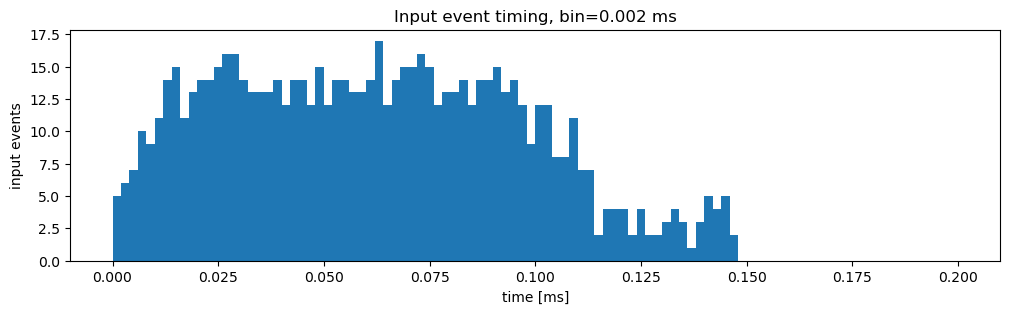

loaded PyNN initial_config from spiking2_calix-native.pkl
pynn.setup kwargs keys: ['initial_config'] enable_neuron_bypass: False
graph built; entering pynn.run
pynn.run finished
single SHD-column hidden V4 spike counts: [50] total: 50
Neo signal containers for single_column_hidden_population_v4: {'analogsignals': 0, 'irregularlysampledsignals': 1, 'spiketrains': 0, 'events': 0}
  candidate irregularlysampledsignals name= v shape= (5883, 1)
Using irregularlysampledsignals from single_column_hidden_population_v4 for variable v
analog variable: v
signal name: v
shape: (5883, 1)
min: 301.0
max: 499.0
mean: 373.6549377441406
  hidden 27 min 301.0 max 499.0 mean 373.6549377441406 argmax_sample 1216


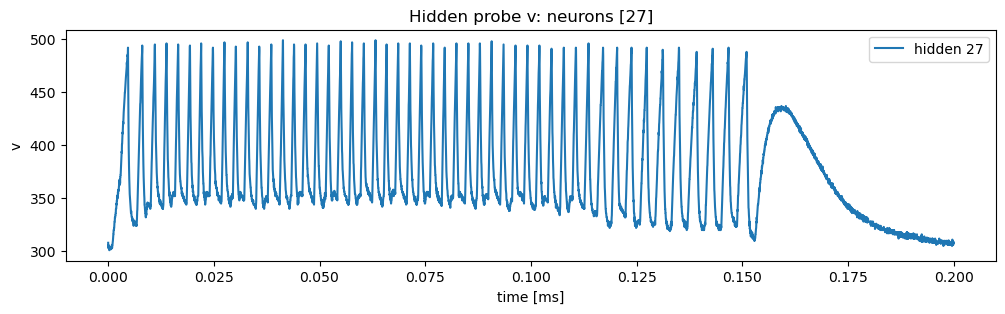

STATIC PYNN READOUT SMOKE
checkpoint: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
sample: 0 label: 10 input spikes: 768.0
runtime_ms: 0.2 timestep_ms: 0.002
static scales: {'w1': 1253.6759031650595, 'v1': 0.0, 'w2': 85.95434363705047}
hardware setup: {'setup_mode': 'calibrated', 'calibration_file': 'spiking2_calix-native.pkl'}
loaded PyNN initial_config from spiking2_calix-native.pkl
pynn.setup kwargs keys: ['initial_config'] enable_neuron_bypass: False
static PyNN pred: 2 label: 10 correct: False decoder: spike_count
hidden spike count: 3001
output spike counts: [36, 38, 50, 32, 25, 43, 20, 36, 46, 33, 26, 50, 35, 39, 26, 12, 8, 32, 22, 27]


In [48]:
# === RUN THIS NOW: calibrated/default SHD smoke sequence ===
# The winning setup from the forced test was:
#   setup_mode="calibrated", hx_preset="default", threshold=150
# Do NOT use hx_preset="active_syn_threshold" for this sequence.

probe_hidden_ids, probe_rows = choose_hidden_probe_neurons(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    k=2,
)

# 1) One-column sanity: should spike (~tens of spikes for hidden 27 on sample 0).
one_col_default = run_pynn_shd_one_hidden_column_probe_v4(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    hidden_id=int(probe_hidden_ids[0]),
    setup_mode="calibrated",
    hx_preset="default",
    threshold=150,
    record_var="v",
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    use_input_inhibition=False,
)

# 2) Full hidden, feedforward only. Target: hidden spike count > 0.
static_ff = run_shd_static_pynn_readout_smoke(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    timestep_ms=0.002,
    spike_offset_ms=0.0005,
    input_gain=8.0,
    recurrent_gain=0.0,
    output_gain=1.0,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    record_analog_output=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
)

# 3) If static_ff has nonzero hidden spikes, try recurrence next.
# static_rec = run_shd_static_pynn_readout_smoke(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     timestep_ms=0.002,
#     spike_offset_ms=0.0005,
#     input_gain=8.0,
#     recurrent_gain=1.0,
#     output_gain=1.0,
#     include_recurrence=True,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=True,
#     use_output_inhibition=False,
#     record_analog_output=False,
#     setup_mode="calibrated",
#     calibration_file="spiking2_calix-native.pkl",
# )

# 4) Only after static runs show nonzero hidden activity, run the PPU version.
#    IMPORTANT: SNN timestep and PPU update period are decoupled here.
#    timestep_ms=0.002 is the inner hardware SNN/input step.
#    ppu_period_ms=3.0 gives the PPU milliseconds, not microseconds, to run ANN + rewrite w2.
# ppu_result = run_shd_onppu_activity_ann_modulated_snn(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     timestep_ms=0.002,
#     ppu_period_ms=3.0,
#     spike_offset_ms=0.0005,
#     input_gain=8.0,
#     recurrent_gain=1.0,
#     output_gain=1.0,
#     include_recurrence=True,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=True,
#     use_output_inhibition=True,
#     input_repetitions=1,
#     input_repeat_dt_ms=0.0002,
#     record_analog_output=False,
#     setup_mode="calibrated",
#     calibration_file="spiking2_calix-native.pkl",
# )


## PPU write-mode diagnostics added

Use these cells now that the calibrated/decoupled PPU path runs. They separate static schedule effects, runtime weight-write effects, ANN-modulated weight effects, and wrong PPU output-counter coordinates.

STATIC DECOUPLED PYNN READOUT SMOKE
checkpoint: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
sample: 0 label: 10 input spikes: 768.0
ppu_period_ms: 3.0 num_periods: 34 runtime_ms: 102.0 snn_timestep_ms: 0.002
static scales: {'w1': 156.70948789563244, 'v1': 0.0, 'w2': 343.8173745482019}
structure: {'include_recurrence': False, 'use_input_inhibition': False, 'use_recurrent_inhibition': False, 'use_output_inhibition': False}
hardware setup: {'setup_mode': 'calibrated', 'calibration_file': 'spiking2_calix-native.pkl'}
loaded PyNN initial_config from spiking2_calix-native.pkl
pynn.setup kwargs keys: ['initial_config'] enable_neuron_bypass: False


/tmp/ipykernel_192649/485145756.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)


graph built; entering pynn.run
pynn.run finished
static decoupled pred: 1 label: 10 correct: False decoder: spike_count
static decoupled top5: [(11, 75.0), (1, 75.0), (8, 74.0), (9, 71.0), (5, 69.0)]
hidden spike count: 875
output spike counts: [41, 75, 55, 67, 53, 69, 7, 48, 74, 71, 46, 75, 42, 48, 45, 17, 14, 42, 17, 64]

PPU WRITE MODE COMPARISON: disabled
REAL ON-PPU ANN MODULATED SHD RUN — FIXED
checkpoint: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
sample: 0 label: 10 input spikes: 768.0
hardware input events after repetitions: 768
ppu_period_ms: 3.0 num_periods: 34 runtime_ms: 102.0 snn_timestep_ms: 0.002 ann_interval: 3
one PPU kernel: reads activity/correlation -> compact ANN -> optional w2 rewrite
PPU write mode: disabled # disabled=no set_weights, noop_getset=get+set unchanged, constant_static_w2=safe alias, ann=in-place modulated
static scales: {'w1': 156.70948789563244, 'v1': 0.0, 'w2': 343.8173745482019}
output counter read coordinate: {'row':

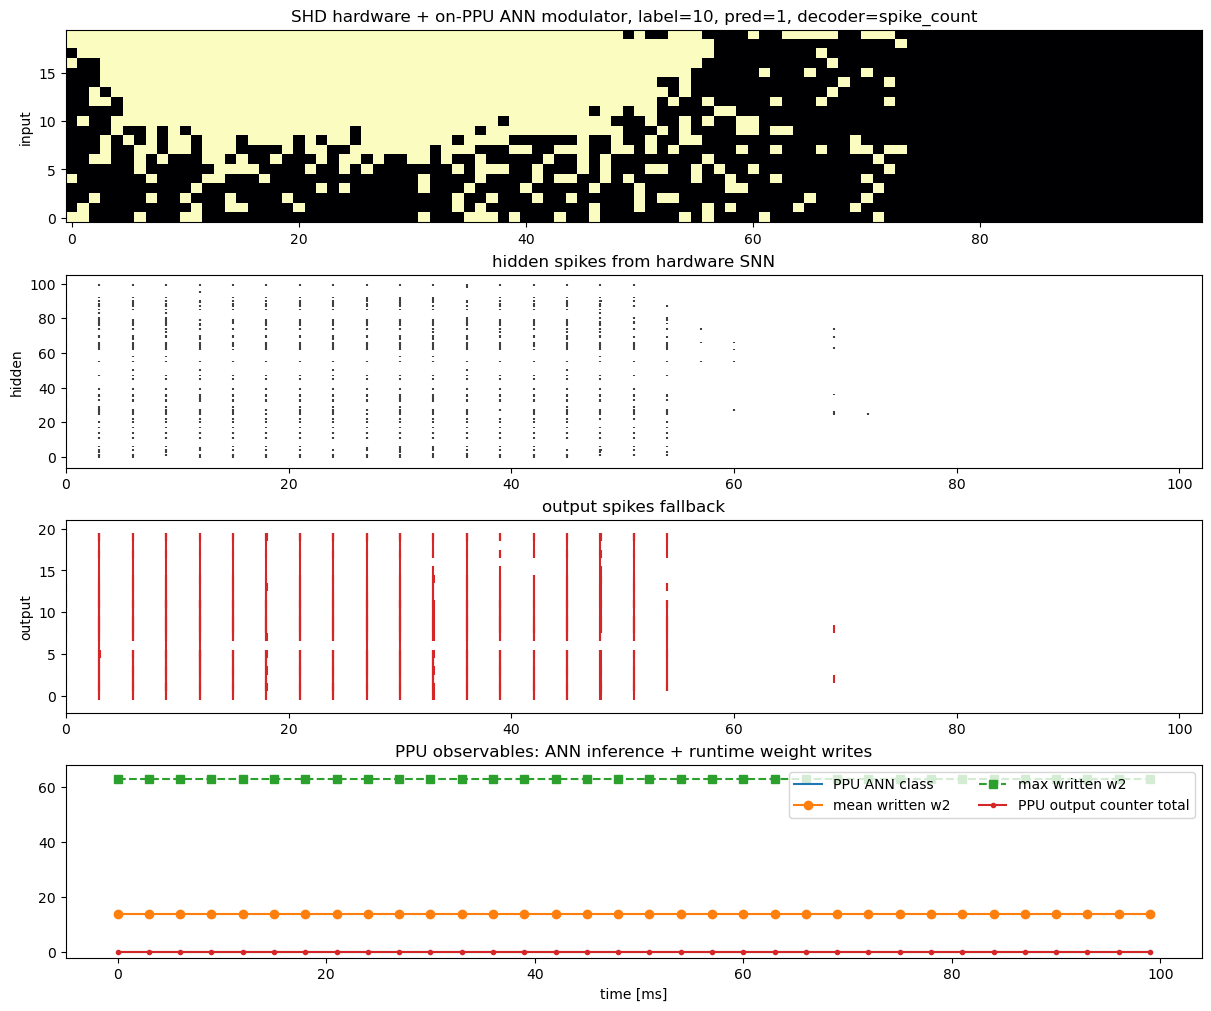

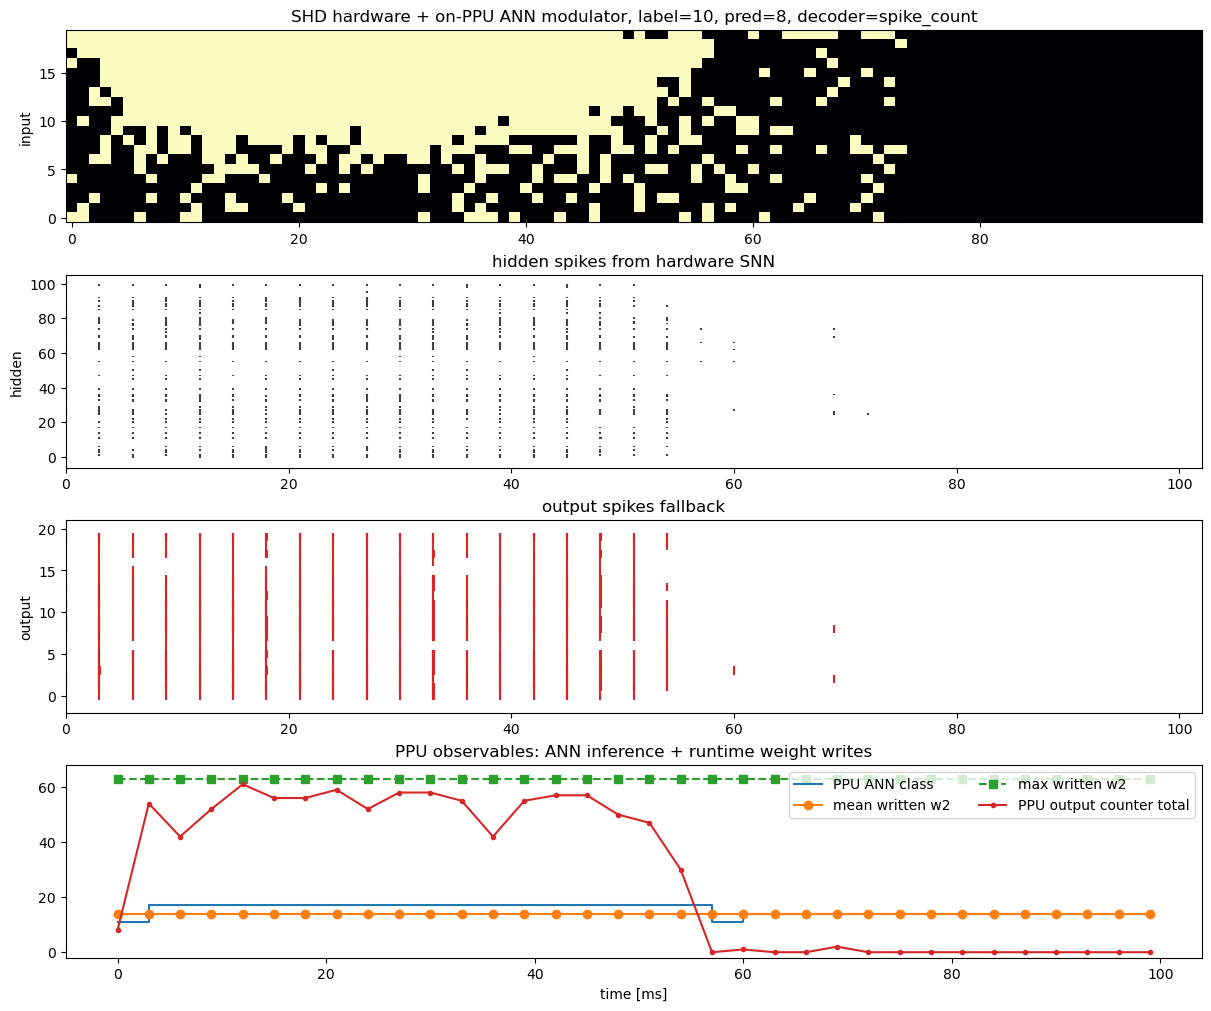

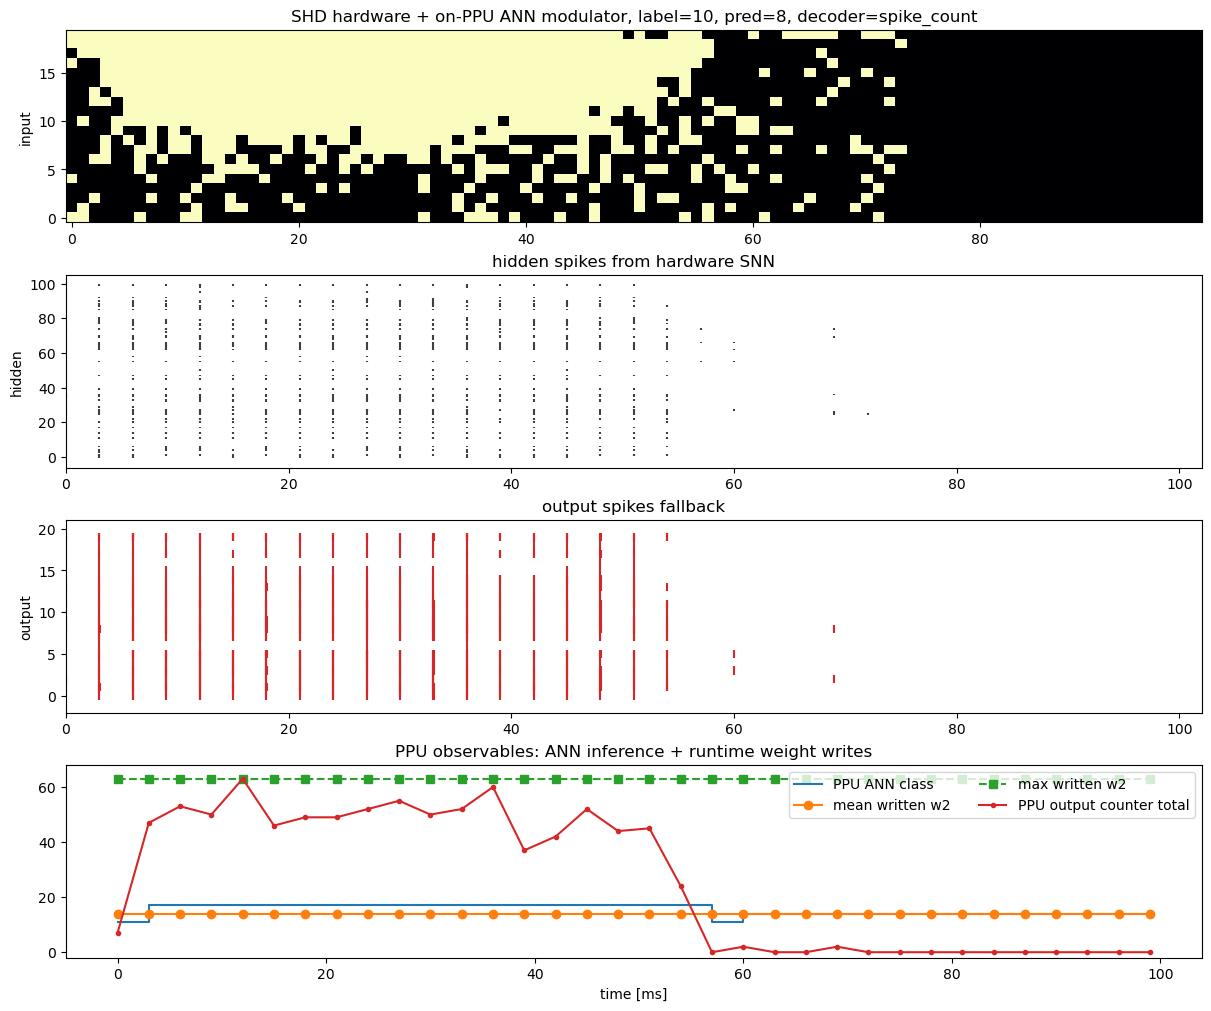

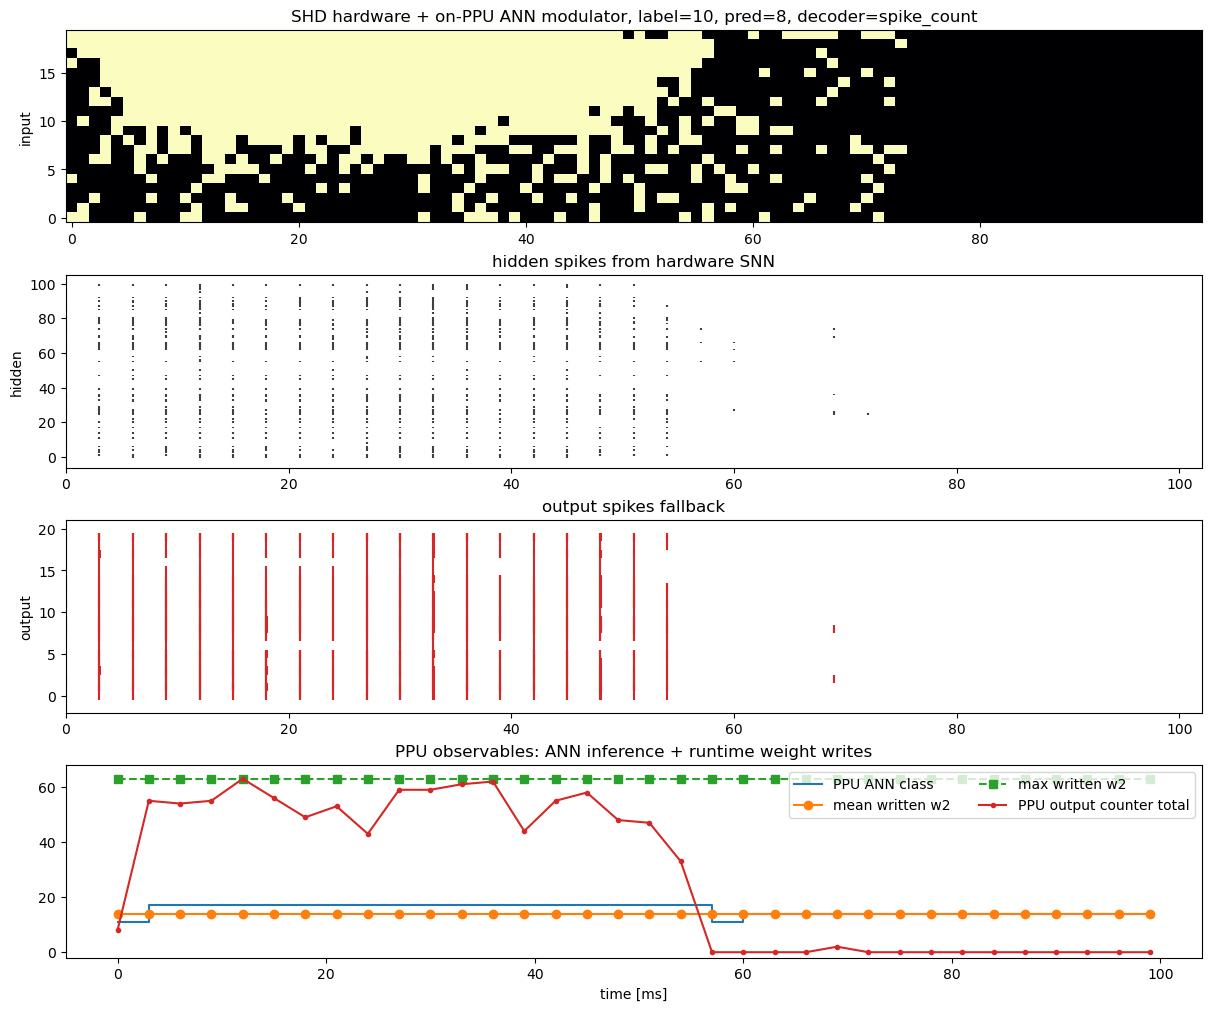

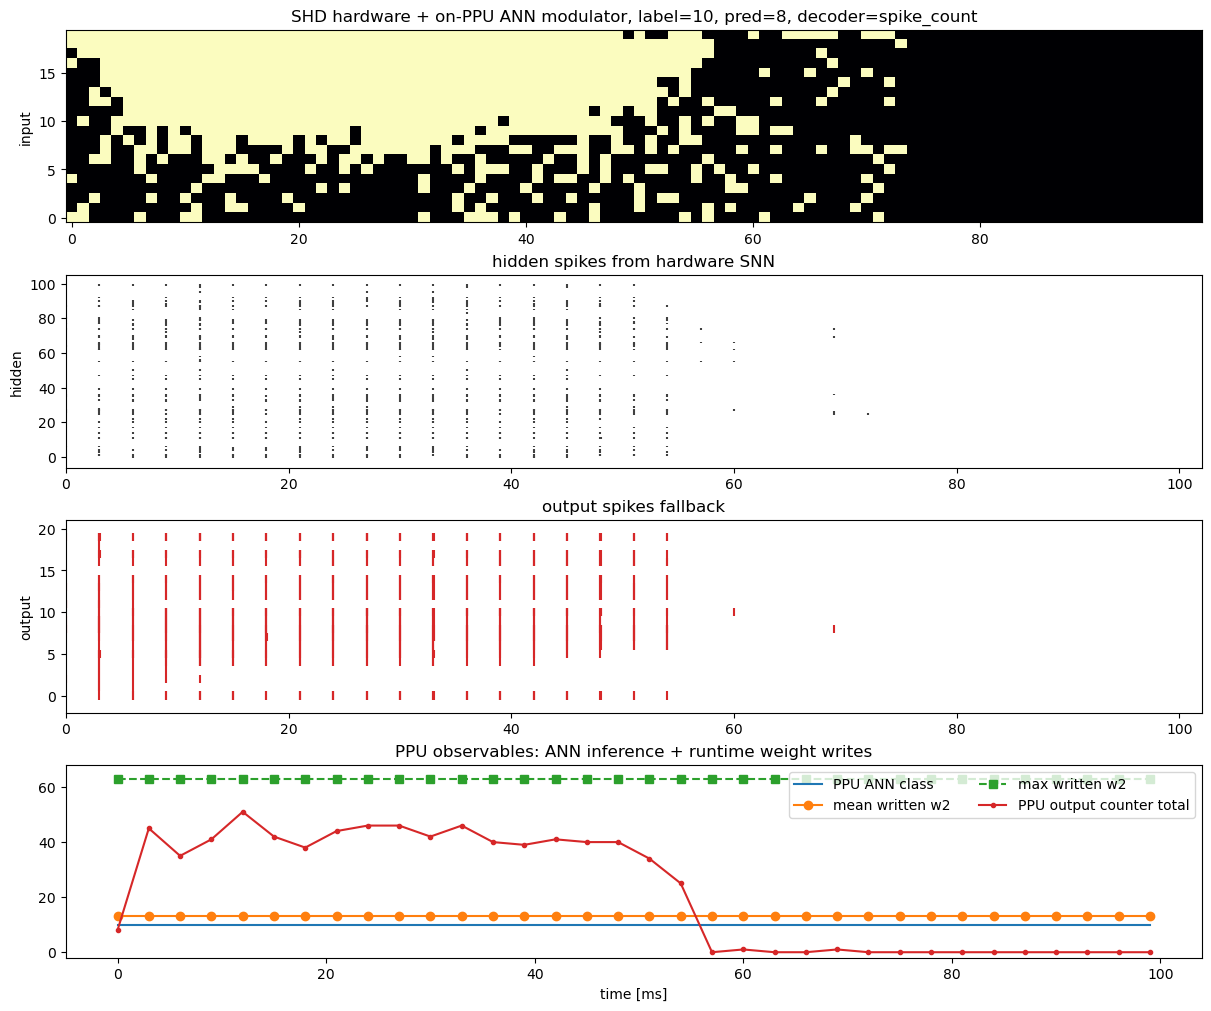

In [49]:
# 1) Static decoupled baseline: same 102 ms / 3 ms window schedule, but no PPU dynamic weights.
static_decoupled = run_shd_static_decoupled_readout_smoke(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    timestep_ms=0.002,
    ppu_period_ms=3.0,
    spike_offset_ms=0.0005,
    input_gain=1.0,
    recurrent_gain=0.0,
    output_gain=4.0,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    input_repetitions=1,
    input_repeat_dt_ms=0.0002,
    record_analog_output=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
)

# 2) Compare dynamic projection modes.
#    disabled: PPU exists but does not rewrite weights.
#    constant_static_w2: PPU writes the original static w2 every period.
#    ann: current ANN-modulated mode.
write_rows, write_artifacts = run_shd_ppu_write_mode_comparison(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    common_kwargs=dict(
        timestep_ms=0.002,
        ppu_period_ms=3.0,
        spike_offset_ms=0.0005,
        input_gain=1.0,
        recurrent_gain=0.0,
        output_gain=4.0,
        include_recurrence=False,
        use_input_inhibition=False,
        use_recurrent_inhibition=False,
        use_output_inhibition=False,
        input_repetitions=1,
        input_repeat_dt_ms=0.0002,
        record_analog_output=False,
        setup_mode="calibrated",
        calibration_file="spiking2_calix-native.pkl",
    ),
)

# 3) Only if PPU output_total remains zero while PyNN output spikes are nonzero:
#    search candidate PPU spike-counter coordinates. Start coarse; narrow around the best.
# counter_scan, counter_artifacts = run_shd_ppu_output_counter_coordinate_sweep(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     rows=(0, 1),
#     column_offsets=tuple(range(0, 241, 20)),
#     common_kwargs=dict(
#         timestep_ms=0.002,
#         ppu_period_ms=3.0,
#         spike_offset_ms=0.0005,
#         input_gain=1.0,
#         recurrent_gain=0.0,
#         output_gain=4.0,
#         include_recurrence=False,
#         use_input_inhibition=False,
#         use_recurrent_inhibition=False,
#         use_output_inhibition=False,
#         input_repetitions=1,
#         input_repeat_dt_ms=0.0002,
#         record_analog_output=False,
#         setup_mode="calibrated",
#         calibration_file="spiking2_calix-native.pkl",
#     ),
# )

In [ ]:
# # === RUN THIS NEXT: verify safe PPU weight-write path ===
# # This cell uses the discovered output counter coordinate:
# #   output_row=0, output_column_offset=100
# # and the safe runtime write modes:
# #   disabled -> noop_getset -> constant_static_w2
# # These three should now match closely. If they do, ANN mode can be tested.

# COMMON_SAFE_PPU_KWARGS = dict(
#     timestep_ms=0.002,
#     ppu_period_ms=3.0,
#     spike_offset_ms=0.0005,
#     input_gain=1.0,
#     recurrent_gain=0.0,
#     output_gain=4.0,
#     include_recurrence=False,
#     use_input_inhibition=False,
#     use_recurrent_inhibition=False,
#     use_output_inhibition=False,
#     input_repetitions=1,
#     input_repeat_dt_ms=0.0002,
#     record_analog_output=False,
#     setup_mode="calibrated",
#     calibration_file="spiking2_calix-native.pkl",
#     output_row=0,
#     output_column_offset=100,
#     plot=True,
# )

# # 1) Static decoupled reference, no PPU write path.
# static_decoupled_safe = run_shd_static_decoupled_readout_smoke(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     **COMMON_SAFE_PPU_KWARGS,
# )

# # 2) PPU present but no set_weights(). Should match static_decoupled reasonably.
# disabled_safe = run_shd_onppu_activity_ann_modulated_snn(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     ppu_write_mode="disabled",
#     distill_ppu_ann=False,
#     **COMMON_SAFE_PPU_KWARGS,
# )

# # 3) PPU get_weights(row); set_weights(row) unchanged. Should match disabled.
# noop_getset_safe = run_shd_onppu_activity_ann_modulated_snn(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     ppu_write_mode="noop_getset",
#     distill_ppu_ann=False,
#     **COMMON_SAFE_PPU_KWARGS,
# )

# # 4) Safe alias for noop_getset. Should also match disabled.
# constant_static_safe = run_shd_onppu_activity_ann_modulated_snn(
#     checkpoint_path=shd_checkpoint_path,
#     root=SHD_SERVER_ROOT,
#     sample_index=0,
#     ppu_write_mode="constant_static_w2",
#     distill_ppu_ann=False,
#     **COMMON_SAFE_PPU_KWARGS,
# )

# # 5) Only after the above three match, test ANN modulation.
# # ann_safe = run_shd_onppu_activity_ann_modulated_snn(
# #     checkpoint_path=shd_checkpoint_path,
# #     root=SHD_SERVER_ROOT,
# #     sample_index=0,
# #     ppu_write_mode="ann",
# #     distill_ppu_ann=True,
# #     **COMMON_SAFE_PPU_KWARGS,
# # )


TypeError: run_shd_static_decoupled_readout_smoke() got an unexpected keyword argument 'output_row'

## Hardware accuracy, PPU weight-change figures, and hardware-in-the-loop training

These cells use the validated safe settings:

- calibrated PyNN setup
- decoupled SNN timing: `timestep_ms=0.002`
- PPU update period: `ppu_period_ms=3.0`
- no recurrence for stability
- safe PPU output counter coordinate: `output_row=0`, `output_column_offset=100`

Run the accuracy subset first. Then run an ANN-mode sample and call the plotting functions. At the end there is a hardware-forward/software-backward training loop you can leave running.

In [51]:

# === Shared stable hardware settings ===

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

COMMON_SAFE_HW_KWARGS = dict(
    timestep_ms=0.002,
    ppu_period_ms=3.0,
    spike_offset_ms=0.0005,
    input_gain=1.0,
    recurrent_gain=0.0,
    output_gain=4.0,
    include_recurrence=False,
    use_input_inhibition=False,
    use_recurrent_inhibition=False,
    use_output_inhibition=False,
    input_repetitions=1,
    input_repeat_dt_ms=0.0002,
    record_analog_output=False,
    setup_mode="calibrated",
    calibration_file="spiking2_calix-native.pkl",
    output_row=0,
    output_column_offset=100,
    plot=False,
)

# run_shd_static_decoupled_readout_smoke does not accept PPU-only arguments.
STATIC_ONLY_DROP = {
    "output_row",
    "output_column_offset",
    "input_repetitions",
    "input_repeat_dt_ms",
}
STATIC_SAFE_HW_KWARGS = {
    k: v for k, v in COMMON_SAFE_HW_KWARGS.items()
    if k not in STATIC_ONLY_DROP
}

def _artifact_parts(artifact):
    if isinstance(artifact, tuple) and len(artifact) >= 6:
        rule, observables, hidden_spikes, output_spikes, projections, result = artifact[:6]
        return rule, observables, hidden_spikes, output_spikes, projections, result
    raise ValueError("Expected artifact tuple: rule, observables, hidden_spikes, output_spikes, projections, result")

def _as_np(x, dtype=float):
    try:
        return np.asarray(x, dtype=dtype)
    except Exception:
        return np.asarray(list(x), dtype=dtype)

def _spiketrain_times(st):
    if hasattr(st, "base"):
        return np.asarray(st.base, dtype=float)
    return np.asarray(st, dtype=float)

def _result_row(mode, sample_index, result, seconds):
    return {
        "mode": str(mode),
        "sample": int(sample_index),
        "label": int(result.get("label", -1)),
        "pred": int(result.get("pred", -1)),
        "correct": bool(result.get("correct", int(result.get("pred", -1)) == int(result.get("label", -2)))),
        "hidden_spikes": int(result.get("hidden_spikes", -1)),
        "output_total": int(np.asarray(result.get("output_counts", []), dtype=float).sum()) if "output_counts" in result else np.nan,
        "ppu_counter_sum": int(result.get("ppu_output_total_sum", -1)) if "ppu_output_total_sum" in result else np.nan,
        "top5": result.get("top5", None),
        "seconds": round(float(seconds), 3),
    }


In [52]:

# === Hardware accuracy over multiple samples ===

def run_hardware_accuracy_subset(
    sample_indices=range(5),
    run_static=True,
    run_disabled=False,
    run_noop=False,
    run_constant=False,
    run_ann=True,
    ppu_params=None,
    distill_if_needed=True,
    distill_sample_indices=range(64),
    distill_epochs=80,
    keep_artifacts=False,
    common_kwargs=None,
):
    """Run a small real-hardware accuracy sweep.

    Start with 5 samples. Increase to 10/20 only after the first run looks stable.
    """
    common_kwargs = dict(COMMON_SAFE_HW_KWARGS if common_kwargs is None else common_kwargs)
    static_kwargs = {k: v for k, v in common_kwargs.items() if k not in STATIC_ONLY_DROP}

    if run_ann and ppu_params is None and distill_if_needed:
        print("Distilling compact PPU ANN once for this sweep...")
        ppu_params = distill_shd_compact_ppu_ann_params_from_checkpoint(
            checkpoint_path=shd_checkpoint_path,
            root=SHD_SERVER_ROOT,
            split="train",
            sample_indices=distill_sample_indices,
            n_hidden_bins=16,
            ann_hidden=16,
            epochs=distill_epochs,
            target_mode="label",
            verbose=True,
        )

    rows = []
    artifacts = {} if keep_artifacts else None

    for sample_index in list(sample_indices):
        print("\n" + "#" * 100)
        print("HARDWARE SAMPLE", int(sample_index))
        print("#" * 100)

        if run_static:
            t0 = time.perf_counter()
            *_, result = run_shd_static_decoupled_readout_smoke(
                checkpoint_path=shd_checkpoint_path,
                root=SHD_SERVER_ROOT,
                sample_index=int(sample_index),
                **static_kwargs,
            )
            rows.append(_result_row("static_decoupled", sample_index, result, time.perf_counter() - t0))

        mode_specs = []
        if run_disabled:
            mode_specs.append(("ppu_disabled", "disabled", False))
        if run_noop:
            mode_specs.append(("ppu_noop_getset", "noop_getset", False))
        if run_constant:
            mode_specs.append(("ppu_constant_static_w2", "constant_static_w2", False))
        if run_ann:
            mode_specs.append(("ppu_ann", "ann", False))

        for mode_name, write_mode, distill_now in mode_specs:
            t0 = time.perf_counter()
            artifact = run_shd_onppu_activity_ann_modulated_snn(
                checkpoint_path=shd_checkpoint_path,
                root=SHD_SERVER_ROOT,
                sample_index=int(sample_index),
                ppu_write_mode=write_mode,
                ppu_params=ppu_params,
                distill_ppu_ann=distill_now,
                **common_kwargs,
            )
            _, _, _, _, _, result = _artifact_parts(artifact)
            rows.append(_result_row(mode_name, sample_index, result, time.perf_counter() - t0))
            if keep_artifacts:
                artifacts[(mode_name, int(sample_index))] = artifact

        df_so_far = pd.DataFrame(rows)
        print("\nCURRENT ACCURACY")
        print(df_so_far.groupby("mode")["correct"].agg(["mean", "sum", "count"]))

    df = pd.DataFrame(rows)
    print("\n" + "=" * 100)
    print("FINAL HARDWARE ACCURACY RESULTS")
    print("=" * 100)
    display_cols = ["mode", "sample", "label", "pred", "correct", "hidden_spikes", "output_total", "ppu_counter_sum", "seconds"]
    print(df[display_cols].to_string(index=False))
    print("\nAccuracy:")
    print(df.groupby("mode")["correct"].agg(["mean", "sum", "count"]))
    return (df, artifacts, ppu_params) if keep_artifacts else (df, ppu_params)

# Start tiny. This is real hardware.
# acc_df_5, ppu_params_eval = run_hardware_accuracy_subset(
#     sample_indices=range(5),
#     run_static=True,
#     run_disabled=False,
#     run_ann=True,
#     keep_artifacts=False,
# )

# Then try 10 or 20.
# acc_df_10, ppu_params_eval = run_hardware_accuracy_subset(
#     sample_indices=range(10),
#     run_static=True,
#     run_disabled=False,
#     run_ann=True,
#     ppu_params=ppu_params_eval,
#     distill_if_needed=False,
#     keep_artifacts=False,
# )


In [53]:

# === Figures: show the PPU changing weights during a hardware run ===

def output_period_count_matrix(output_spikes, period_ms, n_periods=None, n_outputs=20):
    if n_periods is None:
        max_t = 0.0
        for st in output_spikes:
            times = _spiketrain_times(st)
            if len(times):
                max_t = max(max_t, float(times.max()))
        n_periods = int(np.ceil(max_t / float(period_ms))) + 1
    bins = np.arange(n_periods + 1, dtype=float) * float(period_ms)
    counts = np.zeros((n_outputs, n_periods), dtype=float)
    for out_idx in range(min(n_outputs, len(output_spikes))):
        times = _spiketrain_times(output_spikes[out_idx])
        counts[out_idx], _ = np.histogram(times, bins=bins)
    return counts

def plot_ppu_weight_update_figure(
    artifact,
    title="PPU weight updates during one hardware run",
    true_label=None,
    competitor_class=8,
):
    """Plot actual PPU observables from one run.

    If the notebook was run after this update, `probe_weights` shows direct physical W2 weights
    read inside the PPU kernel after the write logic. These are physical columns from one probed
    row, not guaranteed logical class order, but they prove the PPU is changing hardware weights.
    """
    rule, observables, hidden_spikes, output_spikes, projections, result = _artifact_parts(artifact)
    obs = {k: _as_np(v) for k, v in observables.items()}

    update = obs.get("update_count", np.arange(1, len(next(iter(obs.values()))) + 1))
    n_periods = len(update)
    period_ms = float(result.get("ppu_period_ms", result.get("period_ms", 3.0)))
    label = int(result.get("label", true_label if true_label is not None else -1))
    pred = int(result.get("pred", -1))
    t = (update - 1) * period_ms

    output_counts_by_period = output_period_count_matrix(
        output_spikes,
        period_ms=period_ms,
        n_periods=n_periods,
        n_outputs=20,
    )
    final_output_counts = np.asarray(result.get("output_counts", output_counts_by_period.sum(axis=1)), dtype=float)
    if final_output_counts.ndim != 1 or final_output_counts.size != 20:
        final_output_counts = output_counts_by_period.sum(axis=1)

    fig = plt.figure(figsize=(16, 13), constrained_layout=True)
    gs = fig.add_gridspec(4, 2)

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(output_counts_by_period, aspect="auto", origin="lower")
    ax0.set_title("Output spikes per PPU period")
    ax0.set_xlabel("PPU period")
    ax0.set_ylabel("output class")
    ax0.set_yticks(range(20))
    if label >= 0:
        ax0.axhline(label, linestyle="--", linewidth=1.5, label=f"label {label}")
    if competitor_class is not None:
        ax0.axhline(competitor_class, linestyle=":", linewidth=1.5, label=f"class {competitor_class}")
    ax0.legend(loc="upper right")
    fig.colorbar(im0, ax=ax0, label="spikes / period")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.bar(np.arange(20), final_output_counts)
    ax1.set_title(f"Final output spike-count readout: pred={pred}, label={label}")
    ax1.set_xlabel("output class")
    ax1.set_ylabel("total spikes")
    ax1.set_xticks(range(20))
    if label >= 0:
        ax1.axvline(label, linestyle="--", linewidth=1.5, label=f"label {label}")
    if competitor_class is not None:
        ax1.axvline(competitor_class, linestyle=":", linewidth=1.5, label=f"class {competitor_class}")
    ax1.legend(loc="upper right")

    ax2 = fig.add_subplot(gs[1, 0])
    for key, marker in [("mean_weight", "o"), ("max_weight", "s"), ("first_weight", "^")]:
        if key in obs:
            ax2.plot(t, obs[key].reshape(-1), marker=marker, label=key)
    ax2.set_title("PPU-recorded W2 summary each update")
    ax2.set_xlabel("time [ms]")
    ax2.set_ylabel("weight value")
    ax2.set_ylim(-2, 66)
    ax2.legend()

    ax3 = fig.add_subplot(gs[1, 1])
    if "probe_weights" in obs and obs["probe_weights"].ndim == 2:
        probe = obs["probe_weights"].T
        im3 = ax3.imshow(probe, aspect="auto", origin="lower", vmin=0, vmax=63)
        ax3.set_title("Actual probed physical W2 weights after each PPU update")
        ax3.set_xlabel("PPU period")
        ax3.set_ylabel("probed physical column")
        fig.colorbar(im3, ax=ax3, label="weight [0..63]")
    else:
        ax3.text(0.5, 0.5, "No probe_weights observable found.\nRe-run with this updated notebook.", ha="center", va="center")
        ax3.set_axis_off()

    ax4 = fig.add_subplot(gs[2, 0])
    if "predicted_class" in obs:
        ax4.step(t, obs["predicted_class"].reshape(-1), where="post", label="PPU ANN predicted class")
    if label >= 0:
        ax4.axhline(label, linestyle="--", linewidth=1.5, label=f"label {label}")
    if competitor_class is not None:
        ax4.axhline(competitor_class, linestyle=":", linewidth=1.5, label=f"class {competitor_class}")
    ax4.set_title("PPU ANN decision over time")
    ax4.set_xlabel("time [ms]")
    ax4.set_ylabel("class")
    ax4.set_yticks(range(20))
    ax4.legend(loc="upper right")

    ax5 = fig.add_subplot(gs[2, 1])
    if "output_total" in obs:
        ax5.plot(t, obs["output_total"].reshape(-1), "o-", label="PPU output counter total")
    if "hidden_proxy" in obs:
        ax5.plot(t, obs["hidden_proxy"].reshape(-1), "s--", label="PPU hidden/correlation proxy")
    ax5.set_title("PPU activity observables")
    ax5.set_xlabel("time [ms]")
    ax5.set_ylabel("counter / proxy")
    ax5.set_ylim(-2, 66)
    ax5.legend()

    ax6 = fig.add_subplot(gs[3, 0])
    bins = np.arange(n_periods + 1, dtype=float) * period_ms
    hidden_total_by_period = np.zeros(n_periods)
    for st in hidden_spikes:
        hist, _ = np.histogram(_spiketrain_times(st), bins=bins)
        hidden_total_by_period += hist
    ax6.plot(t, hidden_total_by_period, "o-")
    ax6.set_title("Hidden spikes from hardware SNN per PPU period")
    ax6.set_xlabel("time [ms]")
    ax6.set_ylabel("hidden spikes / period")

    ax7 = fig.add_subplot(gs[3, 1])
    if "feature_snapshot" in obs and obs["feature_snapshot"].ndim == 2:
        im7 = ax7.imshow(obs["feature_snapshot"].T, aspect="auto", origin="lower", vmin=0, vmax=63)
        ax7.set_title("Exact compact PPU ANN feature vector over time")
        ax7.set_xlabel("PPU period")
        ax7.set_ylabel("feature index")
        fig.colorbar(im7, ax=ax7, label="feature value [0..63]")
    else:
        ax7.text(0.5, 0.5, "No feature_snapshot observable found.\nRe-run with this updated notebook.", ha="center", va="center")
        ax7.set_axis_off()

    fig.suptitle(title, fontsize=16)
    return fig

def plot_ppu_write_mode_weight_comparison(write_artifacts):
    fig, axes = plt.subplots(4, 1, figsize=(13, 11), constrained_layout=True)
    for mode, artifact in write_artifacts.items():
        _, observables, _, _, _, result = _artifact_parts(artifact)
        obs = {k: _as_np(v) for k, v in observables.items()}
        update = obs.get("update_count", np.arange(1, len(next(iter(obs.values()))) + 1))
        period_ms = float(result.get("ppu_period_ms", 3.0))
        t = (update - 1) * period_ms
        if "mean_weight" in obs:
            axes[0].plot(t, obs["mean_weight"].reshape(-1), "o-", label=mode)
        if "max_weight" in obs:
            axes[1].plot(t, obs["max_weight"].reshape(-1), "s-", label=mode)
        if "predicted_class" in obs:
            axes[2].step(t, obs["predicted_class"].reshape(-1), where="post", label=mode)
        if "probe_weights" in obs and obs["probe_weights"].ndim == 2:
            axes[3].plot(t, obs["probe_weights"][:, 0], "o-", label=f"{mode}: probe 0")
            axes[3].plot(t, obs["probe_weights"][:, min(10, obs["probe_weights"].shape[1]-1)], "s--", label=f"{mode}: probe 10")

    axes[0].set_title("PPU mean W2 weight over time")
    axes[0].set_ylabel("mean weight")
    axes[0].set_ylim(-2, 66)
    axes[0].legend()
    axes[1].set_title("PPU max W2 weight over time")
    axes[1].set_ylabel("max weight")
    axes[1].set_ylim(-2, 66)
    axes[1].legend()
    axes[2].set_title("PPU predicted class over time")
    axes[2].set_ylabel("class")
    axes[2].set_yticks(range(20))
    axes[2].legend()
    axes[3].set_title("Example probed physical weights over time")
    axes[3].set_xlabel("time [ms]")
    axes[3].set_ylabel("weight")
    axes[3].set_ylim(-2, 66)
    axes[3].legend()
    return fig

# Example usage after an ANN run:
# fig = plot_ppu_weight_update_figure(ann_safe, true_label=10, competitor_class=8)
# fig = plot_ppu_write_mode_weight_comparison(write_artifacts)


/tmp/ipykernel_192649/485145756.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)


distilled compact PPU ANN: {'samples': 64, 'windows': 2176, 'loss': 2.7416, 'train_acc': 0.125}
REAL ON-PPU ANN MODULATED SHD RUN — FIXED
checkpoint: NM_BSS2/new_checkpoints/shd_release_snn_modulator_with_sample_events.pt
sample: 0 label: 10 input spikes: 768.0
hardware input events after repetitions: 768
ppu_period_ms: 3.0 num_periods: 34 runtime_ms: 102.0 snn_timestep_ms: 0.002 ann_interval: 3
one PPU kernel: reads activity/correlation -> compact ANN -> optional w2 rewrite
PPU write mode: ann # disabled=no set_weights, noop_getset=get+set unchanged, constant_static_w2=safe alias, ann=in-place modulated
static scales: {'w1': 156.70948789563244, 'v1': 0.0, 'w2': 343.8173745482019}
output counter read coordinate: {'row': 0, 'column_offset': 100}
include_recurrence: False
drive knobs: {'input_gain': 1.0, 'input_repetitions': 1, 'input_repeat_dt_ms': 0.0002, 'ppu_period_ms': 3.0, 'snn_timestep_ms': 0.002, 'use_input_inhibition': False, 'use_recurrent_inhibition': False, 'use_output_inhibi

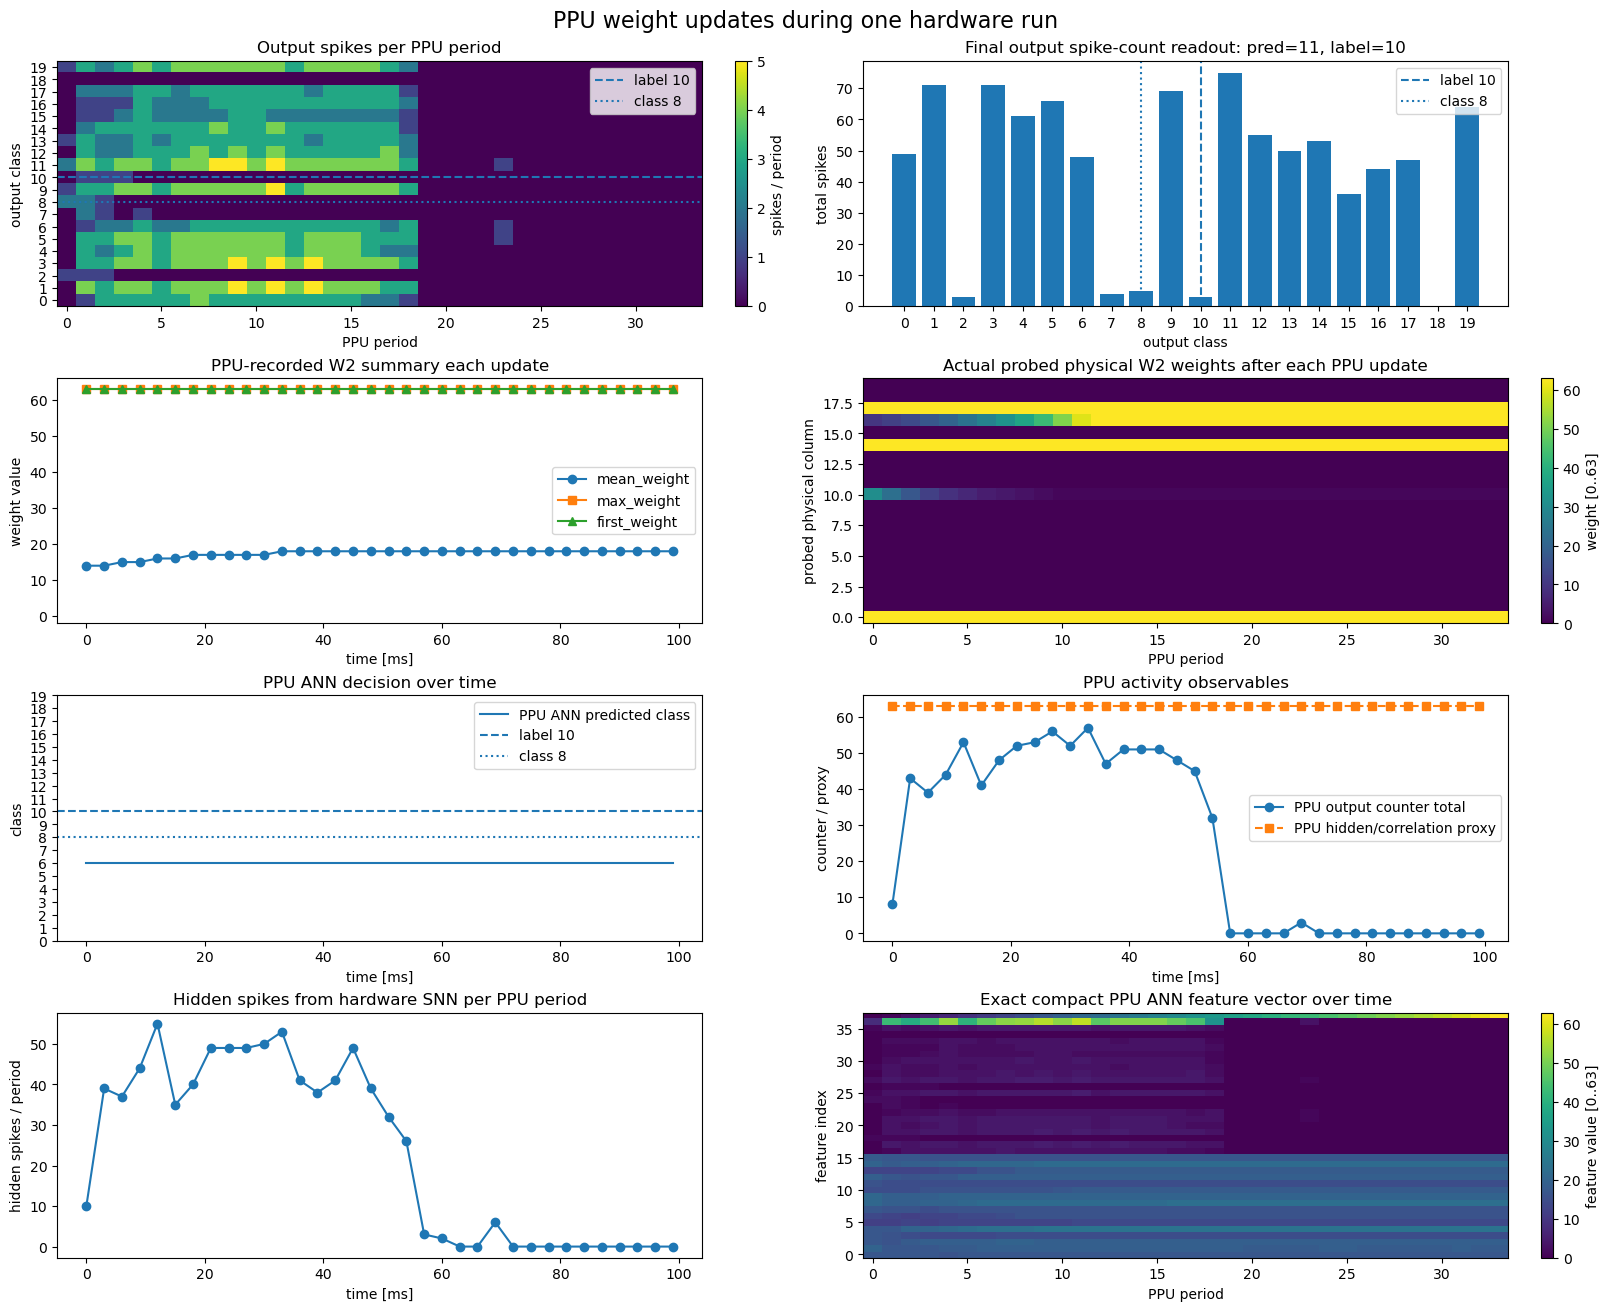

In [61]:

# === Run one ANN sample and immediately plot the PPU weight-change figure ===
# This uses the new probe_weights and feature_snapshot observables, so re-run this cell
# after loading this updated notebook.

ppu_params_eval = distill_shd_compact_ppu_ann_params_from_checkpoint(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    split="train",
    sample_indices=range(64),
    n_hidden_bins=16,
    ann_hidden=16,
    epochs=80,
    target_mode="label",
    verbose=True,
)

ann_demo = run_shd_onppu_activity_ann_modulated_snn(
    checkpoint_path=shd_checkpoint_path,
    root=SHD_SERVER_ROOT,
    sample_index=0,
    ppu_write_mode="ann",
    distill_ppu_ann=False,
    ppu_params=ppu_params_eval,
    **COMMON_SAFE_HW_KWARGS,
)

fig = plot_ppu_weight_update_figure(ann_demo, true_label=10, competitor_class=8)


### Hardware-forward / software-backward training

This collects the exact PPU feature vectors from real hardware runs (`feature_snapshot`) and trains the compact PPU ANN in software. It is not full backpropagation through the chip. It is the practical first hardware-in-the-loop training step:

1. run hardware forward with safe `ppu_write_mode="disabled"`,
2. read the exact PPU features for each update window,
3. train the compact ANN in PyTorch using labels,
4. quantize the trained ANN back to PPU integer parameters,
5. re-run hardware in `ppu_write_mode="ann"`.

The final cell is designed to be left running.

In [55]:

# === Hardware-forward / software-backward compact PPU ANN training helpers ===

def _quantize_compact_ppu_torch_model(model, n_features, n_hidden_bins=16, ann_hidden=16, n_outputs=20):
    l1 = model[0]
    l2 = model[2]
    feature_scale = 64
    weight_scale = 64
    hidden_scale = 32.0
    score_scale = 32.0
    with torch.no_grad():
        w1 = torch.round(l1.weight.T * (hidden_scale * feature_scale / 63.0)).clamp(-32768, 32767).short().cpu().numpy()
        b1 = torch.round(l1.bias * hidden_scale).clamp(-32768, 32767).short().cpu().numpy()
        w2 = torch.round(l2.weight.T * (score_scale * weight_scale / hidden_scale)).clamp(-32768, 32767).short().cpu().numpy()
        b2 = torch.round(l2.bias * score_scale).clamp(-32768, 32767).short().cpu().numpy()
    return {
        "n_features": int(n_features),
        "n_hidden_bins": int(n_hidden_bins),
        "ann_hidden": int(ann_hidden),
        "n_outputs": int(n_outputs),
        "feature_scale": int(feature_scale),
        "weight_scale": int(weight_scale),
        "w1": w1.astype(np.int16),
        "b1": b1.astype(np.int16),
        "w2": w2.astype(np.int16),
        "b2": b2.astype(np.int16),
        "distilled": False,
        "hardware_trained": True,
    }

def collect_hardware_ppu_feature_dataset(
    sample_indices=range(20),
    common_kwargs=None,
    keep_artifacts=False,
):
    """Collect exact PPU feature snapshots from real hardware.

    Each SHD sample gives one row per PPU update period, all with the same sample label.
    """
    common_kwargs = dict(COMMON_SAFE_HW_KWARGS if common_kwargs is None else common_kwargs)
    common_kwargs["plot"] = False
    X_rows = []
    y_rows = []
    meta_rows = []
    artifacts = {} if keep_artifacts else None

    for sample_index in list(sample_indices):
        print("\n" + "#" * 100)
        print("COLLECT HARDWARE FEATURES SAMPLE", int(sample_index))
        print("#" * 100)
        t0 = time.perf_counter()
        artifact = run_shd_onppu_activity_ann_modulated_snn(
            checkpoint_path=shd_checkpoint_path,
            root=SHD_SERVER_ROOT,
            sample_index=int(sample_index),
            ppu_write_mode="disabled",
            distill_ppu_ann=False,
            ppu_params=None,
            **common_kwargs,
        )
        _, observables, _, _, _, result = _artifact_parts(artifact)
        if "feature_snapshot" not in observables:
            raise RuntimeError("feature_snapshot observable missing. Re-run with the updated notebook definitions.")
        feats = np.asarray(observables["feature_snapshot"], dtype=np.float32)
        label = int(result["label"])
        X_rows.append(feats)
        y_rows.append(np.full((feats.shape[0],), label, dtype=np.int64))
        for period in range(feats.shape[0]):
            meta_rows.append({
                "sample": int(sample_index),
                "period": int(period),
                "label": label,
                "static_pred": int(result.get("pred", -1)),
                "collect_seconds": round(time.perf_counter() - t0, 3),
            })
        if keep_artifacts:
            artifacts[int(sample_index)] = artifact
        print("collected", feats.shape, "label", label, "static_pred", result.get("pred"))

    X = np.concatenate(X_rows, axis=0).astype(np.float32)
    y = np.concatenate(y_rows, axis=0).astype(np.int64)
    meta = pd.DataFrame(meta_rows)
    return (X, y, meta, artifacts) if keep_artifacts else (X, y, meta)

def train_compact_ppu_ann_from_hardware_features(
    X,
    y,
    n_hidden_bins=16,
    ann_hidden=16,
    n_outputs=20,
    epochs=400,
    lr=1e-3,
    seed=11,
    verbose_every=50,
):
    """Software backward pass on hardware-collected PPU features."""
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    n_features = int(X.shape[1])
    X_t = torch.tensor(X / 63.0, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    model = nn.Sequential(
        nn.Linear(n_features, ann_hidden),
        nn.ReLU(),
        nn.Linear(ann_hidden, n_outputs),
    )
    opt = torch.optim.Adam(model.parameters(), lr=float(lr), weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for epoch in range(int(epochs)):
        opt.zero_grad(set_to_none=True)
        logits = model(X_t)
        loss = loss_fn(logits, y_t)
        loss.backward()
        opt.step()
        if epoch == 0 or (epoch + 1) % int(verbose_every) == 0 or epoch == int(epochs) - 1:
            with torch.no_grad():
                pred = logits.argmax(dim=1)
                acc = float((pred == y_t).float().mean().item())
                loss_val = float(loss.item())
            history.append({"epoch": epoch + 1, "loss": loss_val, "train_acc": acc})
            print(f"epoch {epoch+1:04d} loss={loss_val:.4f} train_acc={acc:.4f}")

    ppu_params = _quantize_compact_ppu_torch_model(
        model,
        n_features=n_features,
        n_hidden_bins=n_hidden_bins,
        ann_hidden=ann_hidden,
        n_outputs=n_outputs,
    )
    ppu_params["hardware_train_history"] = history
    with torch.no_grad():
        logits = model(X_t)
        ppu_params["hardware_train_acc_float"] = float((logits.argmax(dim=1) == y_t).float().mean().item())
        ppu_params["hardware_train_loss_float"] = float(loss_fn(logits, y_t).item())
    return ppu_params, model, pd.DataFrame(history)

def hardware_train_then_evaluate(
    train_sample_indices=range(20),
    eval_sample_indices=range(10),
    collect_kwargs=None,
    train_epochs=400,
    ann_hidden=16,
):
    """Complete hardware-forward/software-backward run.

    This is the cell to leave running after the small tests pass.
    """
    collect_kwargs = dict(COMMON_SAFE_HW_KWARGS if collect_kwargs is None else collect_kwargs)
    collect_kwargs["plot"] = False

    print("Collecting hardware feature dataset...")
    X_hw, y_hw, meta_hw = collect_hardware_ppu_feature_dataset(
        sample_indices=train_sample_indices,
        common_kwargs=collect_kwargs,
        keep_artifacts=False,
    )
    print("Hardware feature matrix:", X_hw.shape, "labels:", y_hw.shape)
    print("Unique labels:", sorted(set(map(int, y_hw))))

    print("\nTraining compact PPU ANN in software from hardware-collected features...")
    hw_ppu_params, hw_model, hw_history = train_compact_ppu_ann_from_hardware_features(
        X_hw,
        y_hw,
        n_hidden_bins=16,
        ann_hidden=ann_hidden,
        n_outputs=20,
        epochs=train_epochs,
        lr=1e-3,
        verbose_every=max(10, train_epochs // 10),
    )

    print("\nEvaluating trained hardware-feature PPU ANN on hardware...")
    eval_df, _ = run_hardware_accuracy_subset(
        sample_indices=eval_sample_indices,
        run_static=True,
        run_disabled=False,
        run_ann=True,
        ppu_params=hw_ppu_params,
        distill_if_needed=False,
        keep_artifacts=False,
        common_kwargs=collect_kwargs,
    )
    return hw_ppu_params, hw_model, hw_history, meta_hw, eval_df


In [56]:

# === LEAVE-RUNNING HARDWARE TRAINING CELL ===
# Start with 10-20 train samples and 5-10 eval samples. Increase only after it behaves.

# hw_ppu_params, hw_model, hw_history, hw_meta, hw_eval_df = hardware_train_then_evaluate(
#     train_sample_indices=range(20),
#     eval_sample_indices=range(10),
#     train_epochs=400,
#     ann_hidden=16,
# )
#
# # Save the trained PPU params so you can reuse them without recollecting hardware features.
# import pickle
# with open("hw_trained_ppu_params.pkl", "wb") as f:
#     pickle.dump(hw_ppu_params, f)
# hw_history.to_csv("hw_training_history.csv", index=False)
# hw_eval_df.to_csv("hw_eval_results.csv", index=False)
# print("Saved hw_trained_ppu_params.pkl, hw_training_history.csv, hw_eval_results.csv")



### Robust / resumable hardware training after timeouts

If the hardware throws a playback timeout or `ContainerTicket` error, the PyNN hardware connection is often not recoverable in the same kernel. These cells save after every hardware sample so you can restart the kernel, rerun definitions, and continue from the saved `.npz` / `.csv` files instead of losing a long run.


In [58]:

# === Robust / resumable hardware-forward software-backward training ===

from pathlib import Path
import traceback
import pickle

HW_RUN_DIR = Path("hw_ppu_training_runs")
HW_RUN_DIR.mkdir(exist_ok=True)

DEFAULT_FEATURE_NPZ = HW_RUN_DIR / "hw_feature_dataset_resumable.npz"
DEFAULT_FEATURE_META = HW_RUN_DIR / "hw_feature_meta_resumable.csv"
DEFAULT_EVAL_CSV = HW_RUN_DIR / "hw_eval_resumable.csv"
DEFAULT_PARAMS_PKL = HW_RUN_DIR / "hw_trained_ppu_params_resumable.pkl"
DEFAULT_HISTORY_CSV = HW_RUN_DIR / "hw_training_history_resumable.csv"
DEFAULT_ERROR_LOG = HW_RUN_DIR / "hw_errors.log"

FATAL_HW_ERROR_PATTERNS = (
    "ContainerTicket",
    "Playback instruction timeout",
    "Access is not possible until ContainerTicket is valid",
)

def _append_hw_error_log(message, path=DEFAULT_ERROR_LOG):
    path = Path(path)
    path.parent.mkdir(exist_ok=True, parents=True)
    with path.open("a") as f:
        f.write("\n" + "=" * 100 + "\n")
        f.write(time.strftime("%Y-%m-%d %H:%M:%S") + "\n")
        f.write(str(message) + "\n")
        f.write(traceback.format_exc() + "\n")


def _is_fatal_hw_error(exc):
    text = str(exc)
    return any(pattern in text for pattern in FATAL_HW_ERROR_PATTERNS)


def _save_feature_dataset_npz(X, y, meta, npz_path=DEFAULT_FEATURE_NPZ, meta_path=DEFAULT_FEATURE_META):
    npz_path = Path(npz_path)
    meta_path = Path(meta_path)
    npz_path.parent.mkdir(exist_ok=True, parents=True)
    np.savez_compressed(npz_path, X=np.asarray(X, dtype=np.float32), y=np.asarray(y, dtype=np.int64))
    pd.DataFrame(meta).to_csv(meta_path, index=False)
    print("saved feature dataset:", npz_path, meta_path)


def _load_feature_dataset_npz(npz_path=DEFAULT_FEATURE_NPZ, meta_path=DEFAULT_FEATURE_META):
    npz_path = Path(npz_path)
    meta_path = Path(meta_path)
    if not npz_path.exists() or not meta_path.exists():
        return None, None, pd.DataFrame()
    data = np.load(npz_path)
    meta = pd.read_csv(meta_path)
    return data["X"].astype(np.float32), data["y"].astype(np.int64), meta


def collected_samples_from_meta(meta):
    if meta is None or len(meta) == 0 or "sample" not in meta:
        return set()
    return set(int(x) for x in sorted(pd.unique(meta["sample"])))


def collect_hardware_ppu_feature_dataset_resumable(
    sample_indices=range(20),
    common_kwargs=None,
    npz_path=DEFAULT_FEATURE_NPZ,
    meta_path=DEFAULT_FEATURE_META,
    stop_on_hardware_failure=True,
):
    """Collect exact PPU feature snapshots from hardware, saving after every sample.

    If a playback timeout / ContainerTicket failure occurs, this saves everything collected
    so far, then raises. Restart the kernel and call this again with the same paths to resume.
    """
    common_kwargs = dict(COMMON_SAFE_HW_KWARGS if common_kwargs is None else common_kwargs)
    common_kwargs["plot"] = False

    X_existing, y_existing, meta_existing = _load_feature_dataset_npz(npz_path, meta_path)
    X_chunks = [] if X_existing is None else [X_existing]
    y_chunks = [] if y_existing is None else [y_existing]
    meta_rows = [] if meta_existing is None or len(meta_existing) == 0 else meta_existing.to_dict("records")
    done_samples = collected_samples_from_meta(meta_existing)

    print("already collected samples:", sorted(done_samples))

    for sample_index in list(sample_indices):
        sample_index = int(sample_index)
        if sample_index in done_samples:
            print("skipping already collected sample", sample_index)
            continue

        print("\n" + "#" * 100)
        print("RESUMABLE COLLECT HARDWARE FEATURES SAMPLE", sample_index)
        print("#" * 100)
        t0 = time.perf_counter()

        try:
            artifact = run_shd_onppu_activity_ann_modulated_snn(
                checkpoint_path=shd_checkpoint_path,
                root=SHD_SERVER_ROOT,
                sample_index=sample_index,
                ppu_write_mode="disabled",       # clean hardware features, no dynamic W2 perturbation
                distill_ppu_ann=False,
                ppu_params=None,
                **common_kwargs,
            )
            _, observables, _, _, _, result = _artifact_parts(artifact)
            if "feature_snapshot" not in observables:
                raise RuntimeError("feature_snapshot observable missing. Re-run definition cells from updated notebook.")

            feats = np.asarray(observables["feature_snapshot"], dtype=np.float32)
            label = int(result["label"])
            X_chunks.append(feats)
            y_chunks.append(np.full((feats.shape[0],), label, dtype=np.int64))
            for period in range(feats.shape[0]):
                meta_rows.append({
                    "sample": sample_index,
                    "period": int(period),
                    "label": label,
                    "static_pred": int(result.get("pred", -1)),
                    "hidden_spikes": int(result.get("hidden_spikes", -1)),
                    "collect_seconds": round(time.perf_counter() - t0, 3),
                })
            done_samples.add(sample_index)

            X_now = np.concatenate(X_chunks, axis=0).astype(np.float32)
            y_now = np.concatenate(y_chunks, axis=0).astype(np.int64)
            _save_feature_dataset_npz(X_now, y_now, pd.DataFrame(meta_rows), npz_path, meta_path)
            print("collected", feats.shape, "label", label, "static_pred", result.get("pred"))

        except Exception as exc:
            _append_hw_error_log(f"collect sample={sample_index} failed: {exc}")
            print("HARDWARE COLLECTION FAILED on sample", sample_index)
            print(type(exc).__name__ + ":", exc)
            if len(X_chunks):
                X_now = np.concatenate(X_chunks, axis=0).astype(np.float32)
                y_now = np.concatenate(y_chunks, axis=0).astype(np.int64)
                _save_feature_dataset_npz(X_now, y_now, pd.DataFrame(meta_rows), npz_path, meta_path)
            if stop_on_hardware_failure or _is_fatal_hw_error(exc):
                raise RuntimeError(
                    "Hardware run failed and progress was saved. If this was a ContainerTicket/playback timeout, "
                    "restart the kernel/session, rerun definitions, and call this function again to resume."
                ) from exc

    X = np.concatenate(X_chunks, axis=0).astype(np.float32) if X_chunks else np.empty((0, 0), dtype=np.float32)
    y = np.concatenate(y_chunks, axis=0).astype(np.int64) if y_chunks else np.empty((0,), dtype=np.int64)
    meta = pd.DataFrame(meta_rows)
    return X, y, meta


def train_from_saved_hardware_features(
    npz_path=DEFAULT_FEATURE_NPZ,
    meta_path=DEFAULT_FEATURE_META,
    train_epochs=400,
    ann_hidden=16,
    params_path=DEFAULT_PARAMS_PKL,
    history_path=DEFAULT_HISTORY_CSV,
):
    X_hw, y_hw, meta_hw = _load_feature_dataset_npz(npz_path, meta_path)
    if X_hw is None or len(y_hw) == 0:
        raise RuntimeError("No saved hardware feature dataset found. Run collect_hardware_ppu_feature_dataset_resumable first.")
    print("loaded hardware feature matrix:", X_hw.shape, "labels:", y_hw.shape)
    print("samples:", sorted(collected_samples_from_meta(meta_hw)))
    print("unique labels:", sorted(set(map(int, y_hw))))

    hw_ppu_params, hw_model, hw_history = train_compact_ppu_ann_from_hardware_features(
        X_hw,
        y_hw,
        n_hidden_bins=16,
        ann_hidden=ann_hidden,
        n_outputs=20,
        epochs=train_epochs,
        lr=1e-3,
        verbose_every=max(10, train_epochs // 10),
    )
    with open(params_path, "wb") as f:
        pickle.dump(hw_ppu_params, f)
    hw_history.to_csv(history_path, index=False)
    print("saved trained params:", params_path)
    print("saved history:", history_path)
    return hw_ppu_params, hw_model, hw_history, meta_hw


def _append_eval_row(row, eval_csv=DEFAULT_EVAL_CSV):
    eval_csv = Path(eval_csv)
    eval_csv.parent.mkdir(exist_ok=True, parents=True)
    df = pd.DataFrame([row])
    header = not eval_csv.exists()
    df.to_csv(eval_csv, mode="a", index=False, header=header)


def evaluated_samples_from_csv(eval_csv=DEFAULT_EVAL_CSV, mode="ppu_ann_hw_trained"):
    eval_csv = Path(eval_csv)
    if not eval_csv.exists():
        return set()
    df = pd.read_csv(eval_csv)
    if "sample" not in df:
        return set()
    if "mode" in df:
        df = df[df["mode"] == mode]
    return set(int(x) for x in pd.unique(df["sample"]))


def evaluate_hw_trained_ppu_resumable(
    eval_sample_indices=range(10),
    ppu_params=None,
    params_path=DEFAULT_PARAMS_PKL,
    common_kwargs=None,
    eval_csv=DEFAULT_EVAL_CSV,
    run_static=False,
    stop_on_hardware_failure=True,
):
    """Evaluate trained PPU params on hardware, saving after each sample.

    `run_static=False` by default to cut hardware time and reduce ticket failures.
    Run static separately over small subsets if needed.
    """
    common_kwargs = dict(COMMON_SAFE_HW_KWARGS if common_kwargs is None else common_kwargs)
    common_kwargs["plot"] = False

    if ppu_params is None:
        with open(params_path, "rb") as f:
            ppu_params = pickle.load(f)

    done = evaluated_samples_from_csv(eval_csv, mode="ppu_ann_hw_trained")
    print("already evaluated samples:", sorted(done))

    for sample_index in list(eval_sample_indices):
        sample_index = int(sample_index)
        if sample_index in done:
            print("skipping already evaluated sample", sample_index)
            continue

        print("\n" + "#" * 100)
        print("RESUMABLE EVAL HARDWARE SAMPLE", sample_index)
        print("#" * 100)

        try:
            if run_static:
                static_kwargs = {k: v for k, v in common_kwargs.items() if k not in STATIC_ONLY_DROP}
                t0 = time.perf_counter()
                *_, static_result = run_shd_static_decoupled_readout_smoke(
                    checkpoint_path=shd_checkpoint_path,
                    root=SHD_SERVER_ROOT,
                    sample_index=sample_index,
                    **static_kwargs,
                )
                _append_eval_row(_result_row("static_decoupled", sample_index, static_result, time.perf_counter() - t0), eval_csv)

            t0 = time.perf_counter()
            artifact = run_shd_onppu_activity_ann_modulated_snn(
                checkpoint_path=shd_checkpoint_path,
                root=SHD_SERVER_ROOT,
                sample_index=sample_index,
                ppu_write_mode="ann",
                ppu_params=ppu_params,
                distill_ppu_ann=False,
                **common_kwargs,
            )
            _, _, _, _, _, result = _artifact_parts(artifact)
            row = _result_row("ppu_ann_hw_trained", sample_index, result, time.perf_counter() - t0)
            _append_eval_row(row, eval_csv)
            print("saved eval row:", row)

        except Exception as exc:
            _append_hw_error_log(f"eval sample={sample_index} failed: {exc}")
            print("HARDWARE EVALUATION FAILED on sample", sample_index)
            print(type(exc).__name__ + ":", exc)
            if stop_on_hardware_failure or _is_fatal_hw_error(exc):
                raise RuntimeError(
                    "Hardware eval failed and progress was saved. If this was a ContainerTicket/playback timeout, "
                    "restart the kernel/session, rerun definitions, and call evaluate_hw_trained_ppu_resumable again to resume."
                ) from exc

    if Path(eval_csv).exists():
        df = pd.read_csv(eval_csv)
        print("\nCurrent eval accuracy:")
        print(df.groupby("mode")["correct"].agg(["mean", "sum", "count"]))
        return df
    return pd.DataFrame()


def hardware_train_then_evaluate_resumable(
    train_sample_indices=range(20),
    eval_sample_indices=range(10),
    train_epochs=400,
    ann_hidden=16,
    common_kwargs=None,
    run_eval_static=False,
):
    """End-to-end resumable hardware training.

    This function may intentionally stop if the hardware ticket dies. Progress is saved.
    Restart the kernel, rerun all definitions, and call it again with the same ranges.
    """
    common_kwargs = dict(COMMON_SAFE_HW_KWARGS if common_kwargs is None else common_kwargs)
    common_kwargs["plot"] = False

    X_hw, y_hw, meta_hw = collect_hardware_ppu_feature_dataset_resumable(
        sample_indices=train_sample_indices,
        common_kwargs=common_kwargs,
        npz_path=DEFAULT_FEATURE_NPZ,
        meta_path=DEFAULT_FEATURE_META,
        stop_on_hardware_failure=True,
    )

    hw_ppu_params, hw_model, hw_history, meta_hw = train_from_saved_hardware_features(
        npz_path=DEFAULT_FEATURE_NPZ,
        meta_path=DEFAULT_FEATURE_META,
        train_epochs=train_epochs,
        ann_hidden=ann_hidden,
        params_path=DEFAULT_PARAMS_PKL,
        history_path=DEFAULT_HISTORY_CSV,
    )

    eval_df = evaluate_hw_trained_ppu_resumable(
        eval_sample_indices=eval_sample_indices,
        ppu_params=hw_ppu_params,
        common_kwargs=common_kwargs,
        eval_csv=DEFAULT_EVAL_CSV,
        run_static=run_eval_static,
        stop_on_hardware_failure=True,
    )
    return hw_ppu_params, hw_model, hw_history, meta_hw, eval_df


In [62]:

# === ROBUST LEAVE-RUNNING CELL ===
# This version saves after every hardware sample. If the hardware ticket dies,
# restart the kernel, rerun all definition cells, and run this same cell again.

# Suggested first robust run:
hw_ppu_params, hw_model, hw_history, hw_meta, hw_eval_df = hardware_train_then_evaluate_resumable(
    train_sample_indices=range(800),     # increase after this is stable
    eval_sample_indices=range(200),
    train_epochs=400,
    ann_hidden=64,
    run_eval_static=False,              # faster; set True only for a small comparison run
)

# After it finishes or partially finishes, inspect saved files:
print(DEFAULT_FEATURE_NPZ)
print(DEFAULT_FEATURE_META)
print(DEFAULT_PARAMS_PKL)
print(DEFAULT_HISTORY_CSV)
print(DEFAULT_EVAL_CSV)
pd.read_csv(DEFAULT_EVAL_CSV).groupby("mode")["correct"].agg(["mean", "sum", "count"])

# To resume only collection:
# X_hw, y_hw, meta_hw = collect_hardware_ppu_feature_dataset_resumable(train_sample_indices=range(50))

# To train from whatever has already been collected:
# hw_ppu_params, hw_model, hw_history, hw_meta = train_from_saved_hardware_features(train_epochs=400, ann_hidden=16)

# To resume only evaluation:
# hw_eval_df = evaluate_hw_trained_ppu_resumable(eval_sample_indices=range(10), run_static=False)


already collected samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
skipping already collected sample 0
skipping already collected sample 1
skipping already collected sample 2
skipping already collected sample 3
skipping already collected sample 4
skipping already collected sample 5
skipping already collected sample 6
skipping already collected sample 7
skipping already collected sample 8
skipping already collected sample 9
skipping already collected sample 10
skipping already collected sample 11
skipping already collected sample 12
skipping already collected sample 13
skipping already collected sample 14
skipping already collected sample 15
skipping already collected sample 16
skipping already collected sample 17
skipping already collected sample 18
skipping already collected sample 19

####################################################################################################
RESUMABLE COLLECT HARDWARE FEATURES SAMPLE 20
########################

/tmp/ipykernel_192649/485145756.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)


graph built in 0.24 s; entering pynn.run
pynn.run finished after 0.642 s total
hardware pred from readout: 8 label: 19 correct: False decoder: spike_count
hardware top5: [(11, 55.0), (8, 55.0), (5, 51.0), (1, 49.0), (9, 47.0)]
output spike counts: [24, 49, 40, 43, 33, 51, 6, 38, 55, 47, 31, 55, 25, 27, 21, 8, 6, 19, 10, 40]
hidden spike count: 584
PPU update_count: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
PPU predicted_class: [11, 17, 4, 17, 4, 17, 17, 17, 17, 17, 11, 17, 17, 0, 11, 11, 0, 14, 14, 16, 11, 14, 11, 14, 14, 14, 11, 11, 11, 14, 14, 14, 14, 14]
PPU mean_weight: [14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]
PPU output_total: [0, 35, 59, 54, 60, 55, 45, 60, 33, 38, 0, 37, 51, 19, 0, 5, 18, 4, 9, 17, 20, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
saved feature dataset: hw_ppu_training_runs/hw_feature_datas

/tmp/ipykernel_192649/485145756.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(path).expanduser(), map_location=map_location)


graph built in 0.248 s; entering pynn.run
ERROR 03:51:53,582  fisch.PlaybackProgram.run_ok() hxcube6fpga0chip65_1
Program execution triggered a Playback instruction timeout notification:
  fpga_time    : FPGATime(809201078),
  instruction  : 1 of total 4078,
  trace_stalls : 0 inside sliding window of size 96,
  omnibus_reads: 50 in flight of highest tree depth 52.
Printing additional context:
Instruction(0): UTMessage(raw: 0400000000000000, hxcomm::vx::instruction::timing::Setup())
Instruction(1): UTMessage(raw: 0b00001f8800c010, hxcomm::vx::instruction::omnibus_to_fpga::Address(is_read: true, byte_enables: 1111, address: 2281750544))
Printing playback memory from last successful omnibus read to the timed-out instruction:
-> Instruction(0): UTMessage(raw: 0400000000000000, hxcomm::vx::instruction::timing::Setup())
   Instruction(1): UTMessage(raw: 0b00001f8800c010, hxcomm::vx::instruction::omnibus_to_fpga::Address(is_read: true, byte_enables: 1111, address: 2281750544))

ERROR 03:51:5

RuntimeError: Hardware eval failed and progress was saved. If this was a ContainerTicket/playback timeout, restart the kernel/session, rerun definitions, and call evaluate_hw_trained_ppu_resumable again to resume.